# <span style="color:blue">Project X4 v7.0 Ship rating.Part 2 </span>

## Introduction <a class="anchor" id="id_0"></a> 

### Index <a class="anchor" id="id_0a"></a> 

* [Introduction](#id_0)
  * [Index](#id_0a)
  * [Libraries](#id_1a)
  * [Load folder](#id_1b)
  * [Functions](#id_1c)
* [Data clearance](#id_2)
  * [Data cleaning](#id_2a)
  * [Creating ship sample based on their purpose](#id_2b)
  * [Creating additional columns](#id_2c)
    * [Race](#id_2c_1)
    * [Race colors](#id_2c_2)
    * [Creating column 'type' in the table  ```shield_data```](#id_2c_3)
    * [Creating column 'type' in the table ```engine_data```](#id_2c_4)
  * [Computing additional parameters](#id_3)
    * [Calculation of "aggregate_defence"](#id_3a)
    * [Calculation of max speed](#id_3b)
    * [Calculation of forward acceleration](#id_3c)
    * [Calculation of time to max speed](#id_3d)
    * [Calculation of max travel speed](#id_3e)
    * [Calculation of strafe speed](#id_3f)
    * [Calculation of strafe acceleration](#id_3g)
    * [Max yaw speed, yaw acceleration and yaw slugggishness](#id_3h)
    * [Pitch acceleration, pitch max speed and sluggishness](#id_3j)
    * [Roll acceleration, speed and sluggishness](#id_3k)
  * [Ranking ships](#id_4)
  * [Drawing plots](#id_5)
    * [The rating by ship mass](#id_5a)
    * [Forward drag](#id_5b) 
    * [Rating by hull size](#id_5c)
    * [The aggregate defence of ships](#id_5d)
    * [The speed of ships](#id_5e)



In part 2 the tables saved in part 1 are loaded and used to calculate a few aggregate parameters (aggregate defence, maximum speed etc), create ranking system and draw some diagrams.  
The parameters calculated only for ships player has access to (so npc ships, drones, missisles, pods, xenon and khaak ships are excluded)
 At the end a new table "accesible_ships" which combine the parameters from the table ship_data with new aggregate parameters is created.


To show the ranks of ships I constructed dashboard on th  public Tableau server and you can see it on the link:
https://public.tableau.com/views/TheshipratingforthegameX4Foundations/Shiprating?:language=en-US&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link

### Libraries <a class="anchor" id="id_1"></a> 

In [1]:
pip install lxml

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import os
import re
from bs4 import BeautifulSoup
import lxml
import matplotlib.pyplot as plt
import random
pd.set_option('display.max_columns', None)
#pd.set_option('max_colwidth', 300)
import warnings
#warnings.filterwarnings('ignore')

### Loading folder <a class="anchor" id="id_1b"></a> 

In [3]:
load_folder = r'H:\Steam\X4\SavedTables'

### Functions <a class="anchor" id="id_1c"></a> 

In [4]:
#function to level out compound lists
def flatten(l):
    return [item for sublist in l for item in sublist]

In [5]:
# Fuction to show missed data in a table
def missing_values_tab(df):
    #Count missed values
    mis_val = df.isnull().sum()
    #Count share of missed values of all data 
    mis_val_percent = round(100 * df.isnull().sum() / len(df),2)
    
    mv_table = pd.concat([mis_val, mis_val_percent], axis=1)
    
    mv_table = mv_table.rename(columns = {0 : 'missed_values', 1 : '%_of_all'})
    
    mv_table['data_type'] = df.dtypes
    mv_table = mv_table[mv_table.iloc[:,1]!=0].sort_values(by='missed_values',ascending=False)
    print ("Dataframe contains " + str(df.shape[1]) + " columns and " + str(df.shape[0]) + " strings.\n")
    print("It has  " + str(mv_table.shape[0]) +" columns with missed values")    
    return display(mv_table) 

In [6]:
# Function to calculate type of engine/shield from its name
def calculate_type(data):
    if re.match('^(?:\w+|\w+\'\w+)\s+(L)+\s', data):
        return "L"
    if re.match('^(?:\w+|\w+\'\w+)\s+(XL)+\s', data):
        return "XL"
    if re.match('^(?:\w+|\w+\'\w+)\s+(M)+\s', data):
        return "M"
    if re.match('^(?:\w+|\w+\'\w+)\s+(S)+\s', data):
        return "S"
    if re.match('^(S)+\s', data):
        return "S" 

## Data clearance <a class="anchor" id="id_2"></a> 

### Loading tables <a class="anchor" id="id_2a"></a> 

Display the first 5 rows of the each table:

In [7]:
#Load file with ship data
ship_data = pd.read_csv(load_folder+r'\raw_X4v7data.csv')
display(ship_data.head())

,component,filename,ship_class,name_page_id,name_id,maker,storage_missile,storage_unit,hull,purpose,people_capacity,ship_mass,inertia_pitch,inertia_yaw,inertia_roll,drag_forward,drag_reverse,drag_horizontal,drag_vertical,drag_pitch,drag_yaw,drag_roll,ship_type,storage_file,cargo_volume,storage_type,name,primary_shield_slots,turret_shield_slots,l_turret_slots,m_turret_slots,primary_weapon_slots,engines_slots,num_S_docks,num_M_docks,capacity_S_ships,capacity_M_ships
0,ship_arg_l_destroyer_01,ship_arg_l_destroyer_01_a_macro,ship_l,20101,11002,argon,160,10,93000,fight,45,196.016,96.271,96.271,77.016,99.004,396.016,73.005,73.005,106.203,106.203,106.203,destroyer,storage_arg_l_destroyer_01_a_macro,2300,container,Behemoth Vanguard,3,9,2,8,2,3,4,0,40,0
1,ship_arg_l_destroyer_01,ship_arg_l_destroyer_01_b_macro,ship_l,20101,11003,argon,160,10,111000,fight,37,235.220,103.378,103.378,82.702,108.805,435.220,87.605,87.605,114.044,114.044,114.044,destroyer,storage_arg_l_destroyer_01_b_macro,2760,container,Behemoth Sentinel,3,9,2,8,2,3,4,0,40,0
2,ship_arg_l_destroyer_02,ship_arg_l_destroyer_02_a_macro,ship_l,20101,11004,argon,160,10,102000,fight,49,260.472,143.455,143.455,114.764,80.583,460.472,43.260,43.260,119.094,119.094,119.094,destroyer,storage_arg_l_destroyer_02_a_macro,3100,container,Behemoth E,3,9,2,8,2,3,4,0,8,0
3,ship_arg_l_miner_liquid_01,ship_arg_l_miner_liquid_01_a_macro,ship_l,20101,11104,argon,30,10,26000,mine,47,205.270,133.749,133.749,106.999,56.738,324.216,126.666,126.666,140.897,140.897,140.897,largeminer,storage_arg_l_miner_liquid_01_a_macro,42000,liquid,Magnetar Gas Vanguard,2,7,0,6,0,2,3,0,40,0
4,ship_arg_l_miner_liquid_01,ship_arg_l_miner_liquid_01_b_macro,ship_l,20101,11105,argon,30,10,32000,mine,39,246.324,147.778,147.778,118.223,62.485,357.059,151.999,151.999,155.677,155.677,155.677,largeminer,storage_arg_l_miner_liquid_01_b_macro,50400,liquid,Magnetar Gas Sentinel,2,7,0,6,0,2,3,0,40,0


,name,filename,page_id,shield_id,maker,version,shield_value,recharge_rate,recharge_delay,hull
0,ARG L Shield Generator Mk1,shield_arg_l_standard_01_mk1_macro.xml,20106,3004,argon,1,38844,173,0.0,2000
1,ARG L Shield Generator Mk2,shield_arg_l_standard_01_mk2_macro.xml,20106,3044,argon,2,46282,268,0.0,2000
2,ARG M Shield Generator Mk1,shield_arg_m_standard_02_mk1_macro.xml,20106,2004,argon,1,5147,26,0.5,500
3,ARG M Shield Generator Mk2,shield_arg_m_standard_02_mk2_macro.xml,20106,2044,argon,2,6133,41,0.5,500
4,ARG S Shield Generator Mk1,shield_arg_s_racer_01_mk1_macro.xml,20106,1004,argon,1,827,100,8.0,0


,name,filename,class,page_id,engine_id,maker,version,boost_duration,boost_thrust,boost_attack,boost_release,travel_charge,travel_thrust,travel_attack,travel_release,thrust_forward,thrust_reverse
0,ARG L All-round Engine Mk1,engine_arg_l_allround_02_mk1_macro.xml,engine,20107,3004,argon,1.0,59,2.0,10.00,1.0,20.0,13,750.0,22.5,4206.0,4627.0
1,ARG L Travel Engine Mk1,engine_arg_l_travel_01_mk1_macro.xml,engine,20107,3044,argon,1.0,56,2.0,10.00,1.0,20.0,33,85.0,37.5,4006.0,3605.0
2,ARG M All-round Engine Mk1,engine_arg_m_allround_01_mk1_macro.xml,engine,20107,2004,argon,1.0,7,8.0,0.25,1.0,1.0,9,30.0,20.0,1002.0,952.0
3,ARG M All-round Engine Mk2,engine_arg_m_allround_01_mk2_macro.xml,engine,20107,2044,argon,2.0,7,8.0,0.25,1.0,1.0,9,30.0,20.0,1212.0,1228.0
4,ARG M All-round Engine Mk3,engine_arg_m_allround_01_mk3_macro.xml,engine,20107,2084,argon,3.0,7,8.0,0.25,1.0,1.0,9,30.0,20.0,1353.0,1413.0


In [ ]:
#load file with shield data
shield_data = pd.read_csv(load_folder+r'\shields_X4v7data.csv')
display(shield_data.head())

In [ ]:
#load engine data
engine_data = pd.read_csv(load_folder+r'\engines_X4v7data.csv')
display(engine_data.head())

Show missed data in ship table:

In [8]:
missing_values_tab(ship_data)
ship_data.info()

Dataframe contains 37 columns and 348 strings.

It has  2 columns with missed values


,missed_values,%_of_all,data_type
storage_file,103,29.60,object
ship_type,1,0.29,object


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 37 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   component             348 non-null    object 
 1   filename              348 non-null    object 
 2   ship_class            348 non-null    object 
 3   name_page_id          348 non-null    int64  
 4   name_id               348 non-null    int64  
 5   maker                 348 non-null    object 
 6   storage_missile       348 non-null    int64  
 7   storage_unit          348 non-null    int64  
 8   hull                  348 non-null    int64  
 9   purpose               348 non-null    object 
 10  people_capacity       348 non-null    int64  
 11  ship_mass             348 non-null    float64
 12  inertia_pitch         348 non-null    float64
 13  inertia_yaw           348 non-null    float64
 14  inertia_roll          348 non-null    float64
 15  drag_forward          3

Show missed data in shield table:

In [9]:
missing_values_tab(shield_data)
shield_data.info()

Dataframe contains 10 columns and 76 strings.

It has  1 columns with missed values


,missed_values,%_of_all,data_type
maker,1,1.32,object


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            76 non-null     object 
 1   filename        76 non-null     object 
 2   page_id         76 non-null     int64  
 3   shield_id       76 non-null     int64  
 4   maker           75 non-null     object 
 5   version         76 non-null     int64  
 6   shield_value    76 non-null     int64  
 7   recharge_rate   76 non-null     int64  
 8   recharge_delay  76 non-null     float64
 9   hull            76 non-null     int64  
dtypes: float64(1), int64(6), object(3)
memory usage: 6.1+ KB


Show missed data in engine table:

In [10]:
missing_values_tab(engine_data)
engine_data.info()

Dataframe contains 17 columns and 141 strings.

It has  3 columns with missed values


,missed_values,%_of_all,data_type
maker,3,2.13,object
version,1,0.71,float64
thrust_reverse,1,0.71,float64


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141 entries, 0 to 140
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            141 non-null    object 
 1   filename        141 non-null    object 
 2   class           141 non-null    object 
 3   page_id         141 non-null    int64  
 4   engine_id       141 non-null    int64  
 5   maker           138 non-null    object 
 6   version         140 non-null    float64
 7   boost_duration  141 non-null    int64  
 8   boost_thrust    141 non-null    float64
 9   boost_attack    141 non-null    float64
 10  boost_release   141 non-null    float64
 11  travel_charge   141 non-null    float64
 12  travel_thrust   141 non-null    int64  
 13  travel_attack   141 non-null    float64
 14  travel_release  141 non-null    float64
 15  thrust_forward  141 non-null    float64
 16  thrust_reverse  140 non-null    float64
dtypes: float64(9), int64(4), object(4)


### Repairing missing data

In [11]:
display(ship_data[ship_data.isna().any(axis =1)])
display(shield_data[shield_data.isna().any(axis =1)])
display(engine_data[engine_data.isna().any(axis =1)])

,component,filename,ship_class,name_page_id,name_id,maker,storage_missile,storage_unit,hull,purpose,people_capacity,ship_mass,inertia_pitch,inertia_yaw,inertia_roll,drag_forward,drag_reverse,drag_horizontal,drag_vertical,drag_pitch,drag_yaw,drag_roll,ship_type,storage_file,cargo_volume,storage_type,name,primary_shield_slots,turret_shield_slots,l_turret_slots,m_turret_slots,primary_weapon_slots,engines_slots,num_S_docks,num_M_docks,capacity_S_ships,capacity_M_ships
17,ship_kha_l_destroyer_01,ship_kha_l_destroyer_01_a_macro,ship_l,20101,90701,khaak,0,0,119000,fight,0,304.423,180.036,180.036,144.029,49.181,196.725,99.050,99.050,127.885,127.885,127.885,destroyer,NaN,0,0,Ravager,3,18,8,0,1,1,0,0,0,0
60,ship_gen_m_transdrone_container_01,ship_gen_m_transdrone_container_01_a_macro,ship_m,20101,101601,unknown,0,0,10000,trade,0,42.000,6.000,6.000,4.000,7.000,29.000,26.000,26.000,13.000,13.000,13.000,transporter,NaN,0,0,Medium Drop Drone,0,0,0,0,0,1,0,0,0,0
61,ship_gen_m_transdrone_container_02,ship_gen_m_transdrone_container_02_a_macro,ship_m,20101,101801,unknown,0,0,10000,trade,0,42.000,6.000,6.000,4.000,7.000,29.000,26.000,26.000,13.000,13.000,13.000,transporter,NaN,0,0,Medium Terraforming Drone,0,0,0,0,0,1,0,0,0,0
63,ship_kha_m_fighter_01,ship_kha_m_fighter_01_a_macro,ship_m,20101,90401,khaak,0,0,4000,fight,0,16.000,2.000,2.000,2.000,3.250,35.000,3.000,3.000,7.000,6.000,6.000,heavyfighter,NaN,0,0,Queen Guard,1,0,0,0,2,1,0,0,0,0
64,ship_kha_m_fighter_02,ship_kha_m_fighter_02_a_macro,ship_m,20101,90301,khaak,0,0,3000,fight,0,12.000,2.000,2.000,2.000,2.500,30.000,3.000,3.000,7.000,6.000,6.000,heavyfighter,NaN,0,0,Hive Guard,1,0,0,0,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336,ship_arg_s_racer_01,ship_arg_s_racer_01_a_macro,ship_s,20101,11904,argon,0,0,1800,racing,0,3.772,0.451,0.451,0.361,0.893,8.772,3.081,3.081,2.585,2.484,2.585,fighter,NaN,0,0,Elite Sport,1,0,0,0,0,1,0,0,0,0
338,ship_par_s_racer_01,ship_par_s_racer_01_a_macro,ship_s,20101,31504,paranid,0,0,4200,racing,0,6.732,2.444,2.494,2.095,1.108,8.439,1.977,1.977,2.797,2.797,2.797,fighter,NaN,0,0,Theseus Sport,1,0,0,0,0,2,0,0,0,0
340,ship_tel_s_racer_01,ship_tel_s_racer_01_a_macro,ship_s,20101,20104,teladi,0,0,2500,racing,0,7.609,1.061,1.061,0.848,1.100,8.627,3.866,2.866,3.472,3.472,3.472,scout,NaN,0,0,Kestrel Sport,1,0,0,0,0,2,0,0,0,0
346,ship_tfm_xl_carrier_02,ship_tfm_xl_carrier_02_b_macro,ship_xl,20101,75301,xenon,0,0,1190000,fight,0,2104.800,1818.497,1818.497,1454.797,1221.090,4884.360,5766.936,5766.936,1120.960,1120.960,1120.960,carrier,NaN,0,0,Pronounced Day S The,4,38,0,64,0,1,0,0,100,0


,name,filename,page_id,shield_id,maker,version,shield_value,recharge_rate,recharge_delay,hull
67,S Racing Shield Generator Mk1,shield_gen_s_racer_01_mk1_macro.xml,20106,1274,NaN,1,827,82,12.1,0


,name,filename,class,page_id,engine_id,maker,version,boost_duration,boost_thrust,boost_attack,boost_release,travel_charge,travel_thrust,travel_attack,travel_release,thrust_forward,thrust_reverse
99,SPL XL Travel Engine Mk1,engine_tel_xl_travel_02_mk1_macro.xml,engine,20107,4094,NaN,NaN,0,0.0,0.00,0.0,0.1,100,0.1,60.1,900.0,NaN
133,S Racing Engine Mk1,engine_gen_s_racer_01_mk1_macro.xml,engine,20107,1914,NaN,1.0,7,8.0,0.25,1.0,1.0,14,30.0,20.0,396.0,416.0
134,S Racing Engine Mk2,engine_gen_s_racer_01_mk2_macro.xml,engine,20107,1924,NaN,2.0,6,6.4,0.25,0.5,0.0,1,1.0,1.0,719.5,574.0


The missed value in the column ```maker``` in ```shield_data``` is replaced with ```unknown```:

In [12]:
shield_data['maker'] = shield_data['maker'].fillna('unknown')

Missed values in the table ```engine_data```:
- in the column ```maker``` -> ```unknown```;  
- in the column ```version``` are replaced with  1, because it means the basic version of engine;
- in the column ```thrust_reverse``` are replaced with 0, so it means the absense of that property.
  

In [13]:
engine_data['version'].unique()
engine_data['maker'] = engine_data['maker'].fillna('unknown')
engine_data['version'] = engine_data['version'].fillna(1)
engine_data['thrust_reverse'] = engine_data['thrust_reverse'].fillna(0)

The column ```storage_file``` is not needed so I can exclude it from the ```ship_data```:

In [14]:
ship_data = ship_data.drop('storage_file', axis = 1)

### Data clearance

In the project I analyse only ships that player can fly on, so other ship types will be excluded from the table.  
Show the unique values in the column ```ship_type```:  

In [15]:
ship_data['ship_type'].unique()


array(['destroyer', 'largeminer', 'freighter', 'gunboat', 'scavenger',
       'frigate', 'miner', 'transporter', 'tug', 'heavyfighter',
       'corvette', 'fighter', 'scout', 'courier', 'smalldrone', 'builder',
       'carrier', 'resupplier', 'battleship', 'personalvehicle', 'police',
       nan, 'xsdrone', 'distressdrone', 'escapepod', 'compactor'],
      dtype=object)

Creating the list of types to exclude:

In [16]:
exclude_ship_types = ['personalvehicle','lasertower','escapepod','unknown','smalldrone', 'police', 'distressdrone', 'xsdrone','pod']

In [18]:
#Display strange names:
strange_names = ['PE P E','Colony Ship', 'Pronounced Day S The','SE S E']
display(ship_data[ship_data['name'].isin(strange_names)])


,component,filename,ship_class,name_page_id,name_id,maker,storage_missile,storage_unit,hull,purpose,people_capacity,ship_mass,inertia_pitch,inertia_yaw,inertia_roll,drag_forward,drag_reverse,drag_horizontal,drag_vertical,drag_pitch,drag_yaw,drag_roll,ship_type,cargo_volume,storage_type,name,primary_shield_slots,turret_shield_slots,l_turret_slots,m_turret_slots,primary_weapon_slots,engines_slots,num_S_docks,num_M_docks,capacity_S_ships,capacity_M_ships
92,ship_xen_m_corvette_02,ship_xen_m_corvette_02_a_macro,ship_m,20101,70302,xenon,28,0,12000,fight,2,24.634,4.169,4.169,3.335,11.906,47.622,14.756,14.756,8.659,8.659,8.659,corvette,570,container,PE P E,2,0,0,2,2,4,0,0,0,0
95,ship_xen_m_miner_solid_01,ship_xen_m_miner_solid_01_a_macro,ship_m,20101,70402,xenon,0,0,6100,mine,2,46.638,7.170,7.170,5.736,7.788,31.151,26.364,26.364,14.159,14.159,14.159,miner,9500,container liquid solid,SE S E,1,0,0,1,1,1,0,0,0,0
345,ship_spl_xl_ark_01_a,ship_spl_xl_ark_01_a_macro,ship_xl,20101,122901,split,30,10,935000,trade,613,5962.952,8698.201,8698.201,6958.561,3101.939,12407.760,4646.597,4646.597,1892.590,1892.590,1892.590,freighter,34000,container,Colony Ship,0,3,0,0,0,13,0,0,4,2
346,ship_tfm_xl_carrier_02,ship_tfm_xl_carrier_02_b_macro,ship_xl,20101,75301,xenon,0,0,1190000,fight,0,2104.800,1818.497,1818.497,1454.797,1221.090,4884.360,5766.936,5766.936,1120.960,1120.960,1120.960,carrier,0,0,Pronounced Day S The,4,38,0,64,0,1,0,0,100,0


Repairing the wrong names:   
'PE PE' -> 'PE'; 'SE SE'->'SE'


In [19]:
ship_data['name'] = ship_data['name'].replace({'PE P E':'PE','SE S E':'SE'})
ship_data[ship_data['name']=="SE"]

,component,filename,ship_class,name_page_id,name_id,maker,storage_missile,storage_unit,hull,purpose,people_capacity,ship_mass,inertia_pitch,inertia_yaw,inertia_roll,drag_forward,drag_reverse,drag_horizontal,drag_vertical,drag_pitch,drag_yaw,drag_roll,ship_type,cargo_volume,storage_type,name,primary_shield_slots,turret_shield_slots,l_turret_slots,m_turret_slots,primary_weapon_slots,engines_slots,num_S_docks,num_M_docks,capacity_S_ships,capacity_M_ships
95,ship_xen_m_miner_solid_01,ship_xen_m_miner_solid_01_a_macro,ship_m,20101,70402,xenon,0,0,6100,mine,2,46.638,7.17,7.17,5.736,7.788,31.151,26.364,26.364,14.159,14.159,14.159,miner,9500,container liquid solid,SE,1,0,0,1,1,1,0,0,0,0


These ships should be excluded as their existense in the game is under question:

In [20]:
display(ship_data[ship_data['name'].str.contains('Unknown')])
display(ship_data[ship_data['name'].str.contains('Python')])
display(ship_data[ship_data['name'].str.contains('Viper')])

,component,filename,ship_class,name_page_id,name_id,maker,storage_missile,storage_unit,hull,purpose,people_capacity,ship_mass,inertia_pitch,inertia_yaw,inertia_roll,drag_forward,drag_reverse,drag_horizontal,drag_vertical,drag_pitch,drag_yaw,drag_roll,ship_type,cargo_volume,storage_type,name,primary_shield_slots,turret_shield_slots,l_turret_slots,m_turret_slots,primary_weapon_slots,engines_slots,num_S_docks,num_M_docks,capacity_S_ships,capacity_M_ships
170,ship_tfm_xl_carrier_01,ship_tfm_xl_carrier_01_a_macro,ship_xl,20101,75101,xenon,0,0,735000,fight,0,1874.085,1397.262,1397.262,1117.810,454.817,1819.268,187.409,187.409,1074.817,1074.817,1074.817,carrier,0,0,Unknown Ship,1,0,0,0,0,1,0,0,0,0
171,ship_tfm_xl_carrier_02,ship_tfm_xl_carrier_02_a_macro,ship_xl,20101,75101,xenon,0,0,1190000,fight,0,2104.800,1818.497,1818.497,1454.797,1221.090,4884.360,5766.936,5766.936,1120.960,1120.960,1120.960,carrier,0,0,Unknown Ship,4,38,0,64,0,1,0,0,100,0


,component,filename,ship_class,name_page_id,name_id,maker,storage_missile,storage_unit,hull,purpose,people_capacity,ship_mass,inertia_pitch,inertia_yaw,inertia_roll,drag_forward,drag_reverse,drag_horizontal,drag_vertical,drag_pitch,drag_yaw,drag_roll,ship_type,cargo_volume,storage_type,name,primary_shield_slots,turret_shield_slots,l_turret_slots,m_turret_slots,primary_weapon_slots,engines_slots,num_S_docks,num_M_docks,capacity_S_ships,capacity_M_ships
312,ship_spl_xl_battleship_01,ship_spl_xl_battleship_01_a_macro,ship_xl,20101,40201,split,480,20,230000,fight,66,353.74,523.732,523.732,418.986,146.979,587.917,233.555,233.555,693.673,693.673,693.673,battleship,1000,container,Python,1,22,8,18,0,4,1,1,40,10


,component,filename,ship_class,name_page_id,name_id,maker,storage_missile,storage_unit,hull,purpose,people_capacity,ship_mass,inertia_pitch,inertia_yaw,inertia_roll,drag_forward,drag_reverse,drag_horizontal,drag_vertical,drag_pitch,drag_yaw,drag_roll,ship_type,cargo_volume,storage_type,name,primary_shield_slots,turret_shield_slots,l_turret_slots,m_turret_slots,primary_weapon_slots,engines_slots,num_S_docks,num_M_docks,capacity_S_ships,capacity_M_ships
296,ship_spl_m_bomber_01,ship_spl_m_bomber_01_a_macro,ship_m,20101,41501,split,40,0,25000,fight,9,35.418,12.092,12.092,9.673,6.089,24.355,11.122,11.122,17.032,17.032,17.032,gunboat,740,container,Viper,1,0,0,6,2,2,0,0,0,0


Deleting:

In [21]:
exclude_names = ship_data[(ship_data['name'].str.contains('Drone')) 
                          | (ship_data['name']=='Boarding Pod') 
                          | (ship_data['name'].str.contains('Unknown'))
                          | (ship_data['name'].str.contains('Python'))
                          | (ship_data['name'].str.contains('Viper'))]['name'].unique()
print(exclude_names)

['Medium Drop Drone' 'Medium Terraforming Drone' 'Defence Drone'
 'Gas Collector Drone' 'Mining Drone' 'Small Drop Drone'
 'Small Terraforming Drone' 'Unknown Ship' 'Boarding Pod' 'Building Drone'
 'Cargo Drone' 'Autonomous Distress Drone' 'Repair Drone' 'Drone' 'Viper'
 'Python']


Creating the cleared table:

In [22]:
ship_data = ship_data.loc[ship_data.index.drop([345,346])]

In [23]:
ship_data = ship_data[~ship_data['ship_type'].isin(exclude_ship_types)]
ship_data = ship_data[~ship_data['name'].isin(exclude_names)]

Display the upteded info about misses:

In [24]:
missing_values_tab(ship_data)

Dataframe contains 36 columns and 258 strings.

It has  0 columns with missed values


,missed_values,%_of_all,data_type


### Work with categorical data

Deleting extra spaces in the names of ships, engines and shields:

In [25]:
ship_data['name'] = ship_data['name'].str.strip()
shield_data['name'] = shield_data['name'].str.strip()
engine_data['name'] = engine_data['name'].str.strip()

Show unique types of ships:

In [26]:
ship_data['ship_type'].unique()

array(['destroyer', 'largeminer', 'freighter', 'gunboat', 'scavenger',
       'frigate', 'miner', 'transporter', 'tug', 'heavyfighter',
       'corvette', 'fighter', 'scout', 'courier', 'builder', 'carrier',
       'resupplier', 'battleship', 'compactor'], dtype=object)

show unique classes:

In [27]:
ship_data['ship_class'].unique()

array(['ship_l', 'ship_m', 'ship_s', 'ship_xl'], dtype=object)

Show unique names:

In [28]:
#shield_data['name'].unique()

array(['ARG L Shield Generator Mk1', 'ARG L Shield Generator Mk2',
       'ARG M Shield Generator Mk1', 'ARG M Shield Generator Mk2',
       'ARG S Shield Generator Mk1', 'ARG S Shield Generator Mk2',
       'ARG S Shield Generator Mk3', 'ARG XL Shield Generator Mk1',
       'KHA L Shield Generator Mk1', 'KHA M Shield Generator Mk1',
       'KHA S Shield Generator Mk1', 'KHA XL Shield Generator Mk1',
       'PAR L Shield Generator Mk1', 'PAR L Shield Generator Mk2',
       'PAR M Shield Generator Mk1', 'PAR M Shield Generator Mk2',
       'PAR S Shield Generator Mk1', 'PAR S Shield Generator Mk2',
       'PAR S Shield Generator Mk3', 'PAR XL Shield Generator Mk1',
       'TEL L Shield Generator Mk1', 'TEL L Shield Generator Mk2',
       'TEL M Shield Generator Mk1', 'TEL M Shield Generator Mk2',
       'TEL S Shield Generator Mk1', 'TEL S Shield Generator Mk2',
       'TEL S Shield Generator Mk3', 'TEL XL Shield Generator Mk1',
       'XEN L Shield Generator Mk1', 'XEN L Shield Generat

In [29]:
#engine_data['name'].unique()

array(['ARG L All-round Engine Mk1', 'ARG L Travel Engine Mk1',
       'ARG M All-round Engine Mk1', 'ARG M All-round Engine Mk2',
       'ARG M All-round Engine Mk3', 'ARG M Combat Engine Mk1',
       'ARG M Combat Engine Mk2', 'ARG M Combat Engine Mk3',
       'ARG M Travel Engine Mk1', 'ARG M Travel Engine Mk2',
       'ARG M Travel Engine Mk3', 'ARG S All-round Engine Mk1',
       'ARG S All-round Engine Mk2', 'ARG S All-round Engine Mk3',
       'ARG S Combat Engine Mk1', 'ARG S Combat Engine Mk2',
       'ARG S Combat Engine Mk3', 'ARG S Travel Engine Mk1',
       'ARG S Travel Engine Mk2', 'ARG S Travel Engine Mk3',
       'ARG XL All-round Engine Mk1', 'ARG XL Travel Engine Mk1',
       "Kha'ak L Engine", 'KHA M Combat Engine Mk1',
       'KHA M Combat Engine Array Mk1', 'KHA S Combat Engine Mk1',
       "Kha'ak XL Engine", 'PAR L All-round Engine Mk1',
       'PAR L Travel Engine Mk1', 'PAR M All-round Engine Mk1',
       'PAR M All-round Engine Mk2', 'PAR M All-round Engine M

Finding duplicates:


In [30]:
duplicated_names = ship_data.groupby('name')['name'].value_counts().sort_values(ascending = False)
print(duplicated_names)

name
Eclipse Vanguard     2
F                    2
Chimera              2
Barbarossa           2
Tuatara              2
                    ..
Heracles Vanguard    1
Hermes Sentinel      1
Hermes Vanguard      1
Heron E              1
Zeus Vanguard        1
Name: count, Length: 249, dtype: int64


lets look at duplicated rows:

In [31]:
ship_data[ship_data.duplicated(['name'],keep = False)].sort_values('name')

,component,filename,ship_class,name_page_id,name_id,maker,storage_missile,storage_unit,hull,purpose,people_capacity,ship_mass,inertia_pitch,inertia_yaw,inertia_roll,drag_forward,drag_reverse,drag_horizontal,drag_vertical,drag_pitch,drag_yaw,drag_roll,ship_type,cargo_volume,storage_type,name,primary_shield_slots,turret_shield_slots,l_turret_slots,m_turret_slots,primary_weapon_slots,engines_slots,num_S_docks,num_M_docks,capacity_S_ships,capacity_M_ships
91,ship_xen_m_corvette_01,ship_xen_m_corvette_01_a_macro,ship_m,20101,71601,xenon,38,0,8400,fight,6,21.360,4.236,4.236,3.389,4.312,17.248,13.303,13.303,10.584,10.584,10.584,corvette,750,container,B,1,0,0,0,4,1,0,0,0,0
335,ship_xen_m_corvette_01,ship_xen_m_corvette_01_b_macro,ship_m,20101,71601,xenon,38,0,8400,fight,6,21.360,4.236,4.236,3.389,4.312,17.248,13.303,13.303,10.584,10.584,10.584,corvette,750,container,B,1,0,0,0,4,1,0,0,0,0
249,ship_pir_l_scavenger_01,ship_pir_l_scavenger_01_a_macro,ship_l,20101,81501,argon,160,10,114000,fight,127,243.180,130.042,130.042,104.034,86.420,345.680,126.805,126.805,115.636,115.636,115.636,scavenger,21000,container,Barbarossa,1,20,4,10,0,4,1,0,2,0
250,ship_pir_l_scavenger_01,ship_pir_l_scavenger_01_a_storyhighcapacity_macro,ship_l,20101,81501,argon,160,10,114000,fight,127,243.180,130.042,130.042,104.034,86.420,345.680,126.805,126.805,115.636,115.636,115.636,scavenger,21000,container,Barbarossa,1,20,4,10,0,4,1,0,5,0
306,ship_spl_s_heavyfighter_01,ship_spl_s_heavyfighter_01_a_macro,ship_s,20101,41001,split,20,0,6100,fight,3,9.056,2.931,2.931,2.344,6.340,35.140,3.632,3.632,4.096,4.096,4.096,heavyfighter,200,container,Chimera,1,0,0,0,5,4,0,0,0,0
339,ship_spl_s_scenariofighter_01,ship_spl_s_scenariofighter_01_a_macro,ship_s,20101,41001,split,20,0,6100,fight,3,9.056,2.931,2.931,2.344,6.340,35.140,3.632,3.632,4.096,4.096,4.096,heavyfighter,200,container,Chimera,1,0,0,0,5,4,0,0,0,0
342,ship_ter_s_fighter_04,ship_ter_s_fighter_04_b_macro,ship_s,20101,60401,terran,10,0,2500,fight,2,4.815,0.617,0.617,0.493,1.673,6.690,3.604,3.604,2.770,2.770,2.770,fighter,100,container,Cutlass,2,0,0,0,2,1,0,0,0,0
341,ship_ter_s_fighter_04,ship_ter_s_fighter_04_a_macro,ship_s,20101,60401,terran,10,0,3600,fight,2,5.350,0.617,0.617,0.493,1.600,6.690,3.604,3.604,2.770,2.770,2.770,fighter,100,container,Cutlass,2,0,0,0,2,1,0,0,0,0
102,ship_arg_s_heavyfighter_01,ship_arg_s_heavyfighter_01_a_macro,ship_s,20101,10402,argon,50,0,4400,fight,4,9.304,2.480,2.480,1.984,5.155,21.456,3.514,3.514,3.845,3.845,3.845,heavyfighter,350,container,Eclipse Vanguard,2,0,0,0,4,2,0,0,0,0
104,ship_arg_s_heavyfighter_02,ship_arg_s_heavyfighter_02_a_macro,ship_s,20101,10402,argon,20,0,4000,fight,4,8.406,2.077,2.077,1.662,4.970,20.108,3.883,3.883,3.564,3.564,3.564,heavyfighter,320,container,Eclipse Vanguard,2,0,0,0,4,2,0,0,0,0


In [32]:
display(ship_data[ship_data['name'].str.contains('Eclipse')])

,component,filename,ship_class,name_page_id,name_id,maker,storage_missile,storage_unit,hull,purpose,people_capacity,ship_mass,inertia_pitch,inertia_yaw,inertia_roll,drag_forward,drag_reverse,drag_horizontal,drag_vertical,drag_pitch,drag_yaw,drag_roll,ship_type,cargo_volume,storage_type,name,primary_shield_slots,turret_shield_slots,l_turret_slots,m_turret_slots,primary_weapon_slots,engines_slots,num_S_docks,num_M_docks,capacity_S_ships,capacity_M_ships
102,ship_arg_s_heavyfighter_01,ship_arg_s_heavyfighter_01_a_macro,ship_s,20101,10402,argon,50,0,4400,fight,4,9.304,2.480,2.480,1.984,5.155,21.456,3.514,3.514,3.845,3.845,3.845,heavyfighter,350,container,Eclipse Vanguard,2,0,0,0,4,2,0,0,0,0
103,ship_arg_s_heavyfighter_01,ship_arg_s_heavyfighter_01_b_macro,ship_s,20101,10403,argon,50,0,5300,fight,3,11.165,2.856,2.856,2.284,5.539,24.248,4.217,4.217,4.427,4.427,4.427,heavyfighter,420,container,Eclipse Sentinel,2,0,0,0,4,2,0,0,0,0
104,ship_arg_s_heavyfighter_02,ship_arg_s_heavyfighter_02_a_macro,ship_s,20101,10402,argon,20,0,4000,fight,4,8.406,2.077,2.077,1.662,4.970,20.108,3.883,3.883,3.564,3.564,3.564,heavyfighter,320,container,Eclipse Vanguard,2,0,0,0,4,2,0,0,0,0


Eclipse Vanguard - the right row is at index 104, the row at index 102 - to delete

In [33]:
display(ship_data[ship_data['name'].str.contains('Barbarossa')])

,component,filename,ship_class,name_page_id,name_id,maker,storage_missile,storage_unit,hull,purpose,people_capacity,ship_mass,inertia_pitch,inertia_yaw,inertia_roll,drag_forward,drag_reverse,drag_horizontal,drag_vertical,drag_pitch,drag_yaw,drag_roll,ship_type,cargo_volume,storage_type,name,primary_shield_slots,turret_shield_slots,l_turret_slots,m_turret_slots,primary_weapon_slots,engines_slots,num_S_docks,num_M_docks,capacity_S_ships,capacity_M_ships
249,ship_pir_l_scavenger_01,ship_pir_l_scavenger_01_a_macro,ship_l,20101,81501,argon,160,10,114000,fight,127,243.18,130.042,130.042,104.034,86.42,345.68,126.805,126.805,115.636,115.636,115.636,scavenger,21000,container,Barbarossa,1,20,4,10,0,4,1,0,2,0
250,ship_pir_l_scavenger_01,ship_pir_l_scavenger_01_a_storyhighcapacity_macro,ship_l,20101,81501,argon,160,10,114000,fight,127,243.18,130.042,130.042,104.034,86.42,345.68,126.805,126.805,115.636,115.636,115.636,scavenger,21000,container,Barbarossa,1,20,4,10,0,4,1,0,5,0


Barbarossa - delete row with the index 250

In [34]:
display(ship_data[ship_data['name'].str.contains('Tuatara')])

,component,filename,ship_class,name_page_id,name_id,maker,storage_missile,storage_unit,hull,purpose,people_capacity,ship_mass,inertia_pitch,inertia_yaw,inertia_roll,drag_forward,drag_reverse,drag_horizontal,drag_vertical,drag_pitch,drag_yaw,drag_roll,ship_type,cargo_volume,storage_type,name,primary_shield_slots,turret_shield_slots,l_turret_slots,m_turret_slots,primary_weapon_slots,engines_slots,num_S_docks,num_M_docks,capacity_S_ships,capacity_M_ships
308,ship_spl_s_miner_solid_01,ship_spl_s_miner_solid_01_a_macro,ship_s,20101,42104,split,10,0,1200,mine,3,9.209,3.748,3.748,2.998,4.002,19.656,3.561,3.561,3.815,3.815,3.815,miner,1720,solid,Tuatara Mineral,1,0,0,0,2,3,0,0,0,0
310,ship_spl_s_trans_container_01,ship_spl_s_trans_container_01_a_macro,ship_s,20101,42101,split,10,0,2300,trade,5,17.257,6.473,6.473,5.179,5.109,21.807,6.061,6.061,6.330,6.330,6.330,courier,1350,container,Tuatara,1,0,0,0,2,3,0,0,0,0
311,ship_spl_s_trans_container_01,ship_spl_s_trans_container_01_plot_01_macro,ship_s,20101,42101,split,10,0,2300,trade,5,17.200,6.400,6.400,5.100,5.100,21.800,6.000,6.000,6.300,6.300,6.300,courier,1350,container,Tuatara,1,0,0,0,2,3,0,0,0,0


In [35]:
ship_data.query('name.str.contains("Okinawa")')

,component,filename,ship_class,name_page_id,name_id,maker,storage_missile,storage_unit,hull,purpose,people_capacity,ship_mass,inertia_pitch,inertia_yaw,inertia_roll,drag_forward,drag_reverse,drag_horizontal,drag_vertical,drag_pitch,drag_yaw,drag_roll,ship_type,cargo_volume,storage_type,name,primary_shield_slots,turret_shield_slots,l_turret_slots,m_turret_slots,primary_weapon_slots,engines_slots,num_S_docks,num_M_docks,capacity_S_ships,capacity_M_ships
264,ship_ter_l_research_01,ship_ter_l_research_01_a_macro,ship_l,20101,63602,terran,30,10,36000,trade,58,290.00,90.000,90.000,70.000,70.000,290.000,140.000,140.000,120.000,120.000,120.000,freighter,42000,container,Okinawa Research,2,6,0,8,0,1,1,0,40,0
265,ship_ter_l_trans_container_01,ship_ter_l_trans_container_01_a_macro,ship_l,20101,63601,terran,30,10,36000,trade,58,277.66,87.408,87.408,69.927,71.649,286.596,140.535,140.535,122.532,122.532,122.532,freighter,42000,container,Okinawa,2,6,0,8,0,1,1,0,40,0


Summary:
xenon B - delete row with index 335.   
Tuatara - delete row with index 311.   
Barbarossa - delete row with index 250.  
Eclipse Vanguard - delete row with index 102.  
Chimera - delete row with index 339.    
Cutlass - delete row with index 342.   
F - delete row with index 344.  
Odachi - delete row with index 334.  
Okinawa research is a quest ship and is not available for player most time in the game, so it can be deleted as well, index 264    



Deleting the rows from ```ship_data```:

In [36]:
ship_data = ship_data.loc[ship_data.index.drop([335,311,250,102,339,342,344,334,264])]

Drop old index and create new:

In [37]:
ship_data = ship_data.reset_index(drop = True)
# show updated number of duplicated rows
display(ship_data.duplicated().sum())

0

Checking for duplicates in ```shield_data```

In [38]:
duplicated_names = shield_data.groupby('name')['name'].value_counts().sort_values(ascending = False)
print(duplicated_names)

name
ARG L Shield Generator Mk1     1
TEL S Shield Generator Mk3     1
TER L Shield Generator Mk3     1
TER L Shield Generator Mk2     1
TER L Shield Generator Mk1     1
                              ..
KHA XL Shield Generator Mk1    1
KHA S Shield Generator Mk1     1
KHA M Shield Generator Mk1     1
KHA L Shield Generator Mk1     1
Xenon XL Shield Generator      1
Name: count, Length: 76, dtype: int64


There are no duplicates in ```shield_data```

Checking for duplicates in ```engine_data```

In [39]:
duplicated_names = engine_data.groupby('name')['name'].value_counts().sort_values(ascending = False)
print(duplicated_names)

name
ARG L All-round Engine Mk1    1
TEL M Travel Engine Mk3       1
TEL M All-round Engine Mk3    1
TEL M Combat Engine Mk1       1
TEL M Combat Engine Mk2       1
                             ..
PAR M All-round Engine Mk2    1
PAR M All-round Engine Mk1    1
PAR L Travel Engine Mk1       1
PAR L All-round Engine Mk1    1
Xenon XL Engine               1
Name: count, Length: 141, dtype: int64


There are no duplicates in ```engine_data```

### Creating ship sample based on their purpose  <a class="anchor" id="id_2b"></a>

For the purpose of the project should be considered ships of types: fight, mine, trade, dismantling, salvage, build, auxiliary.
Creating the new dataframe containing only ships of those types:

In [40]:
ship_data['purpose'].unique()

array(['fight', 'mine', 'trade', 'salvage', 'build', 'auxiliary',
       'dismantling', 'racing'], dtype=object)

In [41]:
purposes = ['fight', 'mine', 'trade', 'dismantling', 'salvage' ,'build', 'auxiliary']
fight_ships = ship_data[ship_data["purpose"]=="fight"]
mine_ships = ship_data[ship_data["purpose"]=="mine"]
trade_ships = ship_data[ship_data["purpose"]=="trade"]
builders = ship_data[ship_data["purpose"]=="build"]
auxiliary_ships = ship_data[ship_data["purpose"]=="auxiliary"]
dismantling_ships = ship_data[ship_data["purpose"]=='dismantling']
salvage_ships = ship_data[ship_data["purpose"]=='salvage']
dfs_list = [fight_ships, mine_ships, trade_ships, builders, auxiliary_ships, dismantling_ships, salvage_ships]
all_ships = pd.DataFrame()
for df in dfs_list:
    all_ships = pd.concat([all_ships, df], axis = 0)

### Creating of additional columns <a class="anchor" id="id_2c"></a> 

#### Column containing faction names of ships <a class="anchor" id="id_2c_1"></a>

In [42]:
def calculate_race(data):
    """The function to calculate faction name from file name"""
    if re.match('\D+_tel_\D+', data):
        return "teladi"
    if re.match('\D+_arg_\D+', data):
        return "argon"
    if re.match('\D+_par_\D+', data):
        return "paranid"
    if re.match('\D+_ter_\D+', data):
        return "terran"
    if re.match('\D+_spl_\D+', data):
        return "split"
    if re.match('\D+_pir_\D+', data):
        return "pirate"
    if re.match('\D+_xen_\D+', data):
        return "xenons"
    if re.match('\D+_atf_\D+', data):
        return "terran"
    if re.match('\D+_gen_\D+', data):
        return "game_npc"
    if re.match('\D+_kha_\D+', data):
        return "khaak"
    if re.match('\D+_yak_\D+', data):
        return "yaki"
    if re.match('\D+_tfm_\D+', data):
        return "TFM"
    if re.match('\D+_bor_\D+', data):
        return "boron"
    
all_ships['race'] = all_ships['filename'].apply(calculate_race)
display(all_ships.head())

,component,filename,ship_class,name_page_id,name_id,maker,storage_missile,storage_unit,hull,purpose,people_capacity,ship_mass,inertia_pitch,inertia_yaw,inertia_roll,drag_forward,drag_reverse,drag_horizontal,drag_vertical,drag_pitch,drag_yaw,drag_roll,ship_type,cargo_volume,storage_type,name,primary_shield_slots,turret_shield_slots,l_turret_slots,m_turret_slots,primary_weapon_slots,engines_slots,num_S_docks,num_M_docks,capacity_S_ships,capacity_M_ships,race
0,ship_arg_l_destroyer_01,ship_arg_l_destroyer_01_a_macro,ship_l,20101,11002,argon,160,10,93000,fight,45,196.016,96.271,96.271,77.016,99.004,396.016,73.005,73.005,106.203,106.203,106.203,destroyer,2300,container,Behemoth Vanguard,3,9,2,8,2,3,4,0,40,0,argon
1,ship_arg_l_destroyer_01,ship_arg_l_destroyer_01_b_macro,ship_l,20101,11003,argon,160,10,111000,fight,37,235.220,103.378,103.378,82.702,108.805,435.220,87.605,87.605,114.044,114.044,114.044,destroyer,2760,container,Behemoth Sentinel,3,9,2,8,2,3,4,0,40,0,argon
2,ship_arg_l_destroyer_02,ship_arg_l_destroyer_02_a_macro,ship_l,20101,11004,argon,160,10,102000,fight,49,260.472,143.455,143.455,114.764,80.583,460.472,43.260,43.260,119.094,119.094,119.094,destroyer,3100,container,Behemoth E,3,9,2,8,2,3,4,0,8,0,argon
17,ship_kha_l_destroyer_01,ship_kha_l_destroyer_01_a_macro,ship_l,20101,90701,khaak,0,0,119000,fight,0,304.423,180.036,180.036,144.029,49.181,196.725,99.050,99.050,127.885,127.885,127.885,destroyer,0,0,Ravager,3,18,8,0,1,1,0,0,0,0,khaak
18,ship_par_l_destroyer_01,ship_par_l_destroyer_01_a_macro,ship_l,20101,30702,paranid,160,10,99000,fight,48,209.751,105.680,105.680,84.544,76.828,307.313,68.897,68.897,108.950,108.950,108.950,destroyer,1700,container,Odysseus Vanguard,2,15,4,12,2,3,2,1,40,10,paranid


#### Creating column with faction colors: <a class="anchor" id="id_2c_2"></a> 

Faction name - Color:  
argon - dark blue;   
teladi - dirty yellow;    
paranid - violet;    
split - orange;  
boron - light blue;  
terran - grey;  
yaki - dark pink;  
xenons - red;  
khaak  light pink;
game_npc - light green;    
pirat - beige.

In [43]:
faction_colors = {  
                  'argon':'#2333c2',
                  'teladi':'#bfde7c',                 
                  'yaki':'#6d2580',
                  'paranid':'#ae10de',
                  'split':'#de6910',
                  'boron':'#567edb',
                  'xenons':'#cf173b',
                  'khaak':'#d085ed',
                  'terran':'#808c8c',
                  'pirate':'#e8d5e7',
                  'game_npc':'#8fe67e'
                  }

Creating the column:

In [44]:
all_ships = all_ships.assign(
    color = lambda row: row['race'].map (faction_colors )
    )

In [45]:
all_ships.head()

,component,filename,ship_class,name_page_id,name_id,maker,storage_missile,storage_unit,hull,purpose,people_capacity,ship_mass,inertia_pitch,inertia_yaw,inertia_roll,drag_forward,drag_reverse,drag_horizontal,drag_vertical,drag_pitch,drag_yaw,drag_roll,ship_type,cargo_volume,storage_type,name,primary_shield_slots,turret_shield_slots,l_turret_slots,m_turret_slots,primary_weapon_slots,engines_slots,num_S_docks,num_M_docks,capacity_S_ships,capacity_M_ships,race,color
0,ship_arg_l_destroyer_01,ship_arg_l_destroyer_01_a_macro,ship_l,20101,11002,argon,160,10,93000,fight,45,196.016,96.271,96.271,77.016,99.004,396.016,73.005,73.005,106.203,106.203,106.203,destroyer,2300,container,Behemoth Vanguard,3,9,2,8,2,3,4,0,40,0,argon,#2333c2
1,ship_arg_l_destroyer_01,ship_arg_l_destroyer_01_b_macro,ship_l,20101,11003,argon,160,10,111000,fight,37,235.220,103.378,103.378,82.702,108.805,435.220,87.605,87.605,114.044,114.044,114.044,destroyer,2760,container,Behemoth Sentinel,3,9,2,8,2,3,4,0,40,0,argon,#2333c2
2,ship_arg_l_destroyer_02,ship_arg_l_destroyer_02_a_macro,ship_l,20101,11004,argon,160,10,102000,fight,49,260.472,143.455,143.455,114.764,80.583,460.472,43.260,43.260,119.094,119.094,119.094,destroyer,3100,container,Behemoth E,3,9,2,8,2,3,4,0,8,0,argon,#2333c2
17,ship_kha_l_destroyer_01,ship_kha_l_destroyer_01_a_macro,ship_l,20101,90701,khaak,0,0,119000,fight,0,304.423,180.036,180.036,144.029,49.181,196.725,99.050,99.050,127.885,127.885,127.885,destroyer,0,0,Ravager,3,18,8,0,1,1,0,0,0,0,khaak,#d085ed
18,ship_par_l_destroyer_01,ship_par_l_destroyer_01_a_macro,ship_l,20101,30702,paranid,160,10,99000,fight,48,209.751,105.680,105.680,84.544,76.828,307.313,68.897,68.897,108.950,108.950,108.950,destroyer,1700,container,Odysseus Vanguard,2,15,4,12,2,3,2,1,40,10,paranid,#ae10de


#### Creating column 'type' in ```shield_data``` <a class="anchor" id="id_2c_3"></a> 

In [46]:
#calculate type of shield from its name:
shield_data['type'] = shield_data['name'].apply(calculate_type)
display(shield_data['type'].unique())
display(shield_data[['name', 'type']].tail(10))

array(['L', 'M', 'S', 'XL'], dtype=object)

,name,type
66,TER XL Shield Generator Mk2,XL
67,S Racing Shield Generator Mk1,S
68,TER L Frontier Shield Generator Mk1,L
69,TER L Frontier Shield Generator Mk2,L
70,TER L Frontier Shield Generator Mk3,L
71,TER M Frontier Shield Generator Mk1,M
72,TER M Frontier Shield Generator Mk2,M
73,TER M Frontier Shield Generator Mk3,M
74,TER S Frontier Shield Generator Mk1,S
75,Xenon XL Shield Generator,XL


#### Creating column 'type'in ```engine_data``` <a class="anchor" id="id_2c_4"></a> 

In [47]:
engine_data['type'] = engine_data['name'].apply(calculate_type)
display(engine_data['type'].unique())
display(engine_data[['name','type']].tail(10))

array(['L', 'M', 'S', 'XL'], dtype=object)

,name,type
131,TER XL Travel Engine Mk1,XL
132,ARG S Racing Engine Mk1,S
133,S Racing Engine Mk1,S
134,S Racing Engine Mk2,S
135,PAR S Racing Engine Mk1,S
136,TEL S Racing Engine Mk1,S
137,TER L Frontier Engine Mk1,L
138,TER M Frontier Engine Mk1,M
139,TER S Frontier Engine Mk1,S
140,Xenon XL Engine,XL


### Computing additional parameters <a class="anchor" id="id_3"></a> 

#### Create dataframe with ships player can fly on

The column is a sum of 'hull'  and multiplication of 'primary_shield_slots'*'shield_value' of the corresponding shield type
For boron ships will be used only boron shields, for other ships - the shield with the max shield value for that ship class (L shields for L ships, M shields for M ships etc). Ships with the equipment of Frontier class will use shields of that class. Khaak and Xenon ships will use their own equipment. 

Creating subset of ships from ```all_ships``` player can fly on:

In [48]:
exclude_race = ['game_npc', 'khaak','xenons']
allowed_xenons = ['B','H','F','P','S','PE','SE','T'] # xenon ships players can use
frontier_ships = ['Sapporo','Odachi','Cutlass','Xperimental Shuttle'] # terran ships with Frontier equipment
frontier_shields_list = shield_data.query('name.str.contains("Frontier")')['name'].unique().tolist() # list of Frontier-shields
race_list  = [x for x in all_ships['race'].unique() if x not in exclude_race]
accesible_ships = all_ships[(all_ships['race'].isin(race_list)) 
                            |(all_ships['name'].isin(allowed_xenons)) # include xenon ships allowed for player
                            |(all_ships['name']=="Astrid") # include Astrid because it is under game_npc tag
                            ].reset_index(drop=True)
timeline_ships = ['Sapporo','Odachi','H','B','F','Cutlass','P','S','PE','SE','T','Xperimental Shuttle'] # ships from timeline 

Exclude khaak shields from ```shield_data```:

In [49]:
shield_data = shield_data.query('maker!="khaak"')
shield_data.query('maker=="xenon"')

,name,filename,page_id,shield_id,maker,version,shield_value,recharge_rate,recharge_delay,hull,type
28,XEN L Shield Generator Mk1,shield_xen_l_standard_02_mk1_macro.xml,20106,3034,xenon,1,40000,195,0.00,2000,L
29,XEN L Shield Generator Mk2,shield_xen_l_standard_02_mk2_macro.xml,20106,3074,xenon,2,43968,300,0.00,2000,L
30,XEN M Shield Generator Mk1,shield_xen_m_virtual_01_mk1_macro.xml,20106,2034,xenon,1,4890,29,0.55,0,M
31,XEN M Shield Generator Mk2,shield_xen_m_standard_02_mk2_macro.xml,20106,2074,xenon,2,5826,45,0.55,500,M
32,XEN S Shield Generator Mk1,shield_xen_s_virtual_01_mk1_macro.xml,20106,1034,xenon,1,786,92,13.30,0,S
33,XEN S Shield Generator Mk2,shield_xen_s_standard_01_mk2_macro.xml,20106,1074,xenon,2,938,143,13.30,0,S
34,XEN XL Shield Generator Mk1,shield_xen_xl_standard_02_mk1_macro.xml,20106,4034,xenon,1,125000,550,0.00,6000,XL
75,Xenon XL Shield Generator,shield_xen_xl_mothership_01_mk1_macro.xml,20106,9024,xenon,1,86060,200,0.00,25500,XL


#### Creating column "aggregate_defence" <a class="anchor" id="id_3a"></a> 

In [50]:
# create list of shields for Frontier ships
frontier_shields_list = shield_data.query('name.str.contains("Frontier")')['name'].unique().tolist()
frontier_shields_list

['TER L Frontier Shield Generator Mk1',
 'TER L Frontier Shield Generator Mk2',
 'TER L Frontier Shield Generator Mk3',
 'TER M Frontier Shield Generator Mk1',
 'TER M Frontier Shield Generator Mk2',
 'TER M Frontier Shield Generator Mk3',
 'TER S Frontier Shield Generator Mk1']

Assigning max allowed shield size for each type of ship:

In [51]:
for type in shield_data['type'].unique():
    print('Shields of type {}'.format(type))
    display(shield_data[shield_data['type']==type].sort_values('shield_value', ascending = False).head())    
    # L shields
    if type == 'L':
        shield_value_l = shield_data[(shield_data['type']==type) 
                                     & (shield_data['maker']!='boron')
                                     & (shield_data['maker']!='xenon')
                                     ]['shield_value'].max()        
        boron_shield_value_l = shield_data[(shield_data['type']==type) & (shield_data['maker']=='boron')]['shield_value'].max()
        frontier_shield_value_l = shield_data[(shield_data['type']==type) 
                                              & (shield_data['name'].isin(frontier_shields_list))
                                              ]['shield_value'].max()
        xenon_L_shield_value = shield_data[shield_data['name']=="XEN L Shield Generator Mk1"]['shield_value'].max()
        
        print(f'{type}: ',shield_value_l,' For borons: ', boron_shield_value_l, ' Frontier:', frontier_shield_value_l)
    # XL shields
    if type == 'XL':
        shield_value_xl = shield_data[(shield_data['type']==type) 
                                      & (shield_data['maker']!='boron')
                                      & (shield_data['maker']!='xenon')
                                      ]['shield_value'].max()
        boron_shield_value_xl = shield_data[(shield_data['type']==type) & (shield_data['maker']=='boron')]['shield_value'].max()
        frontier_shield_value_xl = shield_data[(shield_data['type']==type) 
                                              & (shield_data['name'].isin(frontier_shields_list))
                                              ]['shield_value'].max()
        xenon_XL_shield_value = shield_data[shield_data['name']=="XEN XL Shield Generator Mk1"]['shield_value'].max()
        print(f'{type}: ',shield_value_xl,' For borons: ', boron_shield_value_xl, ' Frontier:', frontier_shield_value_xl)
    # M shields
    if type == 'M':
        shield_value_m = (
            shield_data[(shield_data['type']==type) 
                        & (shield_data['maker']!='boron')
                        & (shield_data['maker']!='xenon')
                        # Exclude Astrid's shield because it is  a unique ship 
                        & (shield_data['name'].str.contains('Astrid')==False)]['shield_value'].max()
            )
        boron_shield_value_m = shield_data[(shield_data['type']==type) & (shield_data['maker']=='boron')]['shield_value'].max()
        frontier_shield_value_m = shield_data[(shield_data['type']==type) 
                                              & (shield_data['name'].isin(frontier_shields_list))
                                              ]['shield_value'].max()
        xenon_M_shield_value = shield_data[shield_data['name']=="XEN M Shield Generator Mk1"]['shield_value'].max()
        odachi_shield_value = shield_data[shield_data['name']=="TER M Frontier Shield Generator Mk1"]['shield_value'].max()
        print(f'{type}: ',shield_value_m,' For borons: ', boron_shield_value_m, ' Frontier:', frontier_shield_value_m)
    # S shields
    if type == 'S':
        shield_value_s = shield_data[(shield_data['type']==type) 
                                     & (shield_data['maker']!='boron')
                                     & (shield_data['maker']!='xenon')]['shield_value'].max()
        boron_shield_value_s = shield_data[(shield_data['type']==type) & (shield_data['maker']=='boron')]['shield_value'].max()
        frontier_shield_value_s = shield_data[(shield_data['type']==type) 
                                              & (shield_data['name'].isin(frontier_shields_list))
                                              ]['shield_value'].max()
        cutlass_shield_value = shield_data[shield_data['name']=="TER S Frontier Shield Generator Mk1"]['shield_value'].max()
        xenon_S_shield_value = shield_data[shield_data['name']=="XEN S Shield Generator Mk1"]['shield_value'].max()
        print(f'{type}: ',shield_value_s,' For borons: ', boron_shield_value_s, ' Frontier:', frontier_shield_value_s,
              'xenon F:', xenon_S_shield_value)

Shields of type L


,name,filename,page_id,shield_id,maker,version,shield_value,recharge_rate,recharge_delay,hull,type
70,TER L Frontier Shield Generator Mk3,shield_ter_l_standard_02_mk3_macro.xml,20106,3184,terran,3,69424,424,0.0,2000,L
58,TER L Shield Generator Mk3,shield_ter_l_standard_01_mk3_macro.xml,20106,3124,terran,3,69424,424,0.0,2000,L
47,BOR L Shield Generator Mk3,shield_bor_l_standard_01_mk3_macro.xml,20106,3154,boron,3,68399,422,0.0,2000,L
21,TEL L Shield Generator Mk2,shield_tel_l_standard_01_mk2_macro.xml,20106,3064,teladi,2,50911,257,0.0,2000,L
69,TER L Frontier Shield Generator Mk2,shield_ter_l_standard_02_mk2_macro.xml,20106,3174,terran,2,48597,247,0.0,2000,L


L:  69424  For borons:  68399  Frontier: 69424
Shields of type M


,name,filename,page_id,shield_id,maker,version,shield_value,recharge_rate,recharge_delay,hull,type
43,Astrid M Shield Generator,shield_gen_m_yacht_01_mk1_macro.xml,20106,9004,argon,1,50911,709,0.28,0,M
61,TER M Shield Generator Mk3,shield_ter_m_standard_02_mk3_macro.xml,20106,2134,terran,3,9199,77,0.47,500,M
73,TER M Frontier Shield Generator Mk3,shield_ter_m_standard_04_mk3_macro.xml,20106,2194,terran,3,9199,77,0.47,500,M
50,BOR M Shield Generator Mk3,shield_bor_m_standard_02_mk3_macro.xml,20106,2164,boron,3,8877,68,0.33,500,M
23,TEL M Shield Generator Mk2,shield_tel_m_standard_02_mk2_macro.xml,20106,2064,teladi,2,6746,39,0.57,500,M


M:  9199  For borons:  8877  Frontier: 9199
Shields of type S


,name,filename,page_id,shield_id,maker,version,shield_value,recharge_rate,recharge_delay,hull,type
74,TER S Frontier Shield Generator Mk1,shield_ter_s_virtual_01_mk1_story_macro.xml,20106,1224,terran,1,7500,450,4.0,0,S
26,TEL S Shield Generator Mk3,shield_tel_s_standard_01_mk3_macro.xml,20106,1104,teladi,3,1552,210,13.9,0,S
64,TER S Shield Generator Mk3,shield_ter_s_standard_01_mk3_macro.xml,20106,1184,terran,3,1482,242,11.5,0,S
53,BOR S Shield Generator Mk3,shield_bor_s_standard_01_mk3_macro.xml,20106,1214,boron,3,1455,229,8.0,0,S
6,ARG S Shield Generator Mk3,shield_arg_s_standard_01_mk3_macro.xml,20106,1084,argon,3,1411,219,12.1,0,S


S:  7500  For borons:  1455  Frontier: 7500 xenon F: 786
Shields of type XL


,name,filename,page_id,shield_id,maker,version,shield_value,recharge_rate,recharge_delay,hull,type
66,TER XL Shield Generator Mk2,shield_ter_xl_standard_01_mk2_macro.xml,20106,4064,terran,2,161988,842,0.0,8000,XL
55,BOR XL Shield Generator Mk2,shield_bor_xl_standard_01_mk2_macro.xml,20106,4084,boron,2,159937,670,0.0,6000,XL
44,Erlking XL Shield Generator,shield_pir_xl_battleship_01_standard_01_mk1_ma...,20106,9014,argon,1,158600,662,0.0,8100,XL
27,TEL XL Shield Generator Mk1,shield_tel_xl_standard_01_mk1_macro.xml,20106,4024,teladi,1,142429,470,0.0,6000,XL
65,TER XL Shield Generator Mk1,shield_ter_xl_standard_01_mk1_macro.xml,20106,4054,terran,1,135955,544,0.0,6000,XL


XL:  161988  For borons:  159937  Frontier: nan


Calculate max shield as $$\text{maximum shield size} * \text{number of shield slots}$$:

In [52]:
def calc_max_shields(accesible_ships):
# for xl ships
    accesible_ships.loc[
            (accesible_ships['race']!='boron') 
            &(accesible_ships['race']!='xenons')
            & (accesible_ships['ship_class']=='ship_xl'),'max_shield']=accesible_ships['primary_shield_slots']*shield_value_xl
    accesible_ships.loc[
            (accesible_ships['race']=='boron') 
            & (accesible_ships['ship_class']=='ship_xl'),'max_shield']=accesible_ships['primary_shield_slots']*boron_shield_value_xl
  
# for l ships
    accesible_ships.loc[
            (accesible_ships['race']!='boron') 
            &(accesible_ships['race']!='xenons') & (accesible_ships['name']!='Sapporo')
            & (accesible_ships['ship_class']=='ship_l'),'max_shield']=accesible_ships['primary_shield_slots']*shield_value_l
    accesible_ships.loc[
            (accesible_ships['race']=='boron') 
            & (accesible_ships['ship_class']=='ship_l'),'max_shield']=accesible_ships['primary_shield_slots']*boron_shield_value_l

# for m ships
    accesible_ships.loc[
            (accesible_ships['race']!='boron') 
            & (accesible_ships['race']!='xenons') & (accesible_ships['name']!='Odachi')
            & (accesible_ships['ship_class']=='ship_m'),'max_shield']=accesible_ships['primary_shield_slots']*shield_value_m
    accesible_ships.loc[
            (accesible_ships['race']=='boron') 
            & (accesible_ships['ship_class']=='ship_m'),'max_shield']=accesible_ships['primary_shield_slots']*boron_shield_value_m

# for s ships
    accesible_ships.loc[
            (accesible_ships['race']!='boron')
            & (accesible_ships['race']!='xenons') & (accesible_ships['name']!='Cutlass') 
            & (accesible_ships['ship_class']=='ship_s'),'max_shield']=accesible_ships['primary_shield_slots']*shield_value_s
    accesible_ships.loc[
            (accesible_ships['race']=='boron') 
            & (accesible_ships['ship_class']=='ship_s'),'max_shield']=accesible_ships['primary_shield_slots']*boron_shield_value_s

# values for Erlking and Astrid with their unique shields
    accesible_ships.loc[
            accesible_ships['name'].str.contains('Astrid'),'max_shield']=(
                accesible_ships['primary_shield_slots']*50911 )
    accesible_ships.loc[
            accesible_ships['name'].str.contains('Erlking'),'max_shield']=(
                accesible_ships['primary_shield_slots']*158600 )
    
    # calculate aggregate defence for ships from Timelines DLC
    accesible_ships.loc[
            (accesible_ships['name'].isin(timeline_ships)) 
            &(accesible_ships['ship_class']=="ship_l") 
            &(accesible_ships['race']=="terran"),
            'max_shield'] = ( accesible_ships['primary_shield_slots']*frontier_shield_value_l)
    # xenon L
    accesible_ships.loc[  
            accesible_ships['name'].isin(timeline_ships) 
            &(accesible_ships['ship_class']=="ship_l") 
            &(accesible_ships['race']=="xenons"),
            'max_shield']=(
                accesible_ships['primary_shield_slots']*xenon_L_shield_value )
    # xenon S
    accesible_ships.loc[  
            accesible_ships['name'].isin(timeline_ships) 
            &(accesible_ships['ship_class']=="ship_s") 
            &(accesible_ships['race']=="xenons"),
            'max_shield']=(
                accesible_ships['primary_shield_slots']*xenon_S_shield_value )
    # xenon M
    accesible_ships.loc[  
            accesible_ships['name'].isin(timeline_ships) 
            &(accesible_ships['ship_class']=="ship_m") 
            &(accesible_ships['race']=="xenons"),
            'max_shield']=(
                accesible_ships['primary_shield_slots']*xenon_M_shield_value ) 
    
    accesible_ships.loc[
            accesible_ships['name']=='Odachi', # terran Odachi
            'max_shield']=accesible_ships['primary_shield_slots']*odachi_shield_value 
    accesible_ships.loc[
            accesible_ships['name']=='Cutlass', #terran Cutlass
            'max_shield']=accesible_ships['primary_shield_slots']*cutlass_shield_value         
      
    return accesible_ships
calc_max_shields(accesible_ships)   

,component,filename,ship_class,name_page_id,name_id,maker,storage_missile,storage_unit,hull,purpose,people_capacity,ship_mass,inertia_pitch,inertia_yaw,inertia_roll,drag_forward,drag_reverse,drag_horizontal,drag_vertical,drag_pitch,drag_yaw,drag_roll,ship_type,cargo_volume,storage_type,name,primary_shield_slots,turret_shield_slots,l_turret_slots,m_turret_slots,primary_weapon_slots,engines_slots,num_S_docks,num_M_docks,capacity_S_ships,capacity_M_ships,race,color,max_shield
0,ship_arg_l_destroyer_01,ship_arg_l_destroyer_01_a_macro,ship_l,20101,11002,argon,160,10,93000,fight,45,196.016,96.271,96.271,77.016,99.004,396.016,73.005,73.005,106.203,106.203,106.203,destroyer,2300,container,Behemoth Vanguard,3,9,2,8,2,3,4,0,40,0,argon,#2333c2,208272.0
1,ship_arg_l_destroyer_01,ship_arg_l_destroyer_01_b_macro,ship_l,20101,11003,argon,160,10,111000,fight,37,235.220,103.378,103.378,82.702,108.805,435.220,87.605,87.605,114.044,114.044,114.044,destroyer,2760,container,Behemoth Sentinel,3,9,2,8,2,3,4,0,40,0,argon,#2333c2,208272.0
2,ship_arg_l_destroyer_02,ship_arg_l_destroyer_02_a_macro,ship_l,20101,11004,argon,160,10,102000,fight,49,260.472,143.455,143.455,114.764,80.583,460.472,43.260,43.260,119.094,119.094,119.094,destroyer,3100,container,Behemoth E,3,9,2,8,2,3,4,0,8,0,argon,#2333c2,208272.0
3,ship_par_l_destroyer_01,ship_par_l_destroyer_01_a_macro,ship_l,20101,30702,paranid,160,10,99000,fight,48,209.751,105.680,105.680,84.544,76.828,307.313,68.897,68.897,108.950,108.950,108.950,destroyer,1700,container,Odysseus Vanguard,2,15,4,12,2,3,2,1,40,10,paranid,#ae10de,138848.0
4,ship_par_l_destroyer_01,ship_par_l_destroyer_01_b_macro,ship_l,20101,30703,paranid,160,10,119000,fight,40,251.701,113.818,113.818,91.055,84.694,338.776,82.676,82.676,117.340,117.340,117.340,destroyer,2040,container,Odysseus Sentinel,2,15,4,12,2,3,2,1,40,10,paranid,#ae10de,138848.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226,ship_tel_xl_resupplier_01,ship_tel_xl_resupplier_01_b_macro,ship_xl,20101,21203,teladi,40,100,126000,auxiliary,167,1076.221,569.392,569.392,455.513,369.055,1476.221,612.694,612.694,915.244,915.244,915.244,resupplier,30000,container,Stork Sentinel,2,12,0,9,0,3,6,3,40,10,teladi,#bfde7c,323976.0
227,ship_bor_xl_resupplier_01,ship_bor_xl_resupplier_01_a_macro,ship_xl,20101,50401,boron,268,100,174000,auxiliary,155,1569.585,629.542,629.542,503.633,344.677,1378.709,750.951,750.951,750.584,750.584,750.584,resupplier,40000,container,Orca,3,10,0,12,0,3,8,2,16,4,boron,#567edb,479811.0
228,ship_ter_xl_resupplier_01,ship_ter_xl_resupplier_01_a_macro,ship_xl,20101,63401,terran,40,100,157000,auxiliary,124,1199.838,869.255,869.255,695.404,239.976,959.903,431.671,431.671,939.968,939.968,939.968,resupplier,43000,container,Honshu,1,9,0,14,0,1,8,2,40,10,terran,#808c8c,161988.0
229,ship_spl_xl_resupplier_01,ship_spl_xl_resupplier_01_a_macro,ship_xl,20101,42601,split,40,100,160000,auxiliary,129,1245.388,1401.536,1401.536,1121.229,213.900,855.602,417.789,417.789,949.078,949.078,949.078,resupplier,29000,container,Monitor,1,8,0,12,0,2,8,2,40,10,split,#de6910,161988.0


Now sum up maximum shield with hull to get aggregate defence:

In [53]:
def calc_aggrdef(accesible_ships):
    """The function to calculate aggregate defence value by summing up values 'hull' and 'max_shield' 
    and create column for it"""
# for xl ships
    accesible_ships.loc[
            (accesible_ships['race']!='boron') 
            &(accesible_ships['race']!='xenons')
            & (accesible_ships['ship_class']=='ship_xl'),'aggregate_defence']=accesible_ships['max_shield'] + accesible_ships['hull']
    accesible_ships.loc[
            (accesible_ships['race']=='boron') 
            & (accesible_ships['ship_class']=='ship_xl'),'aggregate_defence']=accesible_ships['max_shield'] + accesible_ships['hull']
  
# for l ships
    accesible_ships.loc[
            (accesible_ships['race']!='boron') 
            &(accesible_ships['race']!='xenons') & (accesible_ships['name']!='Sapporo')
            & (accesible_ships['ship_class']=='ship_l'),'aggregate_defence']=accesible_ships['max_shield'] + accesible_ships['hull']
    accesible_ships.loc[
            (accesible_ships['race']=='boron') 
            & (accesible_ships['ship_class']=='ship_l'),'aggregate_defence']=accesible_ships['max_shield'] + accesible_ships['hull']

# for m ships
    accesible_ships.loc[
            (accesible_ships['race']!='boron') 
            & (accesible_ships['race']!='xenons') & (accesible_ships['name']!='Odachi')
            & (accesible_ships['ship_class']=='ship_m'),'aggregate_defence']=accesible_ships['max_shield'] + accesible_ships['hull']
    accesible_ships.loc[
            (accesible_ships['race']=='boron') 
            & (accesible_ships['ship_class']=='ship_m'),'aggregate_defence']=accesible_ships['max_shield'] + accesible_ships['hull']

# for s ships
    accesible_ships.loc[
            (accesible_ships['race']!='boron')
            & (accesible_ships['race']!='xenons') & (accesible_ships['name']!='Cutlass') 
            & (accesible_ships['ship_class']=='ship_s'),'aggregate_defence']=accesible_ships['max_shield'] + accesible_ships['hull']
    accesible_ships.loc[
            (accesible_ships['race']=='boron') 
            & (accesible_ships['ship_class']=='ship_s'),'aggregate_defence']=accesible_ships['max_shield'] + accesible_ships['hull']

# values for Erlking and Astrid with their unique shields
    accesible_ships.loc[
            accesible_ships['name'].str.contains('Astrid'),'aggregate_defence']=(
                accesible_ships['max_shield'] + accesible_ships['hull'])
    accesible_ships.loc[
            accesible_ships['name'].str.contains('Erlking'),'aggregate_defence']=(
                accesible_ships['max_shield'] + accesible_ships['hull'])
    
    # calculate aggregate defence for ships from Timelines DLC
    accesible_ships.loc[
            (accesible_ships['name'].isin(timeline_ships)) 
            &(accesible_ships['ship_class']=="ship_l") 
            &(accesible_ships['race']=="terran"),
            'aggregate_defence']=accesible_ships['max_shield'] + accesible_ships['hull']
    # xenon L
    accesible_ships.loc[  
            accesible_ships['name'].isin(timeline_ships) 
            &(accesible_ships['ship_class']=="ship_l") 
            &(accesible_ships['race']=="xenons"),
            'aggregate_defence']=accesible_ships['max_shield'] + accesible_ships['hull']
    # xenon S
    accesible_ships.loc[  
            accesible_ships['name'].isin(timeline_ships) 
            &(accesible_ships['ship_class']=="ship_s") 
            &(accesible_ships['race']=="xenons"),
            'aggregate_defence']=accesible_ships['max_shield'] + accesible_ships['hull']
    # xenon M
    accesible_ships.loc[  
            accesible_ships['name'].isin(timeline_ships) 
            &(accesible_ships['ship_class']=="ship_m") 
            &(accesible_ships['race']=="xenons"),
            'aggregate_defence']=accesible_ships['max_shield'] + accesible_ships['hull']
    
    accesible_ships.loc[
            accesible_ships['name']=='Odachi', # terran Odachi
            'aggregate_defence']=accesible_ships['max_shield'] + accesible_ships['hull'] 
    accesible_ships.loc[
            accesible_ships['name']=='Cutlass', #terran Cutlass
            'aggregate_defence']=accesible_ships['max_shield'] + accesible_ships['hull']    
     
    return accesible_ships   


In [54]:
calc_aggrdef(accesible_ships)
display(accesible_ships[['name','ship_class','hull','primary_shield_slots','max_shield','aggregate_defence']])

,name,ship_class,hull,primary_shield_slots,max_shield,aggregate_defence
0,Behemoth Vanguard,ship_l,93000,3,208272.0,301272.0
1,Behemoth Sentinel,ship_l,111000,3,208272.0,319272.0
2,Behemoth E,ship_l,102000,3,208272.0,310272.0
3,Odysseus Vanguard,ship_l,99000,2,138848.0,237848.0
4,Odysseus Sentinel,ship_l,119000,2,138848.0,257848.0
...,...,...,...,...,...,...
226,Stork Sentinel,ship_xl,126000,2,323976.0,449976.0
227,Orca,ship_xl,174000,3,479811.0,653811.0
228,Honshu,ship_xl,157000,1,161988.0,318988.0
229,Monitor,ship_xl,160000,1,161988.0,321988.0


In [55]:
  # fill nan values with 0
accesible_ships['max_shield'] = accesible_ships['max_shield'].fillna(0)
        #Изменение формата с float на integer
accesible_ships['max_shield'] = accesible_ships['max_shield'].astype(int)
# fill nan values with 0
accesible_ships['aggregate_defence'] = accesible_ships['aggregate_defence'].fillna(0)
        #Изменение формата с float на integer
accesible_ships['aggregate_defence'] = accesible_ships['aggregate_defence'].astype(int) 

In [56]:
accesible_ships[accesible_ships['name'].isin(timeline_ships)][['name','ship_class','hull','primary_shield_slots','max_shield','aggregate_defence']]

,name,ship_class,hull,primary_shield_slots,max_shield,aggregate_defence
9,H,ship_l,112000,2,80000,192000
23,B,ship_m,8400,1,4890,13290
24,PE,ship_m,12000,2,9780,21780
25,P,ship_m,10000,2,9780,19780
51,F,ship_s,4800,2,1572,6372
52,T,ship_s,1200,1,786,1986
102,Sapporo,ship_l,128000,2,138848,266848
103,Odachi,ship_m,16100,2,10810,26910
104,Cutlass,ship_s,3600,2,15000,18600
105,Xperimental Shuttle,ship_s,4580,1,7500,12080


#### Creating column  max_speed <a class="anchor" id="id_3b"></a> 

$$ \text{Max speed} = \frac{(\text{Engine Forward Thrust}*\text{Number of Engines})}{\text{Hull forward drag}}$$

In [57]:
for type in engine_data['type'].unique():
    print('Engines of type {}'.format(type))
    display(engine_data[engine_data['type']==type][['name','thrust_forward']].sort_values('thrust_forward', ascending = False).head(10))
   

Engines of type L


,name,thrust_forward
76,SPL L All-round Engine Mk1,5678.0
77,SPL L Travel Engine Mk1,5408.0
22,Kha'ak L Engine,5058.0
27,PAR L All-round Engine Mk1,4332.0
0,ARG L All-round Engine Mk1,4206.0
72,XEN L All-round Engine Mk1,4206.0
28,PAR L Travel Engine Mk1,4126.0
49,TEL L All-round Engine Mk1,4080.0
1,ARG L Travel Engine Mk1,4006.0
50,TEL L Travel Engine Mk1,3886.0


Engines of type M


,name,thrust_forward
100,Astrid M Engine,2415.0
84,SPL M Combat Engine Mk4,2017.0
83,SPL M Combat Engine Mk3,1917.0
87,SPL M Travel Engine Mk3,1826.0
80,SPL M All-round Engine Mk3,1826.0
82,SPL M Combat Engine Mk2,1719.0
79,SPL M All-round Engine Mk2,1637.0
86,SPL M Travel Engine Mk2,1637.0
34,PAR M Combat Engine Mk3,1463.0
7,ARG M Combat Engine Mk3,1420.0


Engines of type S


,name,thrust_forward
94,SPL S Combat Engine Mk4,797.0
93,SPL S Combat Engine Mk3,758.0
90,SPL S All-round Engine Mk3,722.0
97,SPL S Travel Engine Mk3,722.0
134,S Racing Engine Mk2,719.5
92,SPL S Combat Engine Mk2,679.0
89,SPL S All-round Engine Mk2,647.0
96,SPL S Travel Engine Mk2,647.0
43,PAR S Combat Engine Mk3,578.0
132,ARG S Racing Engine Mk1,563.0


Engines of type XL


,name,thrust_forward
26,Kha'ak XL Engine,36000.0
140,Xenon XL Engine,35312.0
101,Erlking XL Engine,20560.0
98,SPL XL All-round Engine Mk1,14953.0
47,PAR XL All-round Engine Mk1,11408.0
20,ARG XL All-round Engine Mk1,11076.0
71,XEN XL All-round Engine Mk1,11076.0
48,PAR XL Travel Engine Mk1,10865.0
69,TEL XL All-round Engine Mk1,10744.0
21,ARG XL Travel Engine Mk1,10549.0


In [58]:
display(engine_data.query('maker=="boron"')[['name', 'type', 'thrust_forward']])

,name,type,thrust_forward
102,BOR L All-round Engine Mk1,L,3004.0
103,BOR M All-round Engine Mk1,M,751.0
104,BOR M All-round Engine Mk2,M,909.0
105,BOR M All-round Engine Mk3,M,1015.0
106,BOR S All-round Engine Mk1,S,297.0
107,BOR S All-round Engine Mk2,S,359.0
108,BOR S All-round Engine Mk3,S,401.0
109,BOR XL All-round Engine Mk1,XL,7912.0


In [59]:
display(engine_data.query('maker=="xenon"')[['name', 'type', 'thrust_forward']])

,name,type,thrust_forward
71,XEN XL All-round Engine Mk1,XL,11076.0
72,XEN L All-round Engine Mk1,L,4206.0
73,XEN M Combat Engine Mk1,M,1286.0
74,XEN M Travel Engine Mk1,M,1224.0
75,XEN S Combat Engine Mk1,S,503.0
140,Xenon XL Engine,XL,35312.0


For max speed comparison the top grade accessible combat engine for that grade is used (if no combat version of an egine - the highest grade engine):  
For XL ships:   
for factions, except borons: SPL L All-round Engine Mk1 thrust_forward = 14953    
borons:  BOR XL All-round Engine Mk1 with thrust_forward = 7912  
xenons thrust = 11076          
Erlking  XL Engine	thrust_forward = 20560         

For L ships:     
for factions except borons SPL L All-round Engine Mk1	 thrust_forward = 5678    
borons: BOR L All-round Engine Mk1 thrust_forward = 3004    
ксеноны thrust = 4206  
new ships from the DLC "Timelines" -   TER L Frontier Engine Mk1	thrust 3575              

For  М ships:      
for factions except borons SPL M Combat Engine Mk4	thrust_forward = 2017  
borons BOR M All-round Engine Mk3	thrust_forward = 1015  
ксеноны thrust = 1286   
Astrid Astrid M Engine	thrust_forward = 2415    
new ships from the DLC "Timelines" TER M Frontier Engine Mk1	thrust 1170       

For S ships:    
factions except borons SPL S Combat Engine Mk4	thrust_forward = 797  
borons BOR S All-round Engine Mk3	thrust_forward = 401    
xenons thrust = 503       
new ships from the DLC "Timelines" -   TER S Frontier Engine Mk1	thrust 462 

In [60]:
# Show new engines from Timeline DLC
display(engine_data[engine_data['name'].str.contains('Frontier')][['name', 'type', 'thrust_forward']])

,name,type,thrust_forward
137,TER L Frontier Engine Mk1,L,3575.0
138,TER M Frontier Engine Mk1,M,1170.0
139,TER S Frontier Engine Mk1,S,462.0


In [61]:
engine_data['maker'].unique()

array(['argon', 'khaak', 'paranid', 'teladi', 'xenon', 'split', 'unknown',
       'boron', 'terran'], dtype=object)

##### Calculation of forward thrust and travel thrust for XL ships allowed to a player

The calculation is done for both all-round and travel engines to use the last one to compute max travel speed further

In [62]:
#exclude unaccessible ships, xenons and khaaks
exclude_races = ['khaak','unknown']
# subset of columns for engine with max forward thrust
subset_columns = ['name', 'type', 'boost_duration',	'boost_thrust',	'boost_attack',	'boost_release',	'travel_charge',
                  	'travel_thrust',	'travel_attack',	'travel_release',	'thrust_forward',	'thrust_reverse']
idx = engine_data[(engine_data['maker']!="boron")
                        & (engine_data['maker']!="xenon")
                        & (~engine_data['maker'].isin(exclude_races))
                        & (engine_data['name']!= "Erlking XL Engine")
                        & (engine_data['type']=="XL")].groupby('type')['thrust_forward'].idxmax()
# dataframe for engine with max forward thrust
thrustXL_df = engine_data.loc[idx][subset_columns]
# max value of thrust_forward of non-boron XL ships,available for player, Erlking excluded
thrust_xl = thrustXL_df['thrust_forward'].values[0]
#value for travel_thrust of that engine used to calculate travel speed
travel_thrust_xl = thrustXL_df['travel_thrust'].values[0]

# max value of XL boron ships
idx = engine_data[(engine_data['maker']=="boron")
                        & (engine_data['type']=='XL')].groupby('type')['thrust_forward'].idxmax()
#dataframe of engine XL data for boron XL ships
thrustXL_borons_df = engine_data.loc[idx][subset_columns]
# max value of thrust_forward of boron XL ships,available for player, Erlking excluded
thrust_xlb = thrustXL_borons_df['thrust_forward'].values[0]
# travel thrust value of the chosen boron XL engine
travel_thrust_xlb = thrustXL_df['travel_thrust'].values[0]

thrust_erlking = engine_data[(engine_data['name']=="Erlking XL Engine")]['thrust_forward'].values[0]
travel_thrust_erlking = engine_data[(engine_data['name']=="Erlking XL Engine")]['travel_thrust'].values[0]

# max value of XL xenon ships
thrust_xlx = engine_data[engine_data['name']=="XEN XL All-round Engine Mk1"]['thrust_forward'].values[0]
travel_thrust_xlx = engine_data[engine_data['name']=="XEN XL All-round Engine Mk1"]['travel_thrust'].values[0]
print('XL ships: ',thrust_xl,'Boron XL ships: ', thrust_xlb, 'Erlking: ',thrust_erlking,'Xenon XL: ',thrust_xlx)

XL ships:  14953.0 Boron XL ships:  7912.0 Erlking:  20560.0 Xenon XL:  11076.0


##### Calculation of forward thrust and travel thrust for L ships allowed to a player

In [63]:
idx = engine_data[(engine_data['maker']!="boron") 
                       & (engine_data['maker']!="xenon")
                       & (~engine_data['maker'].isin(exclude_races))
                       & (engine_data['type']=="L")].groupby('type')['thrust_forward'].idxmax()
# dataframe for engine with max forward thrust for L ships
thrustL_df = engine_data.loc[idx][subset_columns]
# max value of thrust_forward of non-boron L ships,available for player
thrust_l = thrustL_df['thrust_forward'].values[0]
#value for travel_thrust of that engine used to calculate travel speed
travel_thrust_l = thrustL_df['travel_thrust'].values[0]

# max value of L boron ships
idx = engine_data[(engine_data['maker']=="boron")
                        & (engine_data['type']=='L')].groupby('type')['thrust_forward'].idxmax()
# dataframe for engine with max forward thrust for L boron ships
thrustL_borons_df = engine_data.loc[idx][subset_columns]
# max value of thrust_forward of boron L ships available for player
thrust_lb = thrustL_borons_df['thrust_forward'].values[0]
#value for travel_thrust of that engine used to calculate travel speed
travel_thrust_lb = thrustL_borons_df['travel_thrust'].values[0]

# max value of thrust for L xenon ships
idx = engine_data[(engine_data['maker']=="xenon")
                        & (engine_data['type']=='L')].groupby('type')['thrust_forward'].idxmax()
# dataframe for engine with max forward thrust for L xenon ships
thrustL_xenons_df = engine_data.loc[idx][subset_columns]
# max value of thrust_forward of boron L xenon ships available for player
thrust_lx = thrustL_xenons_df['thrust_forward'].values[0]
#value for travel_thrust of that engine used to calculate travel speed
travel_thrust_lx = thrustL_xenons_df['travel_thrust'].values[0]

# max value of thrust for Frontier class terran ships
idx = engine_data[(engine_data['maker']=="terran") 
                        &(engine_data['name'].str.contains('Frontier'))
                        & (engine_data['type']=='L')].groupby('type')['thrust_forward'].idxmax()
# dataframe for engine with max forward thrust for L frontier-class ships
thrustL_frontier_df = engine_data.loc[idx][subset_columns]
# max value of thrust_forward of  L frontier-class ships available for player
thrust_lf = thrustL_frontier_df['thrust_forward'].values[0]
#value for travel_thrust of that engine used to calculate travel speed
travel_thrust_lf = thrustL_frontier_df['travel_thrust'].values[0]
#Output result
print('L ships: ',thrust_l,'Boron L: ', thrust_lb, 'Xenon L: ',thrust_lx, 'Frontier L: ',thrust_lf)

L ships:  5678.0 Boron L:  3004.0 Xenon L:  4206.0 Frontier L:  3575.0


##### Calculation of forward thrust and travel thrust for M ships allowed to a player

In [64]:
idx = engine_data[(engine_data['maker']!="boron")
                        & (~engine_data['maker'].isin(exclude_races))
                        & (engine_data['type']=="M")
                        & (engine_data['name']!= "Astrid M Engine")].groupby('type')['thrust_forward'].idxmax()
# dataframe for engine with max forward thrust for M ships
thrustM_df = engine_data.loc[idx][subset_columns]
# max value of thrust_forward of non-boron M ships,available for player
thrust_m = thrustM_df['thrust_forward'].values[0]
#value for travel_thrust of that engine used to calculate travel speed
travel_thrust_m = thrustM_df['travel_thrust'].values[0]

# max value of M boron ships
idx = engine_data[(engine_data['maker']=="boron")
                        & (engine_data['type']=='M')].groupby('type')['thrust_forward'].idxmax()
# dataframe for engine with max forward thrust for M boron ships
thrustM_borons_df = engine_data.loc[idx][subset_columns]
# max value of thrust_forward of boron M ships,available for player
thrust_mb = thrustM_borons_df['thrust_forward'].values[0]
#value for travel_thrust of that engine used to calculate travel speed
travel_thrust_mb = thrustM_borons_df['travel_thrust'].values[0]
# data for Astrid
thrust_astrid = engine_data[(engine_data['name']=="Astrid M Engine")]['thrust_forward'].max()
travel_thrust_astrid = engine_data[(engine_data['name']=="Astrid M Engine")]['travel_thrust'].max()

# max value of thrust for M xenon ships
idx = engine_data[(engine_data['maker']=="xenon")
                        & (engine_data['type']=='M')].groupby('type')['thrust_forward'].idxmax()
# dataframe for engine with max forward thrust for M xenon ships
thrustM_xenon_df = engine_data.loc[idx][subset_columns]
# max value of thrust_forward of xenon M ships,available for player
thrust_mx = thrustM_xenon_df['thrust_forward'].values[0]
#value for travel_thrust of that engine used to calculate travel speed
travel_thrust_mx = thrustM_xenon_df['travel_thrust'].values[0]

# max value of thrust for Frontier class terran ships
idx = engine_data[(engine_data['maker']=="terran") 
                        &(engine_data['name'].str.contains('Frontier'))
                        & (engine_data['type']=='M')].groupby('type')['thrust_forward'].idxmax()
# dataframe for engine with max forward thrust for M ships
thrustM_frontier_df = engine_data.loc[idx][subset_columns]
# max value of thrust_forward of frontier-class M ships,available for player
thrust_mf = thrustM_frontier_df['thrust_forward'].values[0]
#value for travel_thrust of that engine used to calculate travel speed
travel_thrust_mf = thrustM_frontier_df['travel_thrust'].values[0]
#output result
print('M ships: ',thrust_m, 'Boron M: ',thrust_mb, 'Astrid: ',thrust_astrid, 'Xenon M: ',thrust_mx, 'Frontier M: ',thrust_mf)

M ships:  2017.0 Boron M:  1015.0 Astrid:  2415.0 Xenon M:  1286.0 Frontier M:  1170.0


##### Calculation of forward thrust and travel thrust for S ships allowed to a player

In [65]:
idx = engine_data[(engine_data['maker']!="boron")
                        & (~engine_data['maker'].isin(exclude_races))
                        & (engine_data['type']=="S")].groupby('type')['thrust_forward'].idxmax()
# dataframe for engine data with max forward thrust for S ships
thrustS_df = engine_data.loc[idx][subset_columns]
# max value of thrust_forward of non-boron S ships,available for player
thrust_s = thrustS_df['thrust_forward'].values[0]
#value for travel_thrust of that engine used to calculate travel speed
travel_thrust_s = thrustS_df['travel_thrust'].values[0]

# max value of S boron ships
idx = engine_data[(engine_data['maker']=="boron")
                        & (engine_data['type']=='S')].groupby('type')['thrust_forward'].idxmax()
# dataframe for engine data with max forward thrust for S boron ships
thrustS_boron_df = engine_data.loc[idx][subset_columns]
# max value of thrust_forward of boron S ships,available for player
thrust_sb = thrustS_boron_df['thrust_forward'].values[0]
#value for travel_thrust of that engine used to calculate travel speed
travel_thrust_sb = thrustS_boron_df['travel_thrust'].values[0]

# max value of thrust for S xenon ships
idx = engine_data[(engine_data['maker']=="xenon")
                        & (engine_data['type']=='S')].groupby('type')['thrust_forward'].idxmax()
# dataframe for engine with max forward thrust for S xenon ships
thrustS_xenon_df = engine_data.loc[idx][subset_columns]
# max value of thrust_forward of xenon S ships,available for player
thrust_sx = thrustS_xenon_df['thrust_forward'].values[0]
#value for travel_thrust of that engine used to calculate travel speed
travel_thrust_sx = thrustS_xenon_df['travel_thrust'].values[0]

# max value of thrust for Frontier class terran ships
idx = engine_data[(engine_data['maker']=="terran") 
                        &(engine_data['name'].str.contains('Frontier'))
                        & (engine_data['type']=='S')].groupby('type')['thrust_forward'].idxmax()
# dataframe for engine with max forward thrust for S ships
thrustS_frontier_df = engine_data.loc[idx][subset_columns]
# max value of thrust_forward of frontier-class S ships,available for player
thrust_sf = thrustS_frontier_df['thrust_forward'].values[0]
#value for travel_thrust of that engine used to calculate travel speed
travel_thrust_sf = thrustS_frontier_df['travel_thrust'].values[0]

print('S ships: ',thrust_s, 'Boron S',thrust_sb, 'Xenon S',thrust_sx, 'Frontier S',thrust_sf)

S ships:  797.0 Boron S 401.0 Xenon S 503.0 Frontier S 462.0


##### Calculation of max speed

In [66]:
# for xl ships
accesible_ships.loc[
            (accesible_ships['race']!='boron')
            &(accesible_ships['race']!='xenons') 
            & (accesible_ships['ship_class']=='ship_xl'),'max_speed']=thrust_xl/accesible_ships['drag_forward'] * accesible_ships['engines_slots']
accesible_ships.loc[
            (accesible_ships['race']=='boron') 
            & (accesible_ships['ship_class']=='ship_xl'),'max_speed']=thrust_xlb/accesible_ships['drag_forward'] * accesible_ships['engines_slots']
accesible_ships.loc[
            (accesible_ships['race']=='xenons') 
            & (accesible_ships['ship_class']=='ship_xl'),'max_speed']=thrust_xlx/accesible_ships['drag_forward'] * accesible_ships['engines_slots']
  
# for l ships
accesible_ships.loc[
            (accesible_ships['race']!='boron')
            &(accesible_ships['race']!='xenons') 
            & (accesible_ships['ship_class']=='ship_l'),'max_speed']=thrust_l/accesible_ships['drag_forward'] * accesible_ships['engines_slots']
## boron L
accesible_ships.loc[ 
            (accesible_ships['race']=='boron') 
            & (accesible_ships['ship_class']=='ship_l'),'max_speed']=thrust_lb/accesible_ships['drag_forward'] * accesible_ships['engines_slots']
## xenon L
accesible_ships.loc[ 
            (accesible_ships['race']=='xenons') 
            & (accesible_ships['ship_class']=='ship_l'),'max_speed']=thrust_lx/accesible_ships['drag_forward'] * accesible_ships['engines_slots']
## terran Frontier L
accesible_ships.loc[
            (accesible_ships['race']=='terran')  
            & (accesible_ships['ship_class']=='ship_l')
            & (accesible_ships['name'].isin(timeline_ships))
            ,'max_speed']=thrust_lf/accesible_ships['drag_forward'] * accesible_ships['engines_slots']

# for m ships
accesible_ships.loc[
            (accesible_ships['race']!='boron') 
            & (accesible_ships['ship_class']=='ship_m'),'max_speed']=thrust_m/accesible_ships['drag_forward'] * accesible_ships['engines_slots']
accesible_ships.loc[
            (accesible_ships['race']=='boron') 
            & (accesible_ships['ship_class']=='ship_m'),'max_speed']=thrust_mb/accesible_ships['drag_forward'] * accesible_ships['engines_slots']
accesible_ships.loc[
            (accesible_ships['race']=='xenons') 
            & (accesible_ships['ship_class']=='ship_m'),'max_speed']=thrust_mx/accesible_ships['drag_forward'] * accesible_ships['engines_slots']
## xenon M
accesible_ships.loc[ 
            (accesible_ships['race']=='xenons') 
            & (accesible_ships['ship_class']=='ship_m'),'max_speed']=thrust_mx/accesible_ships['drag_forward'] * accesible_ships['engines_slots']
## terran Frontier M
accesible_ships.loc[
            (accesible_ships['race']=='terran')  
            & (accesible_ships['ship_class']=='ship_m')
            & (accesible_ships['name'].isin(timeline_ships))
            ,'max_speed']=thrust_mf/accesible_ships['drag_forward'] * accesible_ships['engines_slots']

# for s ships
accesible_ships.loc[
            (accesible_ships['race']!='boron') 
            & (accesible_ships['ship_class']=='ship_s'),'max_speed']=thrust_s/accesible_ships['drag_forward'] * accesible_ships['engines_slots']
accesible_ships.loc[
            (accesible_ships['race']=='boron') 
            & (accesible_ships['ship_class']=='ship_s'),'max_speed']=thrust_sb/accesible_ships['drag_forward'] * accesible_ships['engines_slots']
## xenon S
accesible_ships.loc[ 
            (accesible_ships['race']=='xenons') 
            & (accesible_ships['ship_class']=='ship_s'),'max_speed']=thrust_sx/accesible_ships['drag_forward'] * accesible_ships['engines_slots']
## terran Frontier S
accesible_ships.loc[
            (accesible_ships['race']=='terran')  
            & (accesible_ships['ship_class']=='ship_s')
            & (accesible_ships['name'].isin(timeline_ships))
            ,'max_speed']=thrust_sf/accesible_ships['drag_forward'] * accesible_ships['engines_slots']

# values for Erlking and Astrid with their unique engines
accesible_ships.loc[
            accesible_ships['name'].str.contains('Astrid'),'max_speed']=thrust_astrid/accesible_ships['drag_forward'] * accesible_ships['engines_slots']
accesible_ships.loc[
            accesible_ships['name'].str.contains('Erlking'),'max_speed']=thrust_erlking/accesible_ships['drag_forward'] * accesible_ships['engines_slots']



In [67]:
display(accesible_ships[['name','ship_class','engines_slots','max_speed']].head())
display(accesible_ships[accesible_ships['name'].isin(timeline_ships)][['name','ship_class','engines_slots','max_speed']])

,name,ship_class,engines_slots,max_speed
0,Behemoth Vanguard,ship_l,3,172.053654
1,Behemoth Sentinel,ship_l,3,156.555305
2,Behemoth E,ship_l,3,211.384535
3,Odysseus Vanguard,ship_l,3,221.716041
4,Odysseus Sentinel,ship_l,3,201.124047


,name,ship_class,engines_slots,max_speed
9,H,ship_l,6,143.903107
23,B,ship_m,1,298.237477
24,PE,ship_m,4,432.051067
25,P,ship_m,1,260.113269
51,F,ship_s,3,194.835378
52,T,ship_s,2,611.550152
102,Sapporo,ship_l,4,159.869421
103,Odachi,ship_m,1,463.549921
104,Cutlass,ship_s,1,288.750000
105,Xperimental Shuttle,ship_s,2,649.789030


### Calculation of forward acceleration  <a class="anchor" id="id_3c"></a> 

$$ \text{Forward acceleration} = \frac{(\text{Engine Forward Thrust}*\text{Number of Engines})}{\text{Hull Mass}}$$

In [68]:
# for xl ships
accesible_ships.loc[
            (accesible_ships['race']!='boron')
            &(accesible_ships['race']!='xenons') 
            & (accesible_ships['ship_class']=='ship_xl'),
            'max_acceleration']=(thrust_xl*accesible_ships['engines_slots'] )/accesible_ships['ship_mass']
accesible_ships.loc[
            (accesible_ships['race']=='boron') 
            & (accesible_ships['ship_class']=='ship_xl'),
            'max_acceleration']=(thrust_xl*accesible_ships['engines_slots'] )/accesible_ships['ship_mass']
accesible_ships.loc[
            (accesible_ships['race']=='xenons') 
            & (accesible_ships['ship_class']=='ship_xl'),
            'max_acceleration']=(thrust_xl*accesible_ships['engines_slots'] )/accesible_ships['ship_mass']
  
# for l ships
accesible_ships.loc[
            (accesible_ships['race']!='boron')
            &(accesible_ships['race']!='xenons') 
            & (accesible_ships['ship_class']=='ship_l'),
            'max_acceleration']=(thrust_l*accesible_ships['engines_slots'] )/accesible_ships['ship_mass']
## boron L
accesible_ships.loc[ 
            (accesible_ships['race']=='boron') 
            & (accesible_ships['ship_class']=='ship_l'),
            'max_acceleration']=(thrust_lb*accesible_ships['engines_slots'] )/accesible_ships['ship_mass']
## xenon L
accesible_ships.loc[ 
            (accesible_ships['race']=='xenons') 
            & (accesible_ships['ship_class']=='ship_l'),
            'max_acceleration']=(thrust_lx*accesible_ships['engines_slots'] )/accesible_ships['ship_mass']
## terran Frontier L
accesible_ships.loc[
            (accesible_ships['race']=='terran')  
            & (accesible_ships['ship_class']=='ship_l')
            & (accesible_ships['name'].isin(timeline_ships)),
            'max_acceleration']=(thrust_lf*accesible_ships['engines_slots'] )/accesible_ships['ship_mass']

# for m ships
accesible_ships.loc[
            (accesible_ships['race']!='boron') 
            & (accesible_ships['ship_class']=='ship_m'),
            'max_acceleration']=(thrust_m*accesible_ships['engines_slots'] )/accesible_ships['ship_mass']
## boron M
accesible_ships.loc[
            (accesible_ships['race']=='boron') 
            & (accesible_ships['ship_class']=='ship_m'),
            'max_acceleration']=(thrust_mb*accesible_ships['engines_slots'] )/accesible_ships['ship_mass']
## xenon M
accesible_ships.loc[ 
            (accesible_ships['race']=='xenons') 
            & (accesible_ships['ship_class']=='ship_m'),
            'max_acceleration']=(thrust_mx*accesible_ships['engines_slots'] )/accesible_ships['ship_mass']
## terran Frontier M
accesible_ships.loc[
            (accesible_ships['race']=='terran')  
            & (accesible_ships['ship_class']=='ship_m')
            & (accesible_ships['name'].isin(timeline_ships)),
           'max_acceleration']=(thrust_mf*accesible_ships['engines_slots'] )/accesible_ships['ship_mass']

# for s ships
accesible_ships.loc[
            (accesible_ships['race']!='boron') 
            & (accesible_ships['ship_class']=='ship_s'),
            'max_acceleration']=(thrust_s*accesible_ships['engines_slots'] )/accesible_ships['ship_mass']
## boron S
accesible_ships.loc[
            (accesible_ships['race']=='boron') 
            & (accesible_ships['ship_class']=='ship_s'),
            'max_acceleration']=(thrust_sb*accesible_ships['engines_slots'] )/accesible_ships['ship_mass']
## xenon S
accesible_ships.loc[ 
            (accesible_ships['race']=='xenons') 
            & (accesible_ships['ship_class']=='ship_s'),
            'max_acceleration']=(thrust_sx*accesible_ships['engines_slots'] )/accesible_ships['ship_mass']
## terran Frontier S
accesible_ships.loc[
            (accesible_ships['race']=='terran')  
            & (accesible_ships['ship_class']=='ship_s')
            & (accesible_ships['name'].isin(timeline_ships)),
            'max_acceleration']=(thrust_sf*accesible_ships['engines_slots'] )/accesible_ships['ship_mass']

# values for Erlking and Astrid with their unique engines
accesible_ships.loc[
            accesible_ships['name'].str.contains('Astrid'),
            'max_acceleration']=(thrust_astrid*accesible_ships['engines_slots'] )/accesible_ships['ship_mass']
accesible_ships.loc[
            accesible_ships['name'].str.contains('Erlking'),
            'max_acceleration']=(thrust_erlking*accesible_ships['engines_slots'] )/accesible_ships['ship_mass']
accesible_ships['max_acceleration'] = accesible_ships['max_acceleration'].round(1)


In [69]:
accesible_ships.head()

,component,filename,ship_class,name_page_id,name_id,maker,storage_missile,storage_unit,hull,purpose,people_capacity,ship_mass,inertia_pitch,inertia_yaw,inertia_roll,drag_forward,drag_reverse,drag_horizontal,drag_vertical,drag_pitch,drag_yaw,drag_roll,ship_type,cargo_volume,storage_type,name,primary_shield_slots,turret_shield_slots,l_turret_slots,m_turret_slots,primary_weapon_slots,engines_slots,num_S_docks,num_M_docks,capacity_S_ships,capacity_M_ships,race,color,max_shield,aggregate_defence,max_speed,max_acceleration
0,ship_arg_l_destroyer_01,ship_arg_l_destroyer_01_a_macro,ship_l,20101,11002,argon,160,10,93000,fight,45,196.016,96.271,96.271,77.016,99.004,396.016,73.005,73.005,106.203,106.203,106.203,destroyer,2300,container,Behemoth Vanguard,3,9,2,8,2,3,4,0,40,0,argon,#2333c2,208272,301272,172.053654,86.9
1,ship_arg_l_destroyer_01,ship_arg_l_destroyer_01_b_macro,ship_l,20101,11003,argon,160,10,111000,fight,37,235.220,103.378,103.378,82.702,108.805,435.220,87.605,87.605,114.044,114.044,114.044,destroyer,2760,container,Behemoth Sentinel,3,9,2,8,2,3,4,0,40,0,argon,#2333c2,208272,319272,156.555305,72.4
2,ship_arg_l_destroyer_02,ship_arg_l_destroyer_02_a_macro,ship_l,20101,11004,argon,160,10,102000,fight,49,260.472,143.455,143.455,114.764,80.583,460.472,43.260,43.260,119.094,119.094,119.094,destroyer,3100,container,Behemoth E,3,9,2,8,2,3,4,0,8,0,argon,#2333c2,208272,310272,211.384535,65.4
3,ship_par_l_destroyer_01,ship_par_l_destroyer_01_a_macro,ship_l,20101,30702,paranid,160,10,99000,fight,48,209.751,105.680,105.680,84.544,76.828,307.313,68.897,68.897,108.950,108.950,108.950,destroyer,1700,container,Odysseus Vanguard,2,15,4,12,2,3,2,1,40,10,paranid,#ae10de,138848,237848,221.716041,81.2
4,ship_par_l_destroyer_01,ship_par_l_destroyer_01_b_macro,ship_l,20101,30703,paranid,160,10,119000,fight,40,251.701,113.818,113.818,91.055,84.694,338.776,82.676,82.676,117.340,117.340,117.340,destroyer,2040,container,Odysseus Sentinel,2,15,4,12,2,3,2,1,40,10,paranid,#ae10de,138848,257848,201.124047,67.7


### Calculation of time to max speed <a class="anchor" id="id_3d"></a> 

$$\text{Time to max speed} = \frac{\text{Max speed}}{\text{Max acceleration}}$$

In [70]:
# for xl ships
accesible_ships.loc[
            (accesible_ships['race']!='boron')
            &(accesible_ships['race']!='xenons') 
            & (accesible_ships['ship_class']=='ship_xl'),
            'time_to_max_speed']=accesible_ships['max_speed']/accesible_ships['max_acceleration']
accesible_ships.loc[
            (accesible_ships['race']=='boron') 
            & (accesible_ships['ship_class']=='ship_xl'),
            'time_to_max_speed']=accesible_ships['max_speed']/accesible_ships['max_acceleration']
accesible_ships.loc[
            (accesible_ships['race']=='xenons') 
            & (accesible_ships['ship_class']=='ship_xl'),
            'time_to_max_speed']=accesible_ships['max_speed']/accesible_ships['max_acceleration']
  
# for l ships
accesible_ships.loc[
            (accesible_ships['race']!='boron')
            &(accesible_ships['race']!='xenons') 
            & (accesible_ships['ship_class']=='ship_l'),
            'time_to_max_speed']=accesible_ships['max_speed']/accesible_ships['max_acceleration']
## boron L
accesible_ships.loc[ 
            (accesible_ships['race']=='boron') 
            & (accesible_ships['ship_class']=='ship_l'),
            'time_to_max_speed']=accesible_ships['max_speed']/accesible_ships['max_acceleration']
## xenon L
accesible_ships.loc[ 
            (accesible_ships['race']=='xenons') 
            & (accesible_ships['ship_class']=='ship_l'),
            'time_to_max_speed']=accesible_ships['max_speed']/accesible_ships['max_acceleration']
## terran Frontier L
accesible_ships.loc[
            (accesible_ships['race']=='terran')  
            & (accesible_ships['ship_class']=='ship_l')
            & (accesible_ships['name'].isin(timeline_ships)),
            'time_to_max_speed']=accesible_ships['max_speed']/accesible_ships['max_acceleration']

# for m ships
accesible_ships.loc[
            (accesible_ships['race']!='boron') 
            & (accesible_ships['ship_class']=='ship_m'),
            'time_to_max_speed']=accesible_ships['max_speed']/accesible_ships['max_acceleration']
## boron M
accesible_ships.loc[
            (accesible_ships['race']=='boron') 
            & (accesible_ships['ship_class']=='ship_m'),
            'time_to_max_speed']=accesible_ships['max_speed']/accesible_ships['max_acceleration']
## xenon M
accesible_ships.loc[ 
            (accesible_ships['race']=='xenons') 
            & (accesible_ships['ship_class']=='ship_m'),
            'time_to_max_speed']=accesible_ships['max_speed']/accesible_ships['max_acceleration']
## terran Frontier M
accesible_ships.loc[
            (accesible_ships['race']=='terran')  
            & (accesible_ships['ship_class']=='ship_m')
            & (accesible_ships['name'].isin(timeline_ships)),
           'time_to_max_speed']=accesible_ships['max_speed']/accesible_ships['max_acceleration']

# for s ships
accesible_ships.loc[
            (accesible_ships['race']!='boron') 
            & (accesible_ships['ship_class']=='ship_s'),
            'time_to_max_speed']=accesible_ships['max_speed']/accesible_ships['max_acceleration']
## boron S
accesible_ships.loc[
            (accesible_ships['race']=='boron') 
            & (accesible_ships['ship_class']=='ship_s'),
            'time_to_max_speed']=accesible_ships['max_speed']/accesible_ships['max_acceleration']
## xenon S
accesible_ships.loc[ 
            (accesible_ships['race']=='xenons') 
            & (accesible_ships['ship_class']=='ship_s'),
            'time_to_max_speed']=accesible_ships['max_speed']/accesible_ships['max_acceleration']
## terran Frontier S
accesible_ships.loc[
            (accesible_ships['race']=='terran')  
            & (accesible_ships['ship_class']=='ship_s')
            & (accesible_ships['name'].isin(timeline_ships)),
            'time_to_max_speed']=accesible_ships['max_speed']/accesible_ships['max_acceleration']

# values for Erlking and Astrid with their unique engines
accesible_ships.loc[
            accesible_ships['name'].str.contains('Astrid'),
            'time_to_max_speed']=accesible_ships['max_speed']/accesible_ships['max_acceleration']
accesible_ships.loc[
            accesible_ships['name'].str.contains('Erlking'),
            'time_to_max_speed']=accesible_ships['max_speed']/accesible_ships['max_acceleration']
accesible_ships['time_to_max_speed'] = accesible_ships['time_to_max_speed'].round(1)

In [71]:
accesible_ships.head()

,component,filename,ship_class,name_page_id,name_id,maker,storage_missile,storage_unit,hull,purpose,people_capacity,ship_mass,inertia_pitch,inertia_yaw,inertia_roll,drag_forward,drag_reverse,drag_horizontal,drag_vertical,drag_pitch,drag_yaw,drag_roll,ship_type,cargo_volume,storage_type,name,primary_shield_slots,turret_shield_slots,l_turret_slots,m_turret_slots,primary_weapon_slots,engines_slots,num_S_docks,num_M_docks,capacity_S_ships,capacity_M_ships,race,color,max_shield,aggregate_defence,max_speed,max_acceleration,time_to_max_speed
0,ship_arg_l_destroyer_01,ship_arg_l_destroyer_01_a_macro,ship_l,20101,11002,argon,160,10,93000,fight,45,196.016,96.271,96.271,77.016,99.004,396.016,73.005,73.005,106.203,106.203,106.203,destroyer,2300,container,Behemoth Vanguard,3,9,2,8,2,3,4,0,40,0,argon,#2333c2,208272,301272,172.053654,86.9,2.0
1,ship_arg_l_destroyer_01,ship_arg_l_destroyer_01_b_macro,ship_l,20101,11003,argon,160,10,111000,fight,37,235.220,103.378,103.378,82.702,108.805,435.220,87.605,87.605,114.044,114.044,114.044,destroyer,2760,container,Behemoth Sentinel,3,9,2,8,2,3,4,0,40,0,argon,#2333c2,208272,319272,156.555305,72.4,2.2
2,ship_arg_l_destroyer_02,ship_arg_l_destroyer_02_a_macro,ship_l,20101,11004,argon,160,10,102000,fight,49,260.472,143.455,143.455,114.764,80.583,460.472,43.260,43.260,119.094,119.094,119.094,destroyer,3100,container,Behemoth E,3,9,2,8,2,3,4,0,8,0,argon,#2333c2,208272,310272,211.384535,65.4,3.2
3,ship_par_l_destroyer_01,ship_par_l_destroyer_01_a_macro,ship_l,20101,30702,paranid,160,10,99000,fight,48,209.751,105.680,105.680,84.544,76.828,307.313,68.897,68.897,108.950,108.950,108.950,destroyer,1700,container,Odysseus Vanguard,2,15,4,12,2,3,2,1,40,10,paranid,#ae10de,138848,237848,221.716041,81.2,2.7
4,ship_par_l_destroyer_01,ship_par_l_destroyer_01_b_macro,ship_l,20101,30703,paranid,160,10,119000,fight,40,251.701,113.818,113.818,91.055,84.694,338.776,82.676,82.676,117.340,117.340,117.340,destroyer,2040,container,Odysseus Sentinel,2,15,4,12,2,3,2,1,40,10,paranid,#ae10de,138848,257848,201.124047,67.7,3.0


### Calculation of max travel speed  <a class="anchor" id="id_3e"></a> 


$$ \text{Max travel speed} = \frac{(\text{Engine Forward Thrust}*\text{Number of Engines})}{\text{Hull forward drag}} 
* \text{Engine travel Thrust}$$

For boron, xenon, frontier-class and special ships like Astrid or Erlking, which do not have the ability to swap engines for their travel versions, the values of travel_thrust and thrust_forward calculated for ```max_speed``` will be used.  
For ships which can swap engines for special travel engines which provide greater travel speed I calculate travel potential, it is ```travel_thrust```*```thrust_forward``` and engines with maximum value will be chosen for computing travel speed (the game also uses this value to choose engines to display ship's statistics in in-game encyclopedia).

In [72]:
engine_data['travel_potential'] = engine_data['travel_thrust'] * engine_data['thrust_forward']

##### Calculation of forward thrust and travel thrust for XL ships allowed to a player

In [73]:
#exclude unaccessible ships, xenons and khaaks
exclude_races = ['khaak','unknown']
# subset of columns for engine with max forward thrust
subset_columns = ['name', 'type', 'boost_duration',	'boost_thrust',	'boost_attack',	'boost_release',	'travel_charge',
                  	'travel_thrust',	'travel_attack',	'travel_release',	'thrust_forward',	'thrust_reverse']
idx = engine_data[(engine_data['maker']!="boron")
                        & (engine_data['maker']!="xenon")
                        & (~engine_data['maker'].isin(exclude_races))
                        & (engine_data['name']!= "Erlking XL Engine")
                        & (engine_data['type']=="XL")].groupby('type')['travel_potential'].idxmax()
# dataframe for engine with max forward thrust
thrustXL_df = engine_data.loc[idx][subset_columns]
# max value of thrust_forward of non-boron XL ships,available for player, Erlking excluded
thrust_xl = thrustXL_df['thrust_forward'].values[0]
#value for travel_thrust of that engine used to calculate travel speed
travel_thrust_xl = thrustXL_df['travel_thrust'].values[0]

# max value of XL boron ships
idx = engine_data[(engine_data['maker']=="boron")
                        & (engine_data['type']=='XL')].groupby('type')['travel_potential'].idxmax()
#dataframe of engine XL data for boron XL ships
thrustXL_borons_df = engine_data.loc[idx][subset_columns]
# max value of thrust_forward of boron XL ships,available for player, Erlking excluded
thrust_xlb = thrustXL_borons_df['thrust_forward'].values[0]
# travel thrust value of the chosen boron XL engine
travel_thrust_xlb = thrustXL_df['travel_thrust'].values[0]

print('XL ships: ',travel_thrust_xl,'Boron XL ships: ', travel_thrust_xlb, 'Erlking: ',travel_thrust_erlking,'Xenon XL: ',travel_thrust_xlx)

XL ships:  33 Boron XL ships:  33 Erlking:  33 Xenon XL:  25


##### Calculation of forward thrust and travel thrust for L ships allowed to a player

In [74]:
idx = engine_data[(engine_data['maker']!="boron") 
                       & (engine_data['maker']!="xenon")
                       & (~engine_data['maker'].isin(exclude_races))
                       & (engine_data['type']=="L")].groupby('type')['travel_potential'].idxmax()
# dataframe for engine with max forward thrust for L ships
thrustL_df = engine_data.loc[idx][subset_columns]
# max value of thrust_forward of non-boron L ships,available for player
thrust_l = thrustL_df['thrust_forward'].values[0]
#value for travel_thrust of that engine used to calculate travel speed
travel_thrust_l = thrustL_df['travel_thrust'].values[0]

# max value of L boron ships
idx = engine_data[(engine_data['maker']=="boron")
                        & (engine_data['type']=='L')].groupby('type')['travel_potential'].idxmax()
# dataframe for engine with max forward thrust for L boron ships
thrustL_borons_df = engine_data.loc[idx][subset_columns]
# max value of thrust_forward of boron L ships available for player
thrust_lb = thrustL_borons_df['thrust_forward'].values[0]
#value for travel_thrust of that engine used to calculate travel speed
travel_thrust_lb = thrustL_borons_df['travel_thrust'].values[0]

# max value of thrust for L xenon ships
idx = engine_data[(engine_data['maker']=="xenon")
                        & (engine_data['type']=='L')].groupby('type')['travel_potential'].idxmax()
# dataframe for engine with max forward thrust for L xenon ships
thrustL_xenons_df = engine_data.loc[idx][subset_columns]
# max value of thrust_forward of boron L xenon ships available for player
thrust_lx = thrustL_xenons_df['thrust_forward'].values[0]
#value for travel_thrust of that engine used to calculate travel speed
travel_thrust_lx = thrustL_xenons_df['travel_thrust'].values[0]

# max value of thrust for Frontier class terran ships
idx = engine_data[(engine_data['maker']=="terran") 
                        &(engine_data['name'].str.contains('Frontier'))
                        & (engine_data['type']=='L')].groupby('type')['travel_potential'].idxmax()
# dataframe for engine with max forward thrust for L frontier-class ships
thrustL_frontier_df = engine_data.loc[idx][subset_columns]
# max value of thrust_forward of  L frontier-class ships available for player
thrust_lf = thrustL_frontier_df['thrust_forward'].values[0]
#value for travel_thrust of that engine used to calculate travel speed
travel_thrust_lf = thrustL_frontier_df['travel_thrust'].values[0]
#Output result
print('L ships: ',thrust_l,'Boron L: ', thrust_lb, 'Xenon L: ',thrust_lx, 'Frontier L: ',thrust_lf)

L ships:  4006.0 Boron L:  3004.0 Xenon L:  4206.0 Frontier L:  3575.0


##### Calculation of forward thrust and travel thrust for M ships allowed to a player

In [75]:
idx = engine_data[(engine_data['maker']!="boron")
                        & (~engine_data['maker'].isin(exclude_races))
                        & (engine_data['type']=="M")
                        & (engine_data['name']!= "Astrid M Engine")].groupby('type')['travel_potential'].idxmax()
# dataframe for engine with max forward thrust for M ships
thrustM_df = engine_data.loc[idx][subset_columns]
# max value of thrust_forward of non-boron M ships,available for player
thrust_m = thrustM_df['thrust_forward'].values[0]
#value for travel_thrust of that engine used to calculate travel speed
travel_thrust_m = thrustM_df['travel_thrust'].values[0]

# max value of M boron ships
idx = engine_data[(engine_data['maker']=="boron")
                        & (engine_data['type']=='M')].groupby('type')['travel_potential'].idxmax()
# dataframe for engine with max forward thrust for M boron ships
thrustM_borons_df = engine_data.loc[idx][subset_columns]
# max value of thrust_forward of boron M ships,available for player
thrust_mb = thrustM_borons_df['thrust_forward'].values[0]
#value for travel_thrust of that engine used to calculate travel speed
travel_thrust_mb = thrustM_borons_df['travel_thrust'].values[0]

# max value of thrust for M xenon ships
idx = engine_data[(engine_data['maker']=="xenon")
                        & (engine_data['type']=='M')].groupby('type')['travel_potential'].idxmax()
# dataframe for engine with max forward thrust for M xenon ships
thrustM_xenon_df = engine_data.loc[idx][subset_columns]
# max value of thrust_forward of xenon M ships,available for player
thrust_mx = thrustM_xenon_df['thrust_forward'].values[0]
#value for travel_thrust of that engine used to calculate travel speed
travel_thrust_mx = thrustM_xenon_df['travel_thrust'].values[0]

# max value of thrust for Frontier class terran ships
idx = engine_data[(engine_data['maker']=="terran") 
                        &(engine_data['name'].str.contains('Frontier'))
                        & (engine_data['type']=='M')].groupby('type')['travel_potential'].idxmax()
# dataframe for engine with max forward thrust for M ships
thrustM_frontier_df = engine_data.loc[idx][subset_columns]
# max value of thrust_forward of frontier-class M ships,available for player
thrust_mf = thrustM_frontier_df['thrust_forward'].values[0]
#value for travel_thrust of that engine used to calculate travel speed
travel_thrust_mf = thrustM_frontier_df['travel_thrust'].values[0]
#output result
print('M ships: ',thrust_m, 'Boron M: ',thrust_mb, 'Astrid: ',thrust_astrid, 'Xenon M: ',thrust_mx, 'Frontier M: ',thrust_mf)

M ships:  1353.0 Boron M:  1015.0 Astrid:  2415.0 Xenon M:  1224.0 Frontier M:  1170.0


##### Calculation of forward thrust and travel thrust for S ships allowed to a player

In [76]:
idx = engine_data[(engine_data['maker']!="boron")
                        & (~engine_data['maker'].isin(exclude_races))
                        & (engine_data['type']=="S")].groupby('type')['travel_potential'].idxmax()
# dataframe for engine data with max forward thrust for S ships
thrustS_df = engine_data.loc[idx][subset_columns]
# max value of thrust_forward of non-boron S ships,available for player
thrust_s = thrustS_df['thrust_forward'].values[0]
#value for travel_thrust of that engine used to calculate travel speed
travel_thrust_s = thrustS_df['travel_thrust'].values[0]

# max value of S boron ships
idx = engine_data[(engine_data['maker']=="boron")
                        & (engine_data['type']=='S')].groupby('type')['travel_potential'].idxmax()
# dataframe for engine data with max forward thrust for S boron ships
thrustS_boron_df = engine_data.loc[idx][subset_columns]
# max value of thrust_forward of boron S ships,available for player
thrust_sb = thrustS_boron_df['thrust_forward'].values[0]
#value for travel_thrust of that engine used to calculate travel speed
travel_thrust_sb = thrustS_boron_df['travel_thrust'].values[0]

# max value of thrust for S xenon ships
idx = engine_data[(engine_data['maker']=="xenon")
                        & (engine_data['type']=='S')].groupby('type')['travel_potential'].idxmax()
# dataframe for engine with max forward thrust for S xenon ships
thrustS_xenon_df = engine_data.loc[idx][subset_columns]
# max value of thrust_forward of xenon S ships,available for player
thrust_sx = thrustS_xenon_df['thrust_forward'].values[0]
#value for travel_thrust of that engine used to calculate travel speed
travel_thrust_sx = thrustS_xenon_df['travel_thrust'].values[0]

# max value of thrust for Frontier class terran ships
idx = engine_data[(engine_data['maker']=="terran") 
                        &(engine_data['name'].str.contains('Frontier'))
                        & (engine_data['type']=='S')].groupby('type')['travel_potential'].idxmax()
# dataframe for engine with max forward thrust for S ships
thrustS_frontier_df = engine_data.loc[idx][subset_columns]
# max value of thrust_forward of frontier-class S ships,available for player
thrust_sf = thrustS_frontier_df['thrust_forward'].values[0]
#value for travel_thrust of that engine used to calculate travel speed
travel_thrust_sf = thrustS_frontier_df['travel_thrust'].values[0]

print('S ships: ',thrust_s, 'Boron S',thrust_sb, 'Xenon S',thrust_sx, 'Frontier S',thrust_sf)

S ships:  535.0 Boron S 401.0 Xenon S 503.0 Frontier S 462.0


In [77]:
# for xl ships
accesible_ships.loc[
            (accesible_ships['race']!='boron')
            &(accesible_ships['race']!='xenons') 
            & (accesible_ships['ship_class']=='ship_xl'),
            'max_travel_speed'] = thrust_xl/accesible_ships['drag_forward'] * accesible_ships['engines_slots']*travel_thrust_xl
accesible_ships.loc[
            (accesible_ships['race']=='boron') 
            & (accesible_ships['ship_class']=='ship_xl'),
            'max_travel_speed'] = thrust_xlb/accesible_ships['drag_forward'] * accesible_ships['engines_slots']*travel_thrust_xlb
accesible_ships.loc[
            (accesible_ships['race']=='xenons') 
            & (accesible_ships['ship_class']=='ship_xl'),
            'max_travel_speed'] = thrust_xlx/accesible_ships['drag_forward'] * accesible_ships['engines_slots']*travel_thrust_xlx
  
# for l ships
accesible_ships.loc[
            (accesible_ships['race']!='boron')
            &(accesible_ships['race']!='xenons') 
            & (accesible_ships['ship_class']=='ship_l'),
            'max_travel_speed'] = thrust_l/accesible_ships['drag_forward'] * accesible_ships['engines_slots']*travel_thrust_l
## boron L
accesible_ships.loc[ 
            (accesible_ships['race']=='boron') 
            & (accesible_ships['ship_class']=='ship_l'),
            'max_travel_speed'] = thrust_lb/accesible_ships['drag_forward'] * accesible_ships['engines_slots']*travel_thrust_lb
## xenon L
accesible_ships.loc[ 
            (accesible_ships['race']=='xenons') 
            & (accesible_ships['ship_class']=='ship_l'),
            'max_travel_speed'] = thrust_lx/accesible_ships['drag_forward'] * accesible_ships['engines_slots']*travel_thrust_lx
## terran Frontier L
accesible_ships.loc[
            (accesible_ships['race']=='terran')  
            & (accesible_ships['ship_class']=='ship_l')
            & (accesible_ships['name'].isin(timeline_ships)),
            'max_travel_speed'] = thrust_lf/accesible_ships['drag_forward'] * accesible_ships['engines_slots']*travel_thrust_lf

# for m ships
accesible_ships.loc[
            (accesible_ships['race']!='boron') 
            & (accesible_ships['ship_class']=='ship_m'),
            'max_travel_speed'] = thrust_m/accesible_ships['drag_forward'] * accesible_ships['engines_slots']*travel_thrust_m
## boron M
accesible_ships.loc[
            (accesible_ships['race']=='boron') 
            & (accesible_ships['ship_class']=='ship_m'),
            'max_travel_speed'] = thrust_mb/accesible_ships['drag_forward'] * accesible_ships['engines_slots']*travel_thrust_mb
## xenon M
accesible_ships.loc[ 
            (accesible_ships['race']=='xenons') 
            & (accesible_ships['ship_class']=='ship_m'),
            'max_travel_speed'] = thrust_mx/accesible_ships['drag_forward'] * accesible_ships['engines_slots']*travel_thrust_mx
## terran Frontier M
accesible_ships.loc[
            (accesible_ships['race']=='terran')  
            & (accesible_ships['ship_class']=='ship_m')
            & (accesible_ships['name'].isin(timeline_ships)),
           'max_travel_speed'] = thrust_mf/accesible_ships['drag_forward'] * accesible_ships['engines_slots']*travel_thrust_mf

# for s ships
accesible_ships.loc[
            (accesible_ships['race']!='boron') 
            & (accesible_ships['ship_class']=='ship_s'),
            'max_travel_speed'] = thrust_s/accesible_ships['drag_forward'] * accesible_ships['engines_slots']*travel_thrust_s
## boron S
accesible_ships.loc[
            (accesible_ships['race']=='boron') 
            & (accesible_ships['ship_class']=='ship_s'),
            'max_travel_speed'] = thrust_sb/accesible_ships['drag_forward'] * accesible_ships['engines_slots']*travel_thrust_sb
## xenon S
accesible_ships.loc[ 
            (accesible_ships['race']=='xenons') 
            & (accesible_ships['ship_class']=='ship_s'),
            'max_travel_speed'] = thrust_sx/accesible_ships['drag_forward'] * accesible_ships['engines_slots']*travel_thrust_sx
## terran Frontier S
accesible_ships.loc[
            (accesible_ships['race']=='terran')  
            & (accesible_ships['ship_class']=='ship_s')
            & (accesible_ships['name'].isin(timeline_ships)),
            'max_travel_speed'] = thrust_sf/accesible_ships['drag_forward'] * accesible_ships['engines_slots']*travel_thrust_sf

# values for Erlking and Astrid with their unique engines
accesible_ships.loc[
            accesible_ships['name'].str.contains('Astrid'),
            'max_travel_speed']=accesible_ships['max_speed'] * travel_thrust_astrid
accesible_ships.loc[
            accesible_ships['name'].str.contains('Erlking'),
            'max_travel_speed']=accesible_ships['max_speed'] * travel_thrust_erlking
display(accesible_ships.head())

,component,filename,ship_class,name_page_id,name_id,maker,storage_missile,storage_unit,hull,purpose,people_capacity,ship_mass,inertia_pitch,inertia_yaw,inertia_roll,drag_forward,drag_reverse,drag_horizontal,drag_vertical,drag_pitch,drag_yaw,drag_roll,ship_type,cargo_volume,storage_type,name,primary_shield_slots,turret_shield_slots,l_turret_slots,m_turret_slots,primary_weapon_slots,engines_slots,num_S_docks,num_M_docks,capacity_S_ships,capacity_M_ships,race,color,max_shield,aggregate_defence,max_speed,max_acceleration,time_to_max_speed,max_travel_speed
0,ship_arg_l_destroyer_01,ship_arg_l_destroyer_01_a_macro,ship_l,20101,11002,argon,160,10,93000,fight,45,196.016,96.271,96.271,77.016,99.004,396.016,73.005,73.005,106.203,106.203,106.203,destroyer,2300,container,Behemoth Vanguard,3,9,2,8,2,3,4,0,40,0,argon,#2333c2,208272,301272,172.053654,86.9,2.0,4005.838148
1,ship_arg_l_destroyer_01,ship_arg_l_destroyer_01_b_macro,ship_l,20101,11003,argon,160,10,111000,fight,37,235.220,103.378,103.378,82.702,108.805,435.220,87.605,87.605,114.044,114.044,114.044,destroyer,2760,container,Behemoth Sentinel,3,9,2,8,2,3,4,0,40,0,argon,#2333c2,208272,319272,156.555305,72.4,2.2,3644.997932
2,ship_arg_l_destroyer_02,ship_arg_l_destroyer_02_a_macro,ship_l,20101,11004,argon,160,10,102000,fight,49,260.472,143.455,143.455,114.764,80.583,460.472,43.260,43.260,119.094,119.094,119.094,destroyer,3100,container,Behemoth E,3,9,2,8,2,3,4,0,8,0,argon,#2333c2,208272,310272,211.384535,65.4,3.2,4921.559138
3,ship_par_l_destroyer_01,ship_par_l_destroyer_01_a_macro,ship_l,20101,30702,paranid,160,10,99000,fight,48,209.751,105.680,105.680,84.544,76.828,307.313,68.897,68.897,108.950,108.950,108.950,destroyer,1700,container,Odysseus Vanguard,2,15,4,12,2,3,2,1,40,10,paranid,#ae10de,138848,237848,221.716041,81.2,2.7,5162.102359
4,ship_par_l_destroyer_01,ship_par_l_destroyer_01_b_macro,ship_l,20101,30703,paranid,160,10,119000,fight,40,251.701,113.818,113.818,91.055,84.694,338.776,82.676,82.676,117.340,117.340,117.340,destroyer,2040,container,Odysseus Sentinel,2,15,4,12,2,3,2,1,40,10,paranid,#ae10de,138848,257848,201.124047,67.7,3.0,4682.669374


In [78]:
#Изменение формата с float на integer
accesible_ships['max_speed'] = accesible_ships['max_speed'].round()
accesible_ships['max_speed'] = accesible_ships['max_speed'].astype('int')
accesible_ships['max_acceleration'] = accesible_ships['max_acceleration'].round()
accesible_ships['max_acceleration'] = accesible_ships['max_acceleration'].astype('int')
accesible_ships['max_travel_speed'] = accesible_ships['max_travel_speed'].round()
accesible_ships['max_travel_speed'] = accesible_ships['max_travel_speed'].astype('int')
display(accesible_ships.head())

,component,filename,ship_class,name_page_id,name_id,maker,storage_missile,storage_unit,hull,purpose,people_capacity,ship_mass,inertia_pitch,inertia_yaw,inertia_roll,drag_forward,drag_reverse,drag_horizontal,drag_vertical,drag_pitch,drag_yaw,drag_roll,ship_type,cargo_volume,storage_type,name,primary_shield_slots,turret_shield_slots,l_turret_slots,m_turret_slots,primary_weapon_slots,engines_slots,num_S_docks,num_M_docks,capacity_S_ships,capacity_M_ships,race,color,max_shield,aggregate_defence,max_speed,max_acceleration,time_to_max_speed,max_travel_speed
0,ship_arg_l_destroyer_01,ship_arg_l_destroyer_01_a_macro,ship_l,20101,11002,argon,160,10,93000,fight,45,196.016,96.271,96.271,77.016,99.004,396.016,73.005,73.005,106.203,106.203,106.203,destroyer,2300,container,Behemoth Vanguard,3,9,2,8,2,3,4,0,40,0,argon,#2333c2,208272,301272,172,87,2.0,4006
1,ship_arg_l_destroyer_01,ship_arg_l_destroyer_01_b_macro,ship_l,20101,11003,argon,160,10,111000,fight,37,235.220,103.378,103.378,82.702,108.805,435.220,87.605,87.605,114.044,114.044,114.044,destroyer,2760,container,Behemoth Sentinel,3,9,2,8,2,3,4,0,40,0,argon,#2333c2,208272,319272,157,72,2.2,3645
2,ship_arg_l_destroyer_02,ship_arg_l_destroyer_02_a_macro,ship_l,20101,11004,argon,160,10,102000,fight,49,260.472,143.455,143.455,114.764,80.583,460.472,43.260,43.260,119.094,119.094,119.094,destroyer,3100,container,Behemoth E,3,9,2,8,2,3,4,0,8,0,argon,#2333c2,208272,310272,211,65,3.2,4922
3,ship_par_l_destroyer_01,ship_par_l_destroyer_01_a_macro,ship_l,20101,30702,paranid,160,10,99000,fight,48,209.751,105.680,105.680,84.544,76.828,307.313,68.897,68.897,108.950,108.950,108.950,destroyer,1700,container,Odysseus Vanguard,2,15,4,12,2,3,2,1,40,10,paranid,#ae10de,138848,237848,222,81,2.7,5162
4,ship_par_l_destroyer_01,ship_par_l_destroyer_01_b_macro,ship_l,20101,30703,paranid,160,10,119000,fight,40,251.701,113.818,113.818,91.055,84.694,338.776,82.676,82.676,117.340,117.340,117.340,destroyer,2040,container,Odysseus Sentinel,2,15,4,12,2,3,2,1,40,10,paranid,#ae10de,138848,257848,201,68,3.0,4683


In [79]:
accesible_ships.query('name=="Osaka"')

,component,filename,ship_class,name_page_id,name_id,maker,storage_missile,storage_unit,hull,purpose,people_capacity,ship_mass,inertia_pitch,inertia_yaw,inertia_roll,drag_forward,drag_reverse,drag_horizontal,drag_vertical,drag_pitch,drag_yaw,drag_roll,ship_type,cargo_volume,storage_type,name,primary_shield_slots,turret_shield_slots,l_turret_slots,m_turret_slots,primary_weapon_slots,engines_slots,num_S_docks,num_M_docks,capacity_S_ships,capacity_M_ships,race,color,max_shield,aggregate_defence,max_speed,max_acceleration,time_to_max_speed,max_travel_speed
77,ship_ter_l_destroyer_01,ship_ter_l_destroyer_01_a_macro,ship_l,20101,60201,terran,160,10,95000,fight,76,202.028,100.346,100.346,80.277,80.406,321.623,71.355,71.355,107.406,107.406,107.406,destroyer,2800,container,Osaka,3,16,3,10,2,2,1,0,40,0,terran,#808c8c,208272,303272,141,56,2.5,3288


### Calculation of strafe speed <a class="anchor" id="id_3f"></a> 

Закон Ньютона   
F = mass*acceleration     
Acceleration = Engine Thrust/Ship Mass * Number_OF_Engines   
Max Speed = Engine Thrust/Ship Directional Drag  * Number_Of_Engines

**The parameters of thrusters used for calculations**:    
```XL ALl-round thrusters MK3```:    
turning thrust(yaw) 1841     
pitch thrust 1334  
roll = 1435       
horizontal strafe thrust 1552    
vertical strafe thrust 1552  
```L ALl-round thrusters MK3```:      
turning thrust 1098     
pitch thrust 796  
roll = 856       
horizontal strafe thrust 926    
vertical strafe thrust 926  

```M ALl-round thrusters MK3```:    
turning thrust 394     
pitch thrust 366  
roll = 505       
horizontal strafe thrust 413    
vertical strafe thrust 413  
```M ALl-round thrusters MK2```(for Astrid):    
turning thrust 364     
pitch thrust 339   
roll 467       
horizontal strafe thrust 386   
vertical strafe thrust 386 

```S ALl-round thrusters MK3```:    
turning thrust 227     
pitch thrust 211  
roll = 291       
horizontal strafe thrust 238    
vertical strafe thrust 238  



#### Strafe speed

$$\text{Strafe speed} = \frac{\text{thruster vertical thrust}}{\text{hull vertical drag}}$$


**vertical strafe speed = horizontal strafe speed

In [80]:
# XL thrusters
turning_thrust_xl = 1841
pitch_thrust_xl = 1334
roll_thrust_xl = 1435
hor_strafe_thrust_xl = vertical_strafe_thrust_xl =  1552
# Lthrusters
turning_thrust_l = 1098
pitch_thrust_l = 796
roll_thrust_l = 856
hor_strafe_thrust_l = vertical_strafe_thrust_l =  926
# M thrusters
turning_thrust_m = 394
pitch_thrust_m = 366
roll_thrust_m = 505
hor_strafe_thrust_m = vertical_strafe_thrust_m =  413
# Atrid M thrusters
turning_thrust_astrid = 384
pitch_thrust_astrid = 339
roll_thrust_astrid = 467
hor_strafe_thrust_astrid = vertical_strafe_thrust_astrid =  386
# S thrusters
turning_thrust_s = 227
pitch_thrust_s = 211
roll_thrust_s = 291
hor_strafe_thrust_s = vertical_strafe_thrust_s =  238

In [81]:
accesible_ships.head(2)

,component,filename,ship_class,name_page_id,name_id,maker,storage_missile,storage_unit,hull,purpose,people_capacity,ship_mass,inertia_pitch,inertia_yaw,inertia_roll,drag_forward,drag_reverse,drag_horizontal,drag_vertical,drag_pitch,drag_yaw,drag_roll,ship_type,cargo_volume,storage_type,name,primary_shield_slots,turret_shield_slots,l_turret_slots,m_turret_slots,primary_weapon_slots,engines_slots,num_S_docks,num_M_docks,capacity_S_ships,capacity_M_ships,race,color,max_shield,aggregate_defence,max_speed,max_acceleration,time_to_max_speed,max_travel_speed
0,ship_arg_l_destroyer_01,ship_arg_l_destroyer_01_a_macro,ship_l,20101,11002,argon,160,10,93000,fight,45,196.016,96.271,96.271,77.016,99.004,396.016,73.005,73.005,106.203,106.203,106.203,destroyer,2300,container,Behemoth Vanguard,3,9,2,8,2,3,4,0,40,0,argon,#2333c2,208272,301272,172,87,2.0,4006
1,ship_arg_l_destroyer_01,ship_arg_l_destroyer_01_b_macro,ship_l,20101,11003,argon,160,10,111000,fight,37,235.220,103.378,103.378,82.702,108.805,435.220,87.605,87.605,114.044,114.044,114.044,destroyer,2760,container,Behemoth Sentinel,3,9,2,8,2,3,4,0,40,0,argon,#2333c2,208272,319272,157,72,2.2,3645


In [82]:
# for xl ships
accesible_ships.loc[           
            (accesible_ships['race']!='xenons') 
            & (accesible_ships['ship_class']=='ship_xl'),
            'strafe_speed']=vertical_strafe_thrust_xl/accesible_ships['drag_vertical']
accesible_ships.loc[
            (accesible_ships['race']=='boron') 
            & (accesible_ships['ship_class']=='ship_xl'),
            'strafe_speed']=vertical_strafe_thrust_xl/accesible_ships['drag_vertical']
accesible_ships.loc[
            (accesible_ships['race']=='xenons') 
            & (accesible_ships['ship_class']=='ship_xl'),
            'strafe_speed']=vertical_strafe_thrust_xl/accesible_ships['drag_vertical']
  
# for l ships
accesible_ships.loc[
            (accesible_ships['race']!='boron')
            &(accesible_ships['race']!='xenons') 
            & (accesible_ships['ship_class']=='ship_l'),
            'strafe_speed']=vertical_strafe_thrust_l/accesible_ships['drag_vertical']
## boron L
accesible_ships.loc[ 
            (accesible_ships['race']=='boron') 
            & (accesible_ships['ship_class']=='ship_l'),
            'strafe_speed']=vertical_strafe_thrust_l/accesible_ships['drag_vertical']
## xenon L
accesible_ships.loc[ 
            (accesible_ships['race']=='xenons') 
            & (accesible_ships['ship_class']=='ship_l'),
            'strafe_speed']=vertical_strafe_thrust_l/accesible_ships['drag_vertical']
## terran Frontier L
accesible_ships.loc[
            (accesible_ships['race']=='terran')  
            & (accesible_ships['ship_class']=='ship_l')
            & (accesible_ships['name'].isin(timeline_ships)),
            'strafe_speed']=vertical_strafe_thrust_l/accesible_ships['drag_vertical']

# for m ships
accesible_ships.loc[
            (accesible_ships['race']!='boron') 
            & (accesible_ships['ship_class']=='ship_m'),
            'strafe_speed']=vertical_strafe_thrust_m/accesible_ships['drag_vertical']
## boron M
accesible_ships.loc[
            (accesible_ships['race']=='boron') 
            & (accesible_ships['ship_class']=='ship_m'),
            'strafe_speed']=vertical_strafe_thrust_m/accesible_ships['drag_vertical']
## xenon M
accesible_ships.loc[ 
            (accesible_ships['race']=='xenons') 
            & (accesible_ships['ship_class']=='ship_m'),
            'strafe_speed']=vertical_strafe_thrust_m/accesible_ships['drag_vertical']
## terran Frontier M
accesible_ships.loc[
            (accesible_ships['race']=='terran')  
            & (accesible_ships['ship_class']=='ship_m')
            & (accesible_ships['name'].isin(timeline_ships)),
           'strafe_speed']=vertical_strafe_thrust_m/accesible_ships['drag_vertical']

# for s ships
accesible_ships.loc[
            (accesible_ships['race']!='boron') 
            & (accesible_ships['ship_class']=='ship_s'),
            'strafe_speed']=vertical_strafe_thrust_s/accesible_ships['drag_vertical']
## boron S
accesible_ships.loc[
            (accesible_ships['race']=='boron') 
            & (accesible_ships['ship_class']=='ship_s'),
            'strafe_speed']=vertical_strafe_thrust_s/accesible_ships['drag_vertical']
## xenon S
accesible_ships.loc[ 
            (accesible_ships['race']=='xenons') 
            & (accesible_ships['ship_class']=='ship_s'),
            'strafe_speed']=vertical_strafe_thrust_s/accesible_ships['drag_vertical']
## terran Frontier S
accesible_ships.loc[
            (accesible_ships['race']=='terran')  
            & (accesible_ships['ship_class']=='ship_s')
            & (accesible_ships['name'].isin(timeline_ships)),
            'strafe_speed']=vertical_strafe_thrust_s/accesible_ships['drag_vertical']

# values for Erlking and Astrid with their unique engines
accesible_ships.loc[
            accesible_ships['name'].str.contains('Astrid'),
            'strafe_speed']=vertical_strafe_thrust_astrid/accesible_ships['drag_vertical']
accesible_ships.loc[
            accesible_ships['name'].str.contains('Erlking'),
            'strafe_speed']=vertical_strafe_thrust_xl/accesible_ships['drag_vertical']
accesible_ships['strafe_speed'] = accesible_ships['strafe_speed'].round(1)
display(accesible_ships[['name', 'strafe_speed']].head())

,name,strafe_speed
0,Behemoth Vanguard,12.7
1,Behemoth Sentinel,10.6
2,Behemoth E,21.4
3,Odysseus Vanguard,13.4
4,Odysseus Sentinel,11.2


#### Calculation of strafe acceleration <a class="anchor" id="id_3g"></a>

$$\text{Strafe acceleration} = \frac{\text{thruster vertical thrust}}{\text{hull mass}}$$

In [83]:
# for xl ships
accesible_ships.loc[           
            (accesible_ships['race']!='xenons') 
            & (accesible_ships['ship_class']=='ship_xl'),
            'strafe_acceleration']=vertical_strafe_thrust_xl/accesible_ships['ship_mass']
accesible_ships.loc[
            (accesible_ships['race']=='boron') 
            & (accesible_ships['ship_class']=='ship_xl'),
            'strafe_acceleration']=vertical_strafe_thrust_xl/accesible_ships['ship_mass']
accesible_ships.loc[
            (accesible_ships['race']=='xenons') 
            & (accesible_ships['ship_class']=='ship_xl'),
            'strafe_acceleration']=vertical_strafe_thrust_xl/accesible_ships['ship_mass']
  
# for l ships
accesible_ships.loc[
            (accesible_ships['race']!='boron')
            &(accesible_ships['race']!='xenons') 
            & (accesible_ships['ship_class']=='ship_l'),
            'strafe_acceleration']=vertical_strafe_thrust_l/accesible_ships['ship_mass']
## boron L
accesible_ships.loc[ 
            (accesible_ships['race']=='boron') 
            & (accesible_ships['ship_class']=='ship_l'),
            'strafe_acceleration']=vertical_strafe_thrust_l/accesible_ships['ship_mass']
## xenon L
accesible_ships.loc[ 
            (accesible_ships['race']=='xenons') 
            & (accesible_ships['ship_class']=='ship_l'),
            'strafe_acceleration']=vertical_strafe_thrust_l/accesible_ships['ship_mass']
## terran Frontier L
accesible_ships.loc[
            (accesible_ships['race']=='terran')  
            & (accesible_ships['ship_class']=='ship_l')
            & (accesible_ships['name'].isin(timeline_ships)),
            'strafe_acceleration']=vertical_strafe_thrust_l/accesible_ships['ship_mass']

# for m ships
accesible_ships.loc[
            (accesible_ships['race']!='boron') 
            & (accesible_ships['ship_class']=='ship_m'),
            'strafe_acceleration']=vertical_strafe_thrust_m/accesible_ships['ship_mass']
## boron M
accesible_ships.loc[
            (accesible_ships['race']=='boron') 
            & (accesible_ships['ship_class']=='ship_m'),
            'strafe_acceleration']=vertical_strafe_thrust_m/accesible_ships['ship_mass']
## xenon M
accesible_ships.loc[ 
            (accesible_ships['race']=='xenons') 
            & (accesible_ships['ship_class']=='ship_m'),
            'strafe_acceleration']=vertical_strafe_thrust_m/accesible_ships['ship_mass']
## terran Frontier M
accesible_ships.loc[
            (accesible_ships['race']=='terran')  
            & (accesible_ships['ship_class']=='ship_m')
            & (accesible_ships['name'].isin(timeline_ships)),
           'strafe_acceleration']=vertical_strafe_thrust_m/accesible_ships['ship_mass']

# for s ships
accesible_ships.loc[
            (accesible_ships['race']!='boron') 
            & (accesible_ships['ship_class']=='ship_s'),
            'strafe_acceleration']=vertical_strafe_thrust_s/accesible_ships['ship_mass']
## boron S
accesible_ships.loc[
            (accesible_ships['race']=='boron') 
            & (accesible_ships['ship_class']=='ship_s'),
            'strafe_acceleration']=vertical_strafe_thrust_s/accesible_ships['ship_mass']
## xenon S
accesible_ships.loc[ 
            (accesible_ships['race']=='xenons') 
            & (accesible_ships['ship_class']=='ship_s'),
            'strafe_acceleration']=vertical_strafe_thrust_s/accesible_ships['ship_mass']
## terran Frontier S
accesible_ships.loc[
            (accesible_ships['race']=='terran')  
            & (accesible_ships['ship_class']=='ship_s')
            & (accesible_ships['name'].isin(timeline_ships)),
            'strafe_acceleration']=vertical_strafe_thrust_s/accesible_ships['ship_mass']

# values for Erlking and Astrid with their unique engines
accesible_ships.loc[
            accesible_ships['name'].str.contains('Astrid'),
            'strafe_acceleration']=vertical_strafe_thrust_astrid/accesible_ships['ship_mass']
accesible_ships.loc[
            accesible_ships['name'].str.contains('Erlking'),
            'strafe_acceleration']=vertical_strafe_thrust_xl/accesible_ships['ship_mass']
accesible_ships['strafe_acceleration'] = accesible_ships['strafe_acceleration'].round(1)
display(accesible_ships[['name', 'strafe_acceleration']].head())

,name,strafe_acceleration
0,Behemoth Vanguard,4.7
1,Behemoth Sentinel,3.9
2,Behemoth E,3.6
3,Odysseus Vanguard,4.4
4,Odysseus Sentinel,3.7


#### Max yaw speed, yaw acceleration and yaw slugggishness <a class="anchor" id="id_3h"></a>

$$\text{Yaw acceleration} = \frac{\text{Thruster turning thrust}}{\text{Hull yaw inertia}}$$

In [84]:
# for xl ships
accesible_ships.loc[accesible_ships['ship_class']=='ship_xl',
            'yaw_acceleration']=turning_thrust_xl/accesible_ships['inertia_yaw']
  
# for l ships
accesible_ships.loc[accesible_ships['ship_class']=='ship_l',
            'yaw_acceleration']=turning_thrust_l/accesible_ships['inertia_yaw']

# for m ships
accesible_ships.loc[accesible_ships['ship_class']=='ship_m',
            'yaw_acceleration']=turning_thrust_m/accesible_ships['inertia_yaw']

# for s ships
accesible_ships.loc[accesible_ships['ship_class']=='ship_s',
            'yaw_acceleration']=turning_thrust_s/accesible_ships['inertia_yaw']

# values for  Astrid 
accesible_ships.loc[
            accesible_ships['name'].str.contains('Astrid'),
            'yaw_acceleration']=turning_thrust_astrid/accesible_ships['inertia_yaw']

accesible_ships['yaw_acceleration'] = accesible_ships['yaw_acceleration'].round(1)
display(accesible_ships[['name', 'yaw_acceleration']].head())

,name,yaw_acceleration
0,Behemoth Vanguard,11.4
1,Behemoth Sentinel,10.6
2,Behemoth E,7.7
3,Odysseus Vanguard,10.4
4,Odysseus Sentinel,9.6


$$\text{Max yaw speed} = \frac{\text{Thruster turning thrust}}{\text{Yaw drag}}$$

In [85]:
# for xl ships
accesible_ships.loc[accesible_ships['ship_class']=='ship_xl',
            'max_yaw_speed']=turning_thrust_xl/accesible_ships['drag_yaw']
  
# for l ships
accesible_ships.loc[accesible_ships['ship_class']=='ship_l',
            'max_yaw_speed']=turning_thrust_l/accesible_ships['drag_yaw']

# for m ships
accesible_ships.loc[accesible_ships['ship_class']=='ship_m',
            'max_yaw_speed']=turning_thrust_m/accesible_ships['drag_yaw']

# for s ships
accesible_ships.loc[accesible_ships['ship_class']=='ship_s',
            'max_yaw_speed']=turning_thrust_s/accesible_ships['drag_yaw']

# values for  Astrid with its unique engine
accesible_ships.loc[
            accesible_ships['name'].str.contains('Astrid'),
            'max_yaw_speed']=turning_thrust_astrid/accesible_ships['drag_yaw']

accesible_ships['max_yaw_speed'] = accesible_ships['max_yaw_speed'].round(1)
display(accesible_ships[['name','max_yaw_speed']].head())

,name,max_yaw_speed
0,Behemoth Vanguard,10.3
1,Behemoth Sentinel,9.6
2,Behemoth E,9.2
3,Odysseus Vanguard,10.1
4,Odysseus Sentinel,9.4


$$\text{Yaw sluggishness} = \frac{\text{Max yaw speed}}{\text{yaw acceleration}}$$
*The lower value is better*

In [86]:
# for xl ships
accesible_ships['yaw_sluggishness'] = accesible_ships['max_yaw_speed']/accesible_ships['yaw_acceleration']
accesible_ships['yaw_sluggishness'] = accesible_ships['yaw_sluggishness'].round(1)
display(accesible_ships[['name','yaw_sluggishness']].head())

,name,yaw_sluggishness
0,Behemoth Vanguard,0.9
1,Behemoth Sentinel,0.9
2,Behemoth E,1.2
3,Odysseus Vanguard,1.0
4,Odysseus Sentinel,1.0


#### Pitch acceleration, pitch max speed and sluggishness <a class="anchor" id="id_3j"></a>

$$\text{Pitch acceleration} = \frac{\text{Thruster pitch thrust}}{\text{Hull pitch inertia}}$$

In [87]:
# for xl ships
accesible_ships.loc[accesible_ships['ship_class']=='ship_xl',
            'pitch_acceleration']=pitch_thrust_xl/accesible_ships['inertia_pitch']
  
# for l ships
accesible_ships.loc[accesible_ships['ship_class']=='ship_l',
            'pitch_acceleration']=pitch_thrust_l/accesible_ships['inertia_pitch']

# for m ships
accesible_ships.loc[accesible_ships['ship_class']=='ship_m',
            'pitch_acceleration']=pitch_thrust_m/accesible_ships['inertia_pitch']
# for s ships
accesible_ships.loc[accesible_ships['ship_class']=='ship_s',
            'pitch_acceleration']=pitch_thrust_s/accesible_ships['inertia_pitch']

# values for Astrid with its unique engine
accesible_ships.loc[
            accesible_ships['name'].str.contains('Astrid'),
            'pitch_acceleration']=pitch_thrust_astrid/accesible_ships['inertia_pitch']
accesible_ships['pitch_acceleration'] = accesible_ships['pitch_acceleration'].round(1)
display(accesible_ships[['name', 'pitch_acceleration']].head())

,name,pitch_acceleration
0,Behemoth Vanguard,8.3
1,Behemoth Sentinel,7.7
2,Behemoth E,5.5
3,Odysseus Vanguard,7.5
4,Odysseus Sentinel,7.0


$$\text{Max pitch speed} = \frac{\text{Thruster pitch thrust}}{\text{pitch drag}}$$

In [88]:
# for xl ships
accesible_ships.loc[accesible_ships['ship_class']=='ship_xl',
            'max_pitch_speed']=pitch_thrust_xl/accesible_ships['drag_pitch']
  
# for l ships
accesible_ships.loc[accesible_ships['ship_class']=='ship_l',
            'max_pitch_speed']=pitch_thrust_l/accesible_ships['drag_pitch']

# for m ships
accesible_ships.loc[accesible_ships['ship_class']=='ship_m',
            'max_pitch_speed']=pitch_thrust_m/accesible_ships['drag_pitch']
# for s ships
accesible_ships.loc[accesible_ships['ship_class']=='ship_s',
            'max_pitch_speed']=pitch_thrust_s/accesible_ships['drag_pitch']

# values for Astrid with its unique engine
accesible_ships.loc[
            accesible_ships['name'].str.contains('Astrid'),
            'max_pitch_speed']=pitch_thrust_astrid/accesible_ships['drag_pitch']
accesible_ships['max_pitch_speed'] = accesible_ships['max_pitch_speed'].round(1)
display(accesible_ships[['name', 'max_pitch_speed']].head())

,name,max_pitch_speed
0,Behemoth Vanguard,7.5
1,Behemoth Sentinel,7.0
2,Behemoth E,6.7
3,Odysseus Vanguard,7.3
4,Odysseus Sentinel,6.8


$$\text{Pitch sluggishness} = \frac{\text{Max pitch speed}}{\text{Pitch acceleration}}$$
*The lower value is better*

In [89]:
# for xl ships
accesible_ships['pitch_sluggishness'] = accesible_ships['max_pitch_speed']/accesible_ships['pitch_acceleration']
accesible_ships['pitch_sluggishness'] = accesible_ships['pitch_sluggishness'].round(1)
display(accesible_ships[['name', 'pitch_sluggishness']].head())

,name,pitch_sluggishness
0,Behemoth Vanguard,0.9
1,Behemoth Sentinel,0.9
2,Behemoth E,1.2
3,Odysseus Vanguard,1.0
4,Odysseus Sentinel,1.0


#### Roll acceleration, speed and sluggishness <a class="anchor" id="id_3k"></a>

$$\text{Roll acceleration} = \frac{\text{Thruster roll thrust}}{\text{Hull roll inertia}}$$

In [90]:
# for xl ships
accesible_ships.loc[accesible_ships['ship_class']=='ship_xl',
            'roll_acceleration']=roll_thrust_xl/accesible_ships['inertia_roll']
  
# for l ships
accesible_ships.loc[accesible_ships['ship_class']=='ship_l',
            'roll_acceleration']=roll_thrust_l/accesible_ships['inertia_roll']

# for m ships
accesible_ships.loc[accesible_ships['ship_class']=='ship_m',
            'roll_acceleration']=roll_thrust_m/accesible_ships['inertia_roll']

# for s ships
accesible_ships.loc[accesible_ships['ship_class']=='ship_s',
            'roll_acceleration']=roll_thrust_s/accesible_ships['inertia_roll']

# values for  Astrid 
accesible_ships.loc[
            accesible_ships['name'].str.contains('Astrid'),
            'roll_acceleration']=roll_thrust_astrid/accesible_ships['inertia_roll']

accesible_ships['roll_acceleration'] = accesible_ships['roll_acceleration'].round(1)
display(accesible_ships[['name', 'roll_acceleration']].head())

,name,roll_acceleration
0,Behemoth Vanguard,11.1
1,Behemoth Sentinel,10.4
2,Behemoth E,7.5
3,Odysseus Vanguard,10.1
4,Odysseus Sentinel,9.4


$$\text{Max roll speed} = \frac{\text{Thruster roll thrust}}{\text{Roll drag}}$$

In [91]:
# for xl ships
accesible_ships.loc[accesible_ships['ship_class']=='ship_xl',
            'max_roll_speed']=roll_thrust_xl/accesible_ships['drag_roll']
  
# for l ships
accesible_ships.loc[accesible_ships['ship_class']=='ship_l',
            'max_roll_speed']=roll_thrust_l/accesible_ships['drag_roll']

# for m ships
accesible_ships.loc[accesible_ships['ship_class']=='ship_m',
            'max_roll_speed']=roll_thrust_m/accesible_ships['drag_roll']
# for s ships
accesible_ships.loc[accesible_ships['ship_class']=='ship_s',
            'max_roll_speed']=roll_thrust_s/accesible_ships['drag_roll']

# values for Astrid with its unique engine
accesible_ships.loc[
            accesible_ships['name'].str.contains('Astrid'),
            'max_roll_speed']=roll_thrust_astrid/accesible_ships['drag_roll']
accesible_ships['max_roll_speed'] = accesible_ships['max_roll_speed'].round(1)
display(accesible_ships[['name', 'max_roll_speed']].head())

,name,max_roll_speed
0,Behemoth Vanguard,8.1
1,Behemoth Sentinel,7.5
2,Behemoth E,7.2
3,Odysseus Vanguard,7.9
4,Odysseus Sentinel,7.3


$$\text{Roll sluggishness} = \frac{\text{Max roll speed}}{\text{Roll acceleration}}$$
*The lower value is better*

In [92]:
# for xl ships
accesible_ships['roll_sluggishness'] = accesible_ships['max_roll_speed']/accesible_ships['roll_acceleration']
accesible_ships['roll_sluggishness'] = accesible_ships['roll_sluggishness'].round(1)
display(accesible_ships[['name', 'roll_sluggishness']].head())

,name,roll_sluggishness
0,Behemoth Vanguard,0.7
1,Behemoth Sentinel,0.7
2,Behemoth E,1.0
3,Odysseus Vanguard,0.8
4,Odysseus Sentinel,0.8


### Data corrections

Проверка на пропуски после изменений

In [93]:
missing_values_tab(all_ships)
missing_values_tab(accesible_ships)

Dataframe contains 38 columns and 245 strings.

It has  0 columns with missed values


,missed_values,%_of_all,data_type


Dataframe contains 55 columns and 231 strings.

It has  0 columns with missed values


,missed_values,%_of_all,data_type


У этого корабля нет трюма, поэтому нет ссылки на соответствующий файл.

In [94]:
accesible_ships['ship_type'].unique()

array(['destroyer', 'gunboat', 'scavenger', 'frigate', 'corvette',
       'fighter', 'heavyfighter', 'scout', 'carrier', 'battleship',
       'largeminer', 'miner', 'freighter', 'transporter', 'courier',
       'builder', 'resupplier', 'compactor'], dtype=object)

I change the ```ship_type``` value for Barbarossa and Minotaur Raider to suite its in-game position in ship hierarchy:

In [95]:
accesible_ships.loc[accesible_ships['name']=="Barbarossa",'ship_type'] = 'freighter'
accesible_ships.loc[accesible_ships['name']=="Minotaur Raider",'ship_type'] = 'corvette'

## Ranking ships <a class="anchor" id="id_4"></a>

The ships are ranked by using dense rank method. They are divided into segments by fields ```ship_class, purpose```. The ship on the last place will get 1 point, in the case of the tie all ships with equal values get equal points. The points are allocated in ascended order.   
The ships are ranked by: hull, unit storage, cargo volume, maximum shield(only primary shields are counted), aggregate defence (hull + max shield), maximum speed, maximum acceleration, time to reach max speed (lower value is the better), maximum travel speed, strafe speed, strafe acceleration, yaw acceleration,
maximum yaw speed, yaw sluggishness (time to reach max yaw speed, the lower value is better),pitch acceleration, maximum pitch speed, pitch sluggishness, roll aceeleration, maximum roll speed, roll sluggishness.

Split miners into gas and mineral subgroups to avoid clattering.

In [96]:
accesible_ships.loc[(accesible_ships['purpose']=="mine") 
                                    & (accesible_ships['ship_class']=="ship_l" )
                                    &( accesible_ships['name'].str.contains('Mineral') )                                                     
                                    ,'ship_type'] = 'large miner mineral'
accesible_ships.loc[(accesible_ships['purpose']=="mine" )
                                    & (accesible_ships['ship_class']=="ship_l") 
                                    & (accesible_ships['name'].str.contains('Gas'))                                                      
                                    ,'ship_type'] = 'large miner gas'
accesible_ships.loc[(accesible_ships['purpose']=="mine" )
                                    &( accesible_ships['ship_class']=="ship_m")                                    
                                    & (accesible_ships['name'].str.contains('Mineral'))                                                      
                                    ,'ship_type'] = 'M miner mineral'
accesible_ships.loc[(accesible_ships['purpose']=="mine" )
                                    & (accesible_ships['ship_class']=="ship_m")                                    
                                    & (accesible_ships['name'].str.contains('Gas')                                                      
                                    ),'ship_type'] = 'M miner gas'
accesible_ships.loc[(accesible_ships['purpose']=="mine" )
                                    & (accesible_ships['ship_class']=="ship_s")                                    
                                    & (accesible_ships['name'].str.contains('Mineral')                                                      
                                    ),'ship_type'] = 'S miner mineral'
accesible_ships.loc[(accesible_ships['purpose']=="mine") 
                                    & (accesible_ships['ship_class']=="ship_s")                                   
                                    & (accesible_ships['name'].str.contains('Gas')                                                      
                                    ),'ship_type'] = 'S miner gas'
# change ship_type for S, SE, Donia 
accesible_ships.loc[(accesible_ships['name']=="S") 
                    |(accesible_ships['name']=="SE"),'ship_type'] = 'M miner mineral'
accesible_ships.loc[(accesible_ships['name']=="Donia"),'ship_type'] = 'large miner mineral'


In [97]:
missing_values_tab(accesible_ships)

Dataframe contains 55 columns and 231 strings.

It has  0 columns with missed values


,missed_values,%_of_all,data_type


### Selection of columns

In [98]:
# Columns for ranking:
rank_columns_ascended = ['hull','storage_unit','cargo_volume','max_shield','aggregate_defence','max_speed',
                         'max_acceleration', 'max_travel_speed', 'strafe_speed','strafe_acceleration','yaw_acceleration',
                           'max_yaw_speed','pitch_acceleration', 'max_pitch_speed', 'roll_acceleration', 'max_roll_speed',
                           'num_S_docks',	'num_M_docks',	'capacity_S_ships',	'capacity_M_ships',
                               'l_turret_slots',	'm_turret_slots',	'primary_weapon_slots', 'people_capacity'	]
# new column names for ranking:
rank_column_names_ascended = []
for col in rank_columns_ascended:
    x = col+'_rank'
    rank_column_names_ascended.append(x)
   
#columns where lower value is the better
rank_columns_descended = ['time_to_max_speed', 'yaw_sluggishness', 'pitch_sluggishness','roll_sluggishness'] 
rank_column_names_descended = ['time_to_max_speed_rank', 'yaw_sluggishness_rank', 'pitch_sluggishness_rank','roll_sluggishness_rank'] 
#list of ranking columns to select in dataframe
ranking_columns = rank_column_names_ascended + rank_column_names_descended

#columns with movement parameters
mov_cols = ['max_speed_rank','max_acceleration_rank', 'max_travel_speed_rank', 'strafe_speed_rank','strafe_acceleration_rank',
            'yaw_acceleration_rank','max_yaw_speed_rank','pitch_acceleration_rank', 'max_pitch_speed_rank', 'roll_acceleration_rank',
              'max_roll_speed_rank','time_to_max_speed_rank', 'yaw_sluggishness_rank',
                'pitch_sluggishness_rank','roll_sluggishness_rank','cargo_volume_rank']

# weapon and defence columns
fight_cols = ['hull_rank','storage_unit_rank','max_shield_rank','aggregate_defence_rank',
              'num_S_docks_rank',	'num_M_docks_rank',	'capacity_S_ships_rank',	'capacity_M_ships_rank',
              'l_turret_slots_rank',	'm_turret_slots_rank',	'primary_weapon_slots_rank', 'people_capacity_rank']

In [99]:
ind = 0
for ind in range(len(rank_columns_ascended)):    
    accesible_ships[rank_column_names_ascended[ind]] = (accesible_ships.groupby('ship_type')[rank_columns_ascended[ind]]
                                                            .rank(method = 'dense', ascending = True)).astype('int')
    ind+=1
ind = 0
for ind in range(len(rank_columns_descended)):    
    accesible_ships[rank_column_names_descended[ind]] = (accesible_ships.groupby('ship_type')[rank_columns_descended[ind]]
                                                            .rank(method = 'dense', ascending = False)).astype('int')
    ind+=1

Change values in the column ```people_capacity_rank``` to 0 for S ships, because it is irrelevant:

In [100]:
accesible_ships.loc[accesible_ships['ship_class']=='ship_s','people_capacity_rank'] = 0

Create column with aggregate sum of rank points across rows

In [101]:
accesible_ships['total_points'] = accesible_ships[ranking_columns].sum(axis = 1)
accesible_ships['total_points_mov'] = accesible_ships[mov_cols].sum(axis = 1)
accesible_ships['total_points_fight'] = accesible_ships[fight_cols].sum(axis = 1)

In [102]:
accesible_ships.query('ship_type=="builder"')[[ 'name', 'hull','hull_rank','yaw_sluggishness',
    'yaw_sluggishness_rank', 'total_points']].sort_values('total_points', ascending = False)

,name,hull,hull_rank,yaw_sluggishness,yaw_sluggishness_rank,total_points
210,Mammoth Vanguard,115000,1,0.7,3,92
217,Gannascus,115000,1,0.7,3,92
216,Walrus,178000,7,0.7,3,82
211,Mammoth Sentinel,138000,3,0.7,3,80
214,Albatross Vanguard,128000,2,0.8,2,76
212,Heracles Vanguard,149000,4,0.9,1,72
215,Albatross Sentinel,154000,6,0.8,2,68
213,Heracles Sentinel,178000,7,0.9,1,67
219,Elephant,181000,8,0.9,1,65
218,Kyushu,153000,5,0.9,1,57


## Drawing plots <a class="anchor" id="id_5"></a>

These plots are not linked to the previous ranking system but drawed out of curiosity.

### The rating by ship mass <a class="anchor" id="id_5a"></a>

Plot data:

In [103]:
plot_data_1 = all_ships[['name','ship_mass','race','color']].sort_values(by = ['ship_mass'], ascending = False).head(10)
display(plot_data_1)

,name,ship_mass,race,color
248,M,2796.027,xenons,#cf173b
182,Orca,1569.585,boron,#567edb
180,Walrus,1430.356,boron,#567edb
148,Heracles Sentinel,1365.121,paranid,#ae10de
154,Atlas E,1256.778,paranid,#ae10de
239,Monitor,1245.388,split,#de6910
218,Honshu,1199.838,terran,#808c8c
153,Atlas Sentinel,1199.686,paranid,#ae10de
156,Albatross Sentinel,1179.536,teladi,#bfde7c
216,Kyushu,1170.425,terran,#808c8c


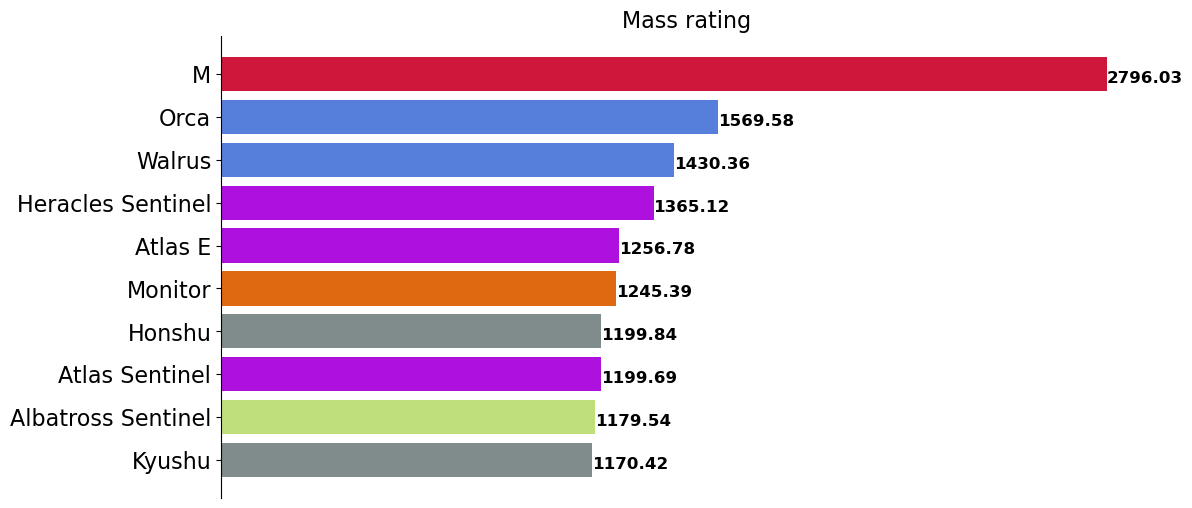

In [104]:
plot_data_1 = all_ships[['name','ship_mass', 'color']].sort_values(by = ['ship_mass'], ascending = False).head(10)

fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot()
ax.barh( plot_data_1['name'][::-1], plot_data_1['ship_mass'][::-1], color = plot_data_1['color'][::-1])
#Оформление
ax.set_title('Mass rating',size=16) 
ax.tick_params(axis='both',labelsize=16)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.axes.get_xaxis().set_visible(False)
#Надписи
rects = ax.patches
for bar in rects:   
        width = bar.get_width()    
        ax.text(width, bar.get_y()+0.2, str(round(width, 2)),fontsize='12', weight='bold', color='black') 
plt.show()

### Forward drag <a class="anchor" id="id_5b"></a>

In [105]:
plot_data_2 = all_ships[['name','drag_forward','purpose','color']].sort_values(by = ['drag_forward'], ascending = False)
display(plot_data_2.head(10))

,name,drag_forward,purpose,color
248,M,639.205,fight,#cf173b
160,Stork Sentinel,369.055,auxiliary,#bfde7c
182,Orca,344.677,auxiliary,#567edb
181,Shark,332.118,fight,#567edb
159,Stork Vanguard,324.213,auxiliary,#bfde7c
158,Condor Sentinel,310.771,fight,#bfde7c
154,Atlas E,310.646,auxiliary,#ae10de
153,Atlas Sentinel,299.941,auxiliary,#ae10de
145,Nomad Sentinel,293.991,auxiliary,#2333c2
140,Mammoth Sentinel,292.574,build,#2333c2


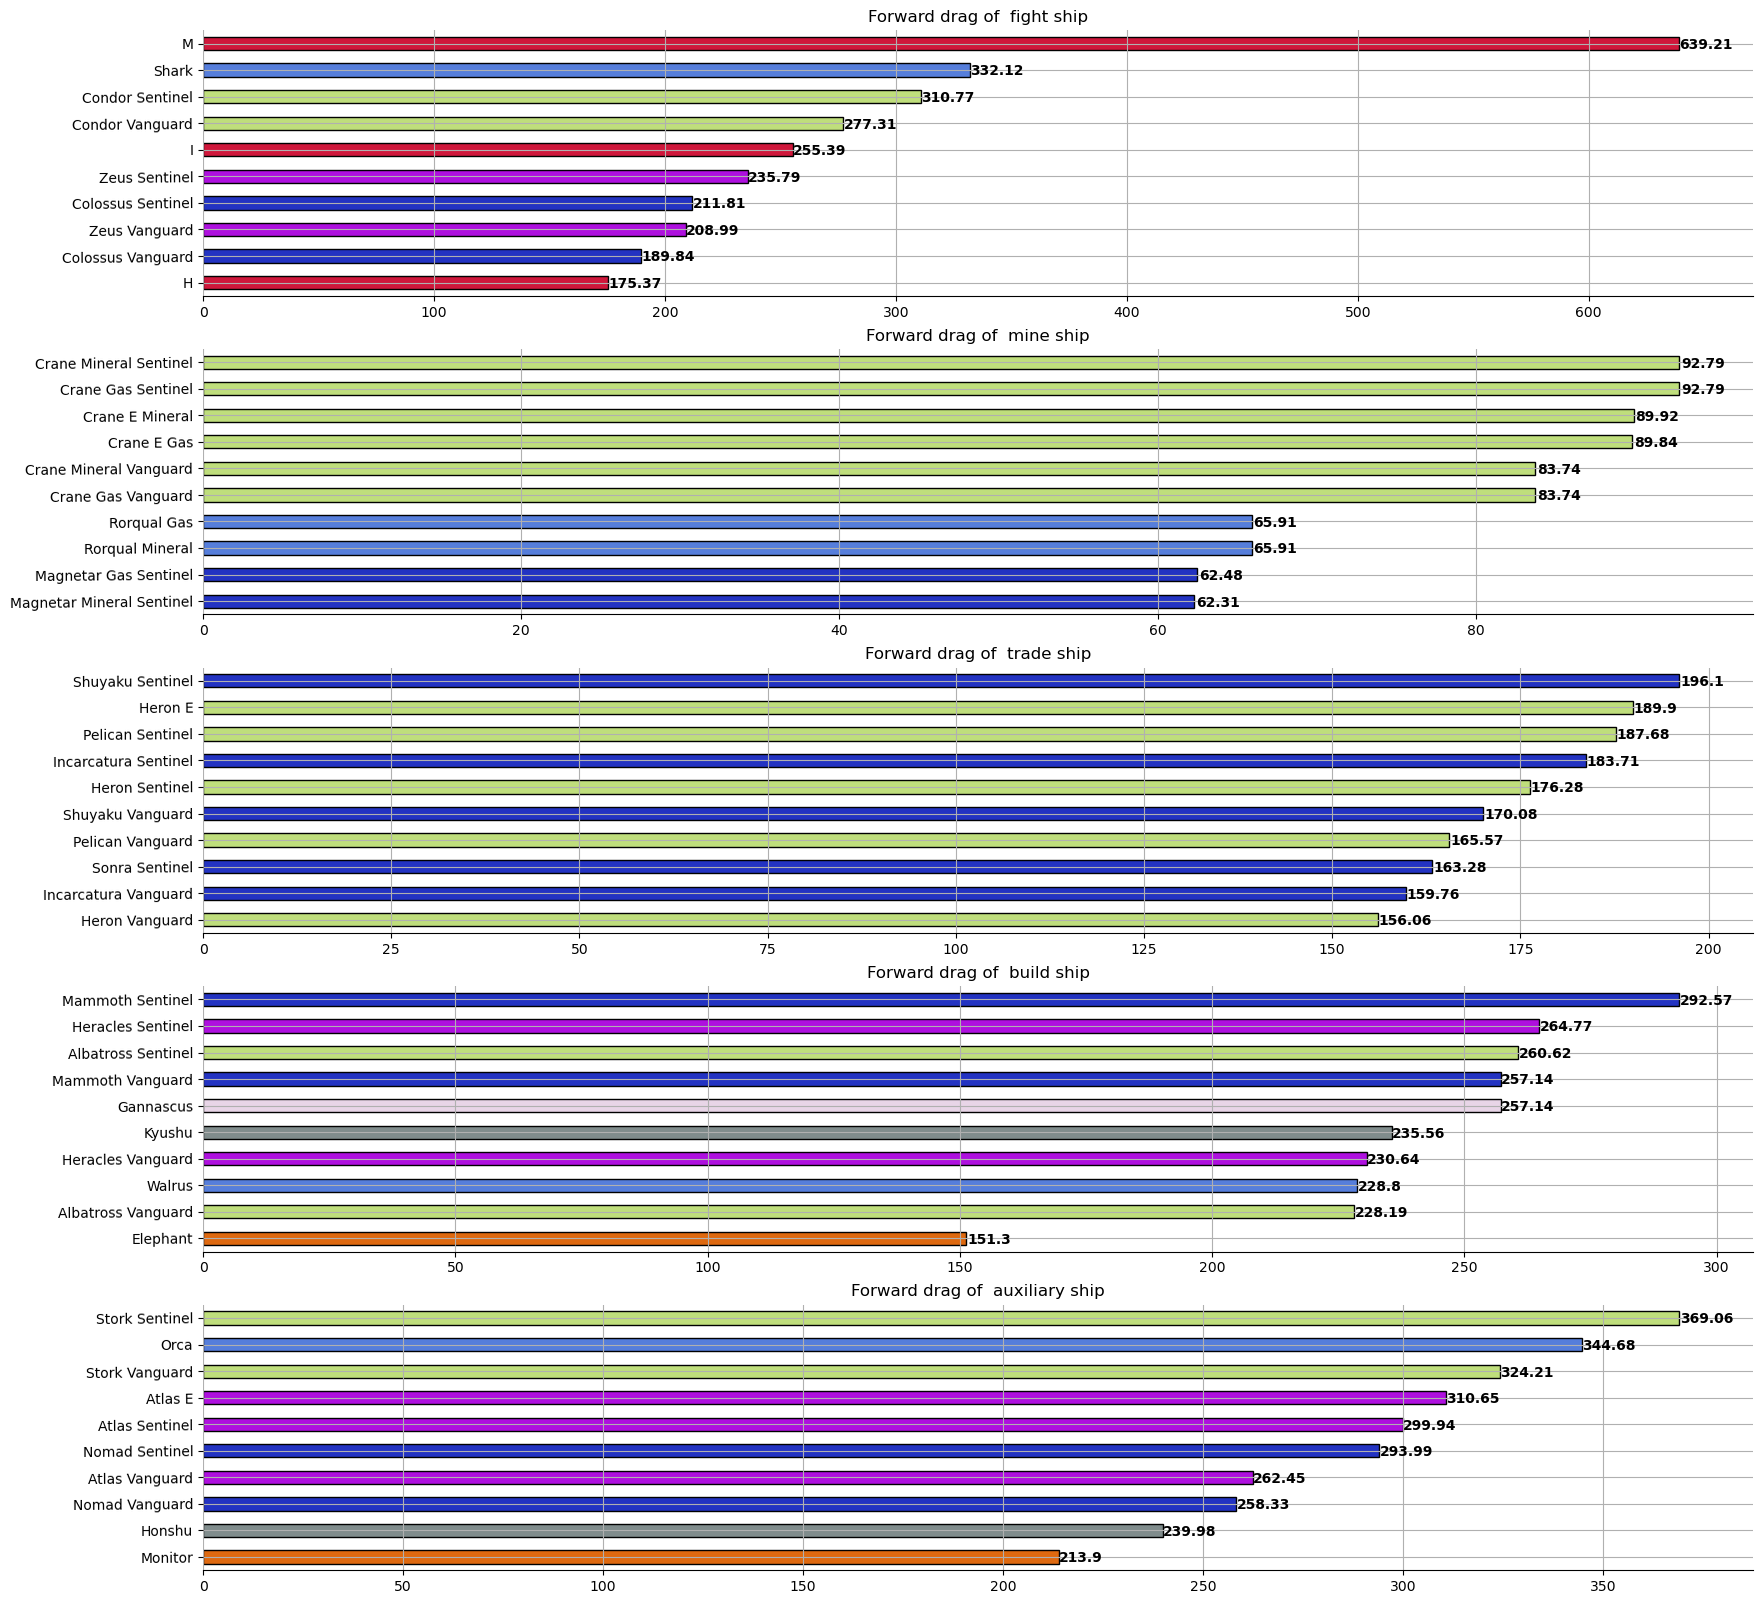

In [106]:
cols = 1 # the number of columns for subplots
rows = 5 # the number of rows for subplots
count = 0 # counter variable
purposes = ['fight', 'mine', 'trade', 'build', 'auxiliary'] # the purposes of ships to include in the plot
fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(20,20))
for r in range(rows): 
            # temporary dataframe to construct the plot
            temp_df =   plot_data_2[plot_data_2['purpose']==purposes[count]].pivot_table(
                index = ['name'],
                values = ['drag_forward','color','purpose'],
                aggfunc = 'first').sort_values(by = ['drag_forward'],ascending = True).tail(10)                      
            axes[r] = temp_df['drag_forward'].plot(  kind='barh',
                                                      ax = axes[r], 
                                                      edgecolor='black', color = temp_df['color'],
                                                       grid=True,
                                                      title = f'Forward drag of  {purposes[count]} ship', xlabel = '', ylabel = '',
                                                      legend=False, rot = 0.45)
            #remove the boundaries of subplots
            axes[r].spines['top'].set_visible(False)
            axes[r].spines['right'].set_visible(False)
            axes[r].spines['left'].set_visible(False)  
            #Show the values of bars            
            rects = axes[r].patches          
            for index in range(len(rects)):
                width = rects[index].get_width()
                t = axes[r].text(width+0.1, rects[index].get_y()+0.2, str(round(width, 2)),
                          fontsize='medium', weight='bold', color='black',va='center',ha='left')
            count+=1
plt.subplots_adjust(hspace=0.2,wspace=0.2)
plt.show()

### Rating by hull size <a class="anchor" id="id_5c"></a>

In [107]:
plot_data_3 = all_ships[['name','hull','purpose','ship_type','color']]
display(plot_data_3.head(2))
print(all_ships['purpose'].unique())

,name,hull,purpose,ship_type,color
0,Behemoth Vanguard,93000,fight,destroyer,#2333c2
1,Behemoth Sentinel,111000,fight,destroyer,#2333c2


['fight' 'mine' 'trade' 'build' 'auxiliary' 'dismantling' 'salvage']


As dismantling и salvage groups consist only from one ship I exclude them from the plot:

In [108]:
purposes = plot_data_3['purpose'].unique() 
exlude_purposes = ['dismantling', 'salvage']
purposes = [x for x in purposes if x not in exlude_purposes]
print(purposes)

['fight', 'mine', 'trade', 'build', 'auxiliary']


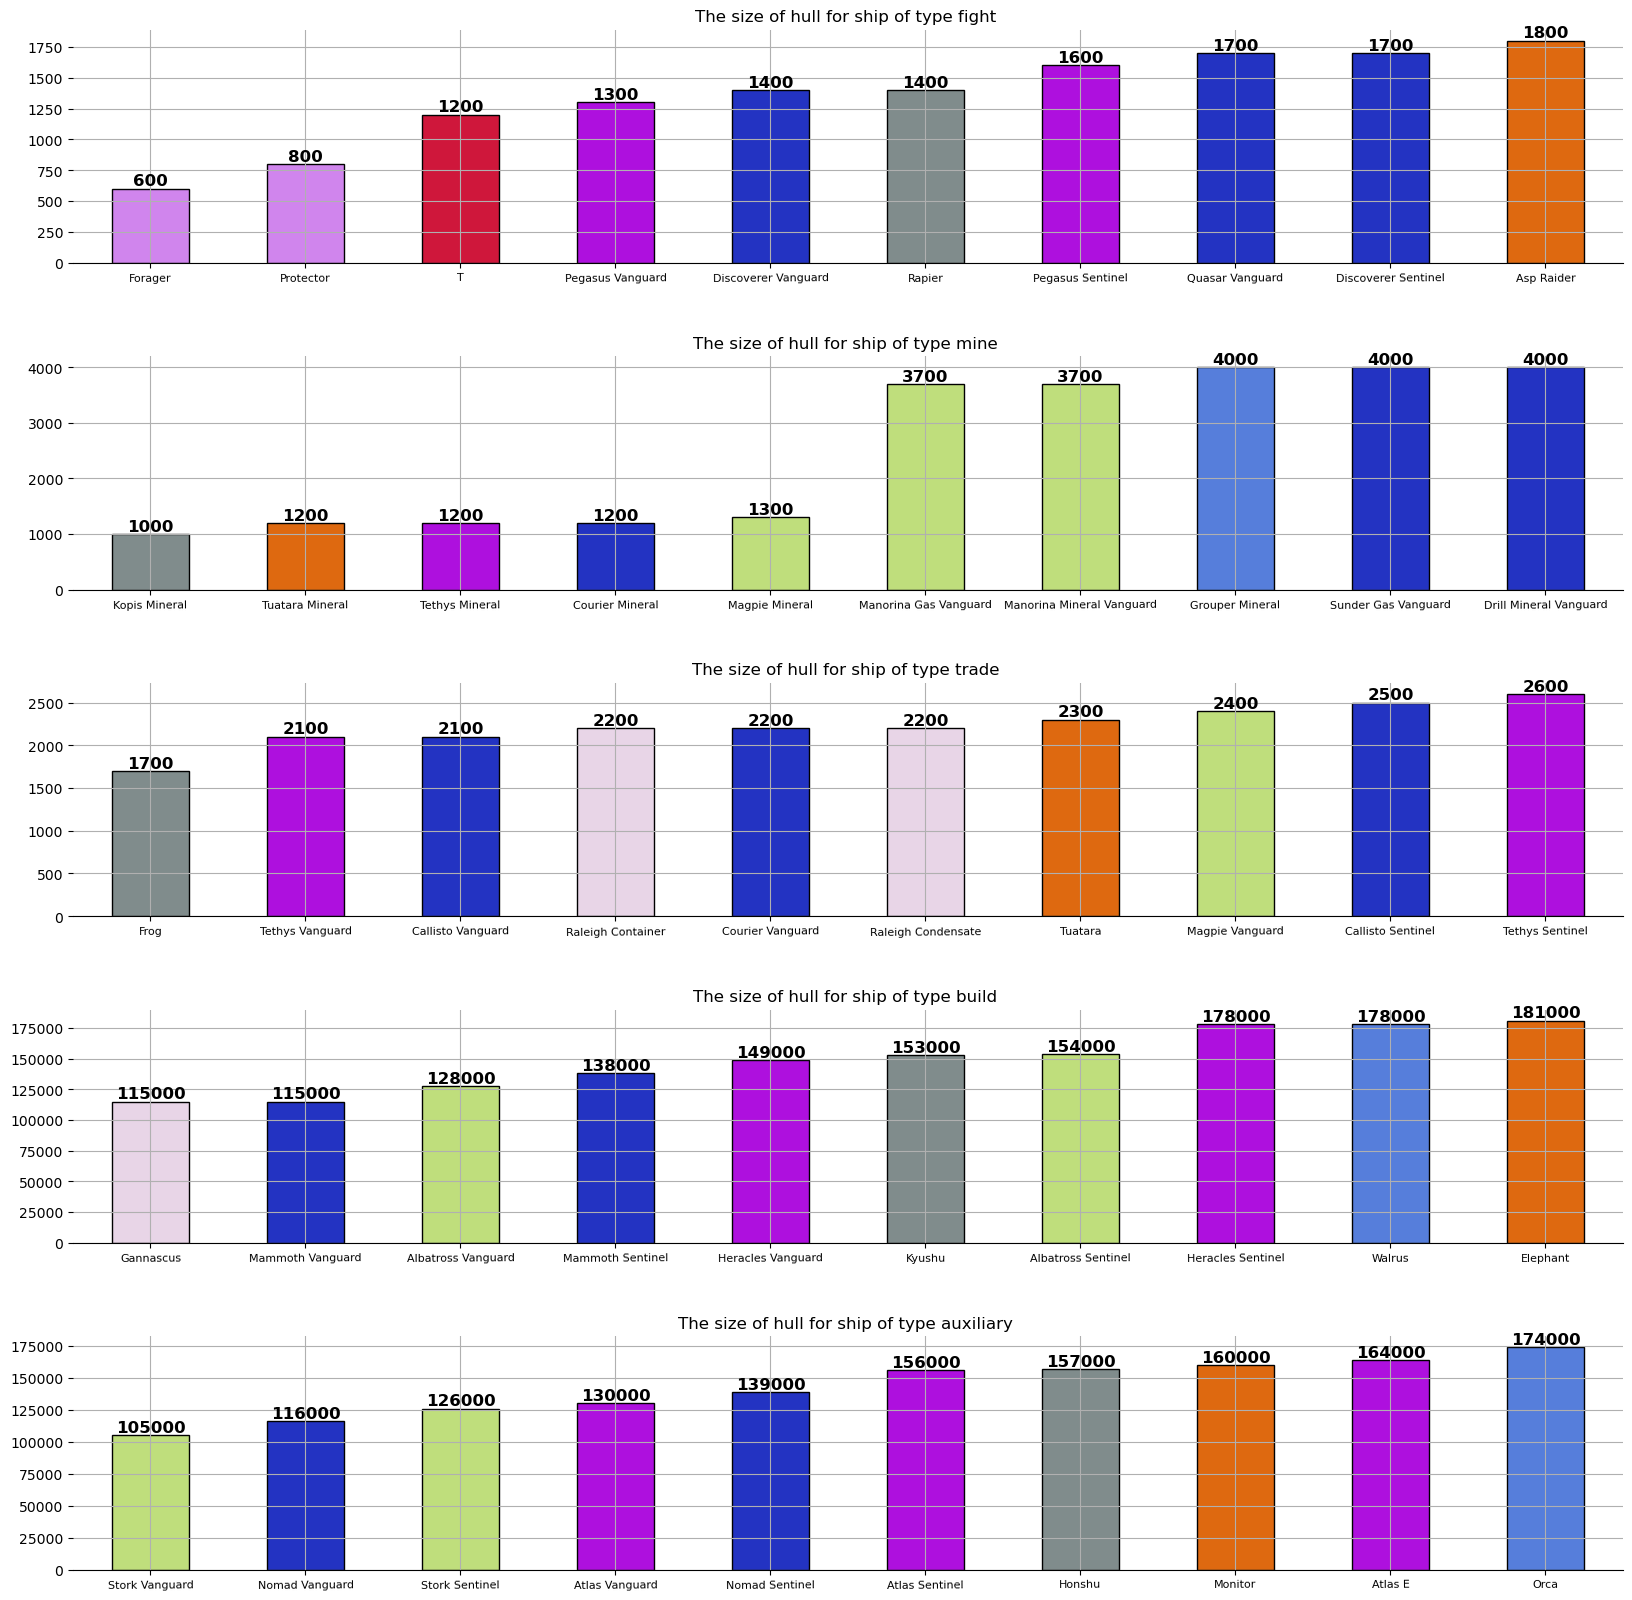

In [109]:
cols = 1 # the number of columns for subplots
rows = len(purposes) # the number of rows for subplots
count = 0 # counter

fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(20,20))
for r in range(rows):                
            temp_df = plot_data_3[plot_data_3['purpose']==purposes[count]].pivot_table(
                  index = ['name'],
                  values = ['hull','purpose','color'],
                  aggfunc ='first' ).sort_values(by = ['hull']).head(10)
            axes[r] = temp_df['hull'].plot(
                kind='bar', ax = axes[r], edgecolor='black',  color = temp_df['color'], grid=True,
                title = f'The size of hull for ship of type {purposes[count]} ', xlabel = '', legend=False, rot = 0.45)
            axes[r].tick_params(axis='x',labelsize=8)
            
            # Remove the boundaries of subplots
            axes[r].spines['top'].set_visible(False)
            axes[r].spines['right'].set_visible(False)
            axes[r].spines['left'].set_visible(False)  
            
            # Show values
            rects = axes[r].patches
            for rect in rects:
                    height = rect.get_height()    
                    axes[r].text(rect.get_x() + rect.get_width() / 2, height + 2, round(height,1),
                          ha="center", va="bottom",weight='bold',size='large',c='black')            
            count+=1
plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.show()

#### The value of hull for L-class ships

In [110]:
purposes = plot_data_3['purpose'].unique() # список назначений корабля

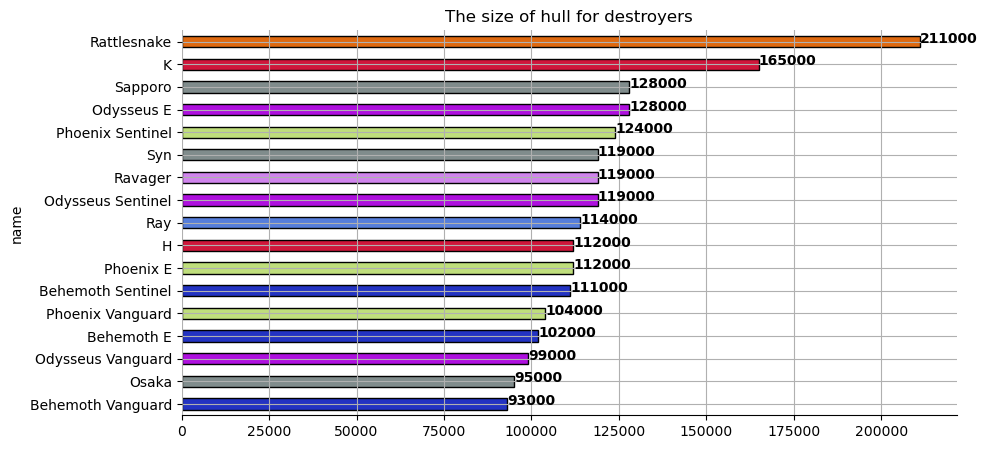

In [111]:
cols = 1 # the number of columns for subplots
count = 0 # counter
rows = 1
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot()
temp_df = plot_data_3[(plot_data_3['purpose']=='fight')
                                  & (plot_data_3['ship_type']=='destroyer')].pivot_table(
                  index = ['name'],
                  values = ['hull','purpose','color'],
                  aggfunc ='first' ).sort_values(by = ['hull'])
ax = temp_df['hull'].plot(
                kind='barh', ax = ax, edgecolor='black',  color =temp_df['color'] , grid=True,
                title = f'The size of hull for destroyers', xlabel = '', legend=False)
            
            #Removing axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)  
#Show values
rects = ax.patches
for bar in rects:   
        width = bar.get_width()    
        ax.text(width, bar.get_y()+0.2, str(round(width, 2)),fontsize='10', weight='bold', color='black') 
plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.show()

#### The size of hull for frigates

In [112]:
display(all_ships['ship_type'].unique())

array(['destroyer', 'gunboat', 'scavenger', 'frigate', 'heavyfighter',
       'corvette', 'fighter', 'scout', 'carrier', 'battleship',
       'largeminer', 'miner', 'freighter', 'transporter', 'courier',
       'builder', 'resupplier', 'compactor', 'tug'], dtype=object)

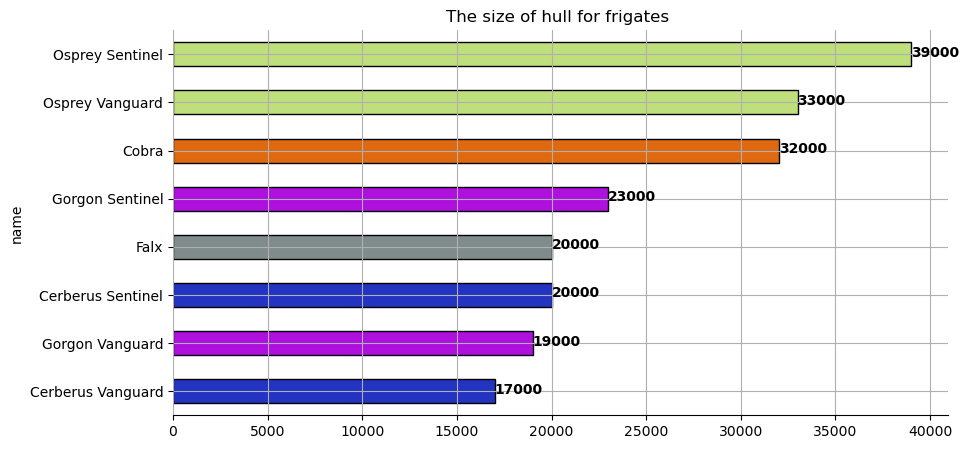

In [113]:
cols = 1 # the number of columns for subplots
count = 0 # counter
rows = 1
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot()
temp_df = plot_data_3[(plot_data_3['purpose']=='fight')
                                  & (plot_data_3['ship_type']=='frigate')].pivot_table(
                  index = ['name'],
                  values = ['hull','purpose','color'],
                  aggfunc ='first' ).sort_values(by = ['hull'])
ax = temp_df['hull'].plot(
                kind='barh', ax = ax, edgecolor='black',  color =temp_df['color'] , grid=True,
                title = f'The size of hull for frigates ', xlabel = '', legend=False)
            
            #Removing axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)  
#Show values
rects = ax.patches
for bar in rects:   
        width = bar.get_width()    
        ax.text(width, bar.get_y()+0.2, str(round(width, 2)),fontsize='10', weight='bold', color='black') 
plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.show()

#### The size of hull for carriers

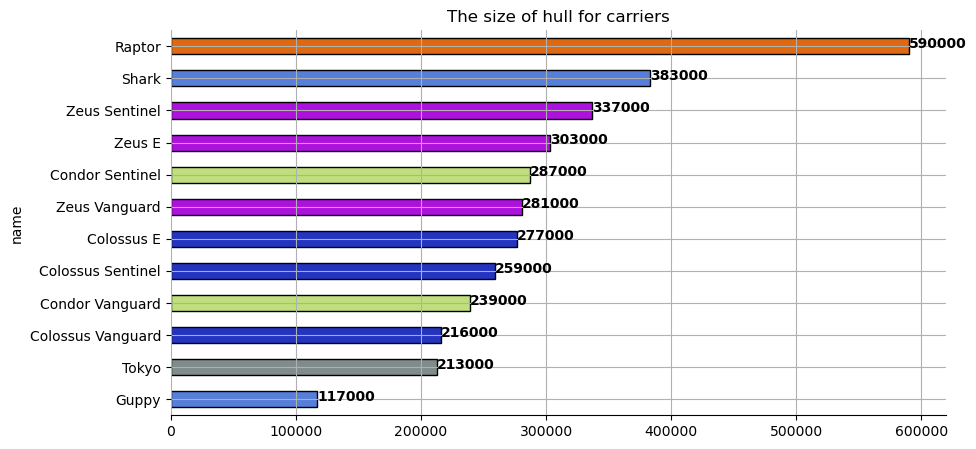

In [114]:
cols = 1 # the number of columns for subplots
count = 0 # counter
rows = 1
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot()
temp_df = plot_data_3[(plot_data_3['purpose']=='fight')
                                  & (plot_data_3['ship_type']=='carrier')].pivot_table(
                  index = ['name'],
                  values = ['hull','purpose','color'],
                  aggfunc ='first' ).sort_values(by = ['hull'])
ax = temp_df['hull'].plot(
                kind='barh', ax = ax, edgecolor='black',  color =temp_df['color'] , grid=True,
                title = f'The size of hull for carriers', xlabel = '', legend=False)
            
            #Removing axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)  
#Show values
rects = ax.patches
for bar in rects:   
        width = bar.get_width()    
        ax.text(width, bar.get_y()+0.2, str(round(width, 2)),fontsize='10', weight='bold', color='black') 
plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.show()

#### The size of hull for heavyfighters S-class

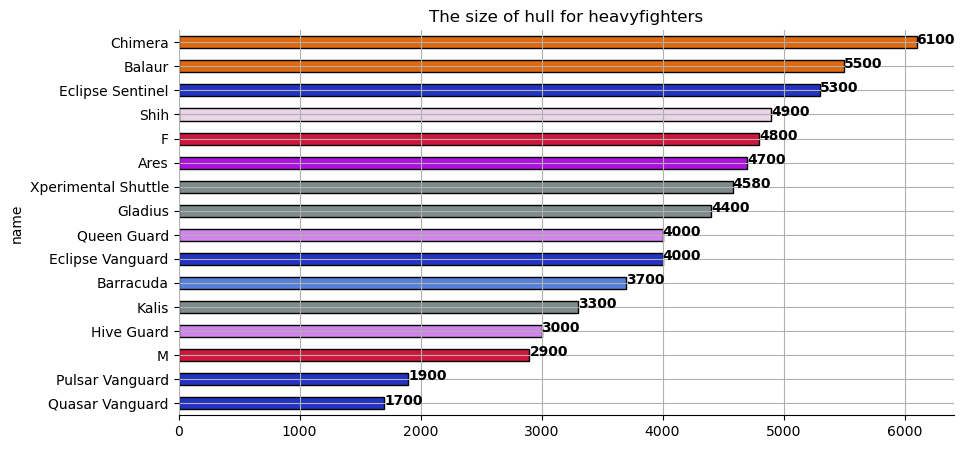

In [115]:
cols = 1 # the number of columns for subplots
count = 0 # counter
rows = 1
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot()
temp_df = plot_data_3[(plot_data_3['purpose']=='fight')
                                  & (plot_data_3['ship_type']=='heavyfighter')].pivot_table(
                  index = ['name'],
                  values = ['hull','purpose','color'],
                  aggfunc ='first' ).sort_values(by = ['hull'])
ax = temp_df['hull'].plot(
                kind='barh', ax = ax, edgecolor='black',  color =temp_df['color'] , grid=True,
                title = f'The size of hull for heavyfighters', xlabel = '', legend=False)
            
            #Removing boundaries
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)  
#Show values
rects = ax.patches
for bar in rects:   
        width = bar.get_width()    
        ax.text(width, bar.get_y()+0.2, str(round(width, 2)),fontsize='10', weight='bold', color='black') 
plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.show()

#### The aggregate defence of ships <a class="anchor" id="id_5d"></a>

##### The aggregate defence for XL carriers

In [116]:
display(shield_data.query('type=="XL"')[['name','maker','shield_value']].sort_values(by=['shield_value'], ascending = False))

,name,maker,shield_value
66,TER XL Shield Generator Mk2,terran,161988
55,BOR XL Shield Generator Mk2,boron,159937
44,Erlking XL Shield Generator,argon,158600
27,TEL XL Shield Generator Mk1,teladi,142429
65,TER XL Shield Generator Mk1,terran,135955
54,BOR XL Shield Generator Mk1,boron,133766
7,ARG XL Shield Generator Mk1,argon,129481
34,XEN XL Shield Generator Mk1,xenon,125000
19,PAR XL Shield Generator Mk1,paranid,116532
42,SPL XL Shield Generator Mk1,split,110058


In [117]:
xl_carriers = (accesible_ships.query('(ship_class=="ship_xl") & (ship_type=="carrier")')
               [['name','race', 'hull','primary_shield_slots', 'aggregate_defence', 'color']].reset_index(drop=True)
)
display(xl_carriers)

,name,race,hull,primary_shield_slots,aggregate_defence,color
0,Colossus Vanguard,argon,216000,3,701964,#2333c2
1,Colossus Sentinel,argon,259000,3,744964,#2333c2
2,Colossus E,argon,277000,3,762964,#2333c2
3,Zeus Vanguard,paranid,281000,2,604976,#ae10de
4,Zeus Sentinel,paranid,337000,2,660976,#ae10de
5,Zeus E,paranid,303000,2,626976,#ae10de
6,Condor Vanguard,teladi,239000,2,562976,#bfde7c
7,Condor Sentinel,teladi,287000,2,610976,#bfde7c
8,Shark,boron,383000,5,1182685,#567edb
9,Tokyo,terran,213000,3,698964,#808c8c


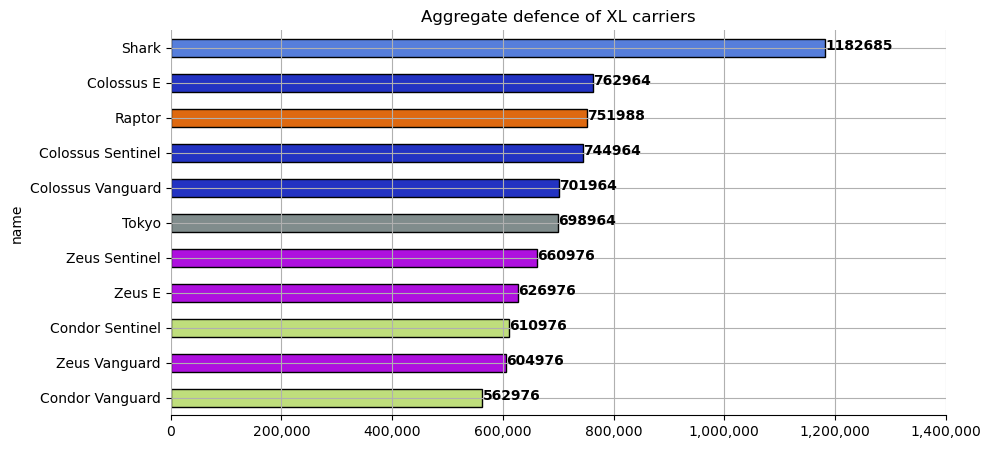

In [118]:
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot()
temp_df = xl_carriers.pivot_table(
                  index = ['name'],
                  values = ['aggregate_defence','color'],
                  aggfunc ='first' ).sort_values(by = ['aggregate_defence'])
ax = temp_df['aggregate_defence'].plot(
                kind='barh', ax = ax, edgecolor='black',  color =temp_df['color'] , grid=True,
                title = f'Aggregate defence of XL carriers', xlabel = '', legend=False)
            
            #Removing boundaries
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)  
#Show values
rects = ax.patches
for bar in rects:   
        width = bar.get_width()    
        ax.text(width, bar.get_y()+0.2, int(round(width, 2)),fontsize='10', weight='bold', color='black') 
#Changeing the format of ticks on X-axis
label_format = '{:,.0f}'
ticks_loc = ax.get_xticks().tolist()
ax.set_xticks(ax.get_xticks().tolist()) # fixing xticks with "set_xticks" FixedLocator error
ax.set_xticklabels([label_format.format(x) for x in ticks_loc])
plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.show()

In [119]:
shark_vs_asgard = (accesible_ships.query('(name=="Shark") | (name=="Asgard")')
               [['name','race', 'hull','primary_shield_slots', 'aggregate_defence','color']].reset_index(drop=True)
)
display(shark_vs_asgard)

,name,race,hull,primary_shield_slots,aggregate_defence,color
0,Shark,boron,383000,5,1182685,#567edb
1,Asgard,terran,275000,4,922952,#808c8c


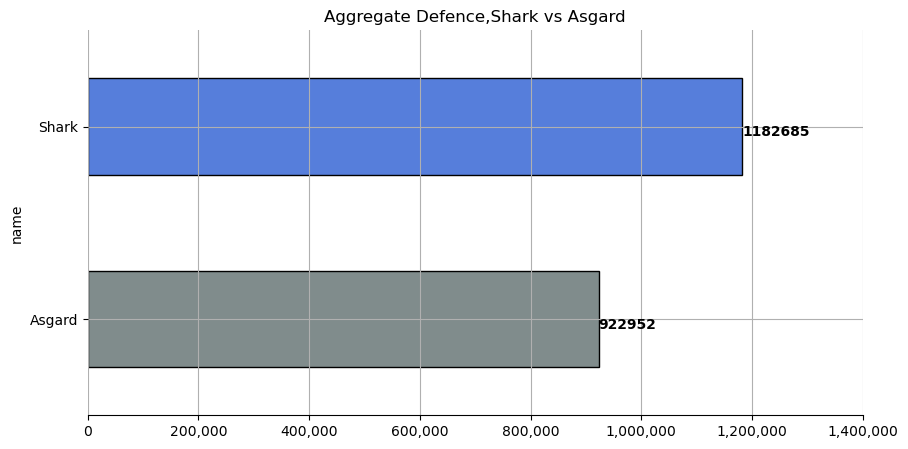

In [120]:
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot()
temp_df = shark_vs_asgard.pivot_table(
                  index = ['name'],
                  values = ['aggregate_defence','color'],
                  aggfunc ='first' ).sort_values(by = ['aggregate_defence'])
ax = temp_df['aggregate_defence'].plot(
                kind='barh', ax = ax, edgecolor='black',  color =temp_df['color'] , grid=True,
                title = f'Aggregate Defence,Shark vs Asgard', xlabel = '', legend=False)
            
            #removing boundaries
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False) 
#show values
rects = ax.patches
for bar in rects:   
        width = bar.get_width()    
        ax.text(width, bar.get_y()+0.2, int(round(width, 2)),fontsize='10', weight='bold', color='black') 
plt.subplots_adjust(hspace=0.4, wspace=0.3)
#changing the format of ticks on X-axis
label_format = '{:,.0f}'
ticks_loc = ax.get_xticks().tolist()
ax.set_xticks(ax.get_xticks().tolist()) # fixing xticks with "set_xticks" FixedLocator error
ax.set_xticklabels([label_format.format(x) for x in ticks_loc])
plt.show()

##### The aggregate defence of L destroyers

In [121]:
display(shield_data.query('type=="L"')[['name','maker','shield_value']].sort_values(by=['shield_value'], ascending = False).head())

,name,maker,shield_value
70,TER L Frontier Shield Generator Mk3,terran,69424
58,TER L Shield Generator Mk3,terran,69424
47,BOR L Shield Generator Mk3,boron,68399
21,TEL L Shield Generator Mk2,teladi,50911
69,TER L Frontier Shield Generator Mk2,terran,48597


Creating the dataframe for the plot:

In [122]:
destroyers_df = (accesible_ships.query('(ship_class=="ship_l") & (ship_type=="destroyer")')
               [['name','race', 'hull','primary_shield_slots', 'aggregate_defence','max_speed', 'color']].reset_index(drop=True)
)
display(destroyers_df)

,name,race,hull,primary_shield_slots,aggregate_defence,max_speed,color
0,Behemoth Vanguard,argon,93000,3,301272,172,#2333c2
1,Behemoth Sentinel,argon,111000,3,319272,157,#2333c2
2,Behemoth E,argon,102000,3,310272,211,#2333c2
3,Odysseus Vanguard,paranid,99000,2,237848,222,#ae10de
4,Odysseus Sentinel,paranid,119000,2,257848,201,#ae10de
5,Odysseus E,paranid,128000,2,266848,247,#ae10de
6,Phoenix Vanguard,teladi,104000,3,312272,185,#bfde7c
7,Phoenix Sentinel,teladi,124000,3,332272,167,#bfde7c
8,Phoenix E,teladi,112000,3,320272,252,#bfde7c
9,H,xenons,112000,2,192000,144,#cf173b


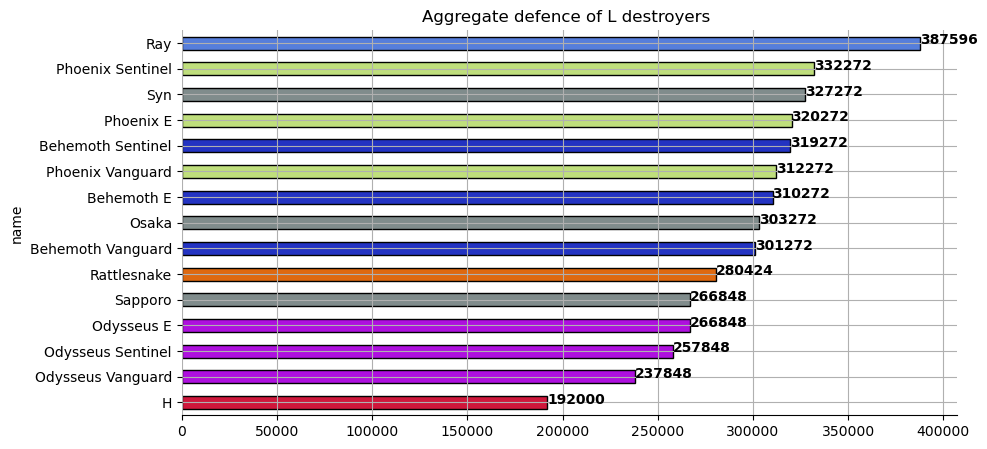

In [123]:
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot()
temp_df = destroyers_df.pivot_table(
                  index = ['name'],
                  values = ['aggregate_defence','color'],
                  aggfunc ='first' ).sort_values(by = ['aggregate_defence'])
ax = temp_df['aggregate_defence'].plot(
                kind='barh', ax = ax, edgecolor='black',  color =temp_df['color'] , grid=True,
                title = f'Aggregate defence of L destroyers ', xlabel = '', legend=False)
            
            #removing boundaries
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)  
#show values
rects = ax.patches
for bar in rects:   
        width = bar.get_width()    
        ax.text(width, bar.get_y()+0.2, int(round(width, 2)),fontsize='10', weight='bold', color='black') 
plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.show()

##### The aggregate defence for M frigates

In [124]:
frigates_df = (accesible_ships.query('(ship_class=="ship_m") & (ship_type=="frigate")')
               [['name','race', 'hull','primary_shield_slots', 'aggregate_defence', 'max_speed', 'color']].reset_index(drop=True)
)
display(frigates_df)

,name,race,hull,primary_shield_slots,aggregate_defence,max_speed,color
0,Cerberus Vanguard,argon,17000,3,44597,440,#2333c2
1,Cerberus Sentinel,argon,20000,3,47597,381,#2333c2
2,Gorgon Vanguard,paranid,19000,3,46597,587,#ae10de
3,Gorgon Sentinel,paranid,23000,3,50597,506,#ae10de
4,Osprey Vanguard,teladi,33000,3,60597,226,#bfde7c
5,Osprey Sentinel,teladi,39000,3,66597,192,#bfde7c
6,Falx,terran,20000,2,38398,481,#808c8c
7,Cobra,split,32000,2,50398,705,#de6910


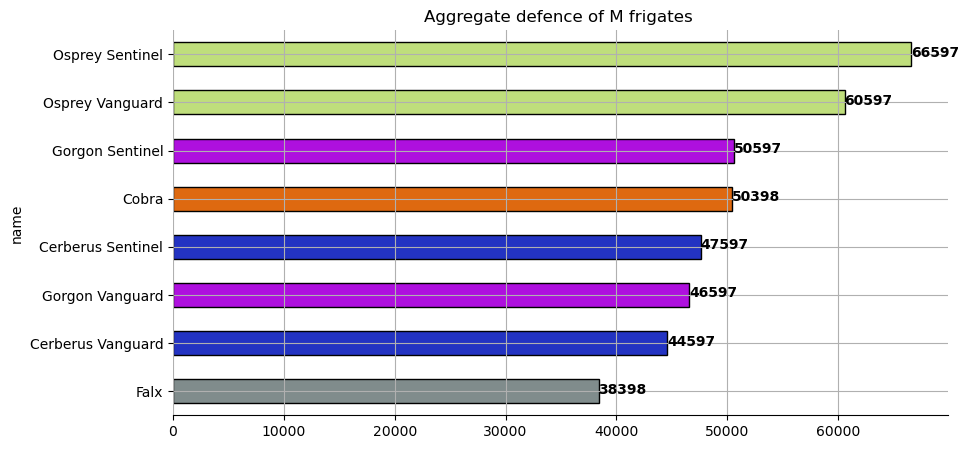

In [125]:
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot()
temp_df = frigates_df.pivot_table(
                  index = ['name'],
                  values = ['aggregate_defence','color'],
                  aggfunc ='first' ).sort_values(by = ['aggregate_defence'])
ax = temp_df['aggregate_defence'].plot(
                kind='barh', ax = ax, edgecolor='black',  color =temp_df['color'] , grid=True,
                title = f'Aggregate defence of M frigates ', xlabel = '', legend=False)
            
            #removing boundaries
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)  
#show values
rects = ax.patches
for bar in rects:   
        width = bar.get_width()    
        ax.text(width, bar.get_y()+0.2, int(round(width, 2)),fontsize='10', weight='bold', color='black') 
plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.show()

##### The aggregate defence for M gunboats

Creating the dataframe for the plot:

In [126]:
gunboats_df = (accesible_ships.query('(ship_class=="ship_m") & (ship_type=="gunboat")')
               [['name','race', 'hull','primary_shield_slots', 'aggregate_defence', 'max_speed','color']].reset_index(drop=True)
)
display(gunboats_df)

,name,race,hull,primary_shield_slots,aggregate_defence,max_speed,color
0,Minotaur Vanguard,argon,12000,2,30398,371,#2333c2
1,Minotaur Sentinel,argon,14000,2,32398,322,#2333c2
2,Peregrine Vanguard,teladi,12000,3,39597,463,#bfde7c
3,Peregrine Sentinel,teladi,14000,3,41597,403,#bfde7c
4,Thresher,boron,10900,2,28654,461,#567edb
5,Jian,terran,13000,2,31398,443,#808c8c


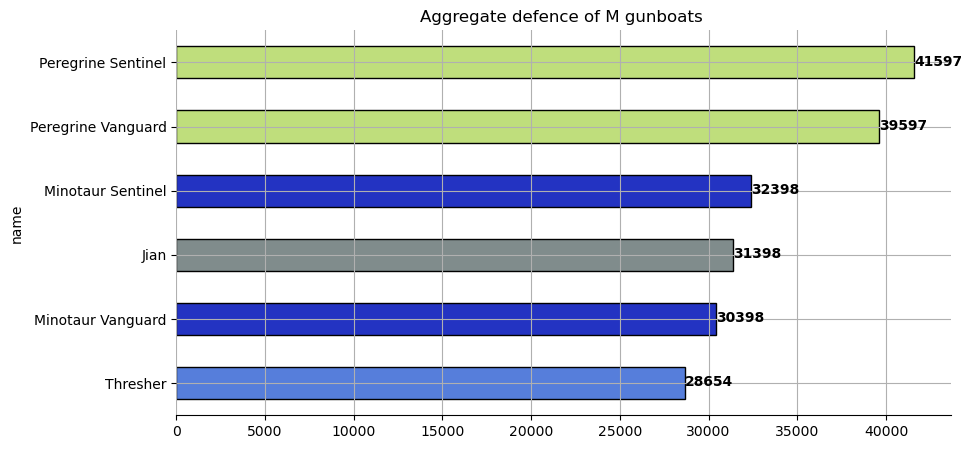

In [127]:
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot()
temp_df = gunboats_df.pivot_table(
                  index = ['name'],
                  values = ['aggregate_defence','color'],
                  aggfunc ='first' ).sort_values(by = ['aggregate_defence'])
ax = temp_df['aggregate_defence'].plot(
                kind='barh', ax = ax, edgecolor='black',  color =temp_df['color'] , grid=True,
                title = f'Aggregate defence of M gunboats ', xlabel = '', legend=False)
            
            #removing boundaries
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)  
#show values
rects = ax.patches
for bar in rects:   
        width = bar.get_width()    
        ax.text(width, bar.get_y()+0.2, str(round(width, 2)),fontsize='10', weight='bold', color='black') 
plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.show()

##### The aggregate defence for heavyfighters

In [128]:
heavyfighters_df = (accesible_ships.query('(ship_class=="ship_s") & (ship_type=="heavyfighter")')
               [['name','race', 'hull','primary_shield_slots', 'aggregate_defence','max_speed', 'color']].reset_index(drop=True)
)
display(heavyfighters_df)

,name,race,hull,primary_shield_slots,aggregate_defence,max_speed,color
0,Pulsar Vanguard,argon,1900,1,9400,415,#2333c2
1,Quasar Vanguard,argon,1700,1,9200,341,#2333c2
2,Eclipse Sentinel,argon,5300,2,20300,288,#2333c2
3,Eclipse Vanguard,argon,4000,2,19000,321,#2333c2
4,Ares,paranid,4700,3,27200,290,#ae10de
5,F,xenons,4800,2,6372,195,#cf173b
6,Barracuda,boron,3700,3,8065,167,#567edb
7,Shih,pirate,4900,3,27400,359,#e8d5e7
8,Kalis,terran,3300,4,33300,331,#808c8c
9,Gladius,terran,4400,2,19400,301,#808c8c


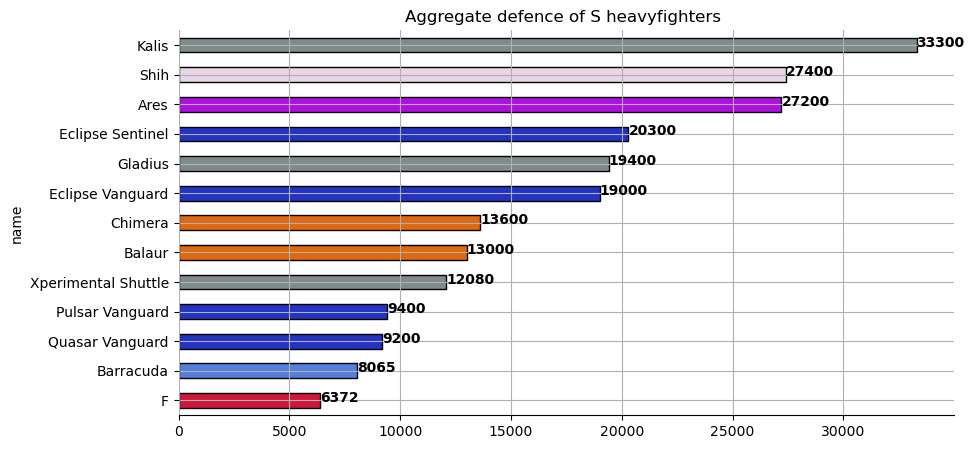

In [129]:
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot()
temp_df = heavyfighters_df.pivot_table(
                  index = ['name'],
                  values = ['aggregate_defence','color'],
                  aggfunc ='first' ).sort_values(by = ['aggregate_defence'])
ax = temp_df['aggregate_defence'].plot(
                kind='barh', ax = ax, edgecolor='black',  color =temp_df['color'] , grid=True,
                title = f'Aggregate defence of S heavyfighters ', xlabel = '', legend=False)
            
            #removing boundaries
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)  
#show values
rects = ax.patches
for bar in rects:   
        width = bar.get_width()    
        ax.text(width, bar.get_y()+0.2, str(round(width, 2)),fontsize='10', weight='bold', color='black') 
plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.show()

##### The aggregate defence for S fighters

In [130]:
fighters_df = (accesible_ships.query('(ship_class=="ship_s") & (ship_type=="fighter")')
               [['name','race', 'hull','primary_shield_slots', 'aggregate_defence','max_speed', 'color']].reset_index(drop=True)
)
display(fighters_df.head())

,name,race,hull,primary_shield_slots,aggregate_defence,max_speed,color
0,Nova Vanguard,argon,3100,1,10600,416,#2333c2
1,Nova Sentinel,argon,3800,1,11300,397,#2333c2
2,Elite Vanguard,argon,1800,1,9300,363,#2333c2
3,Elite Sentinel,argon,2200,1,9700,335,#2333c2
4,Perseus Vanguard,paranid,3700,1,11200,599,#ae10de


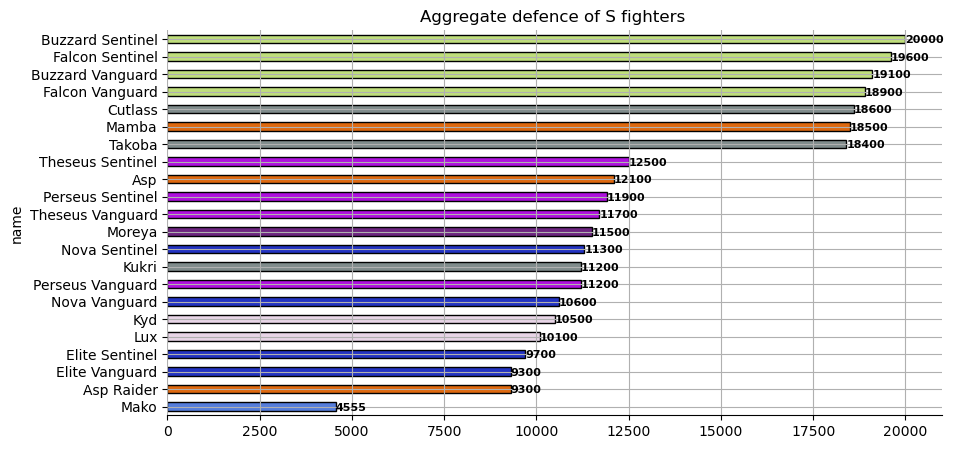

In [131]:
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot()
temp_df = fighters_df.pivot_table(
                  index = ['name'],
                  values = ['aggregate_defence','color'],
                  aggfunc ='first' ).sort_values(by = ['aggregate_defence'])
ax = temp_df['aggregate_defence'].plot(
                kind='barh', ax = ax, edgecolor='black',  color =temp_df['color'] , grid=True,
                title = f'Aggregate defence of S fighters ', xlabel = '', legend=False)
            
            #removing boundaries
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)  
#show values
rects = ax.patches
for bar in rects:   
        width = bar.get_width()    
        ax.text(width, bar.get_y(), str(round(width, 2)),fontsize='8', weight='bold', color='black') 
plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.show()

##### Compaund plot

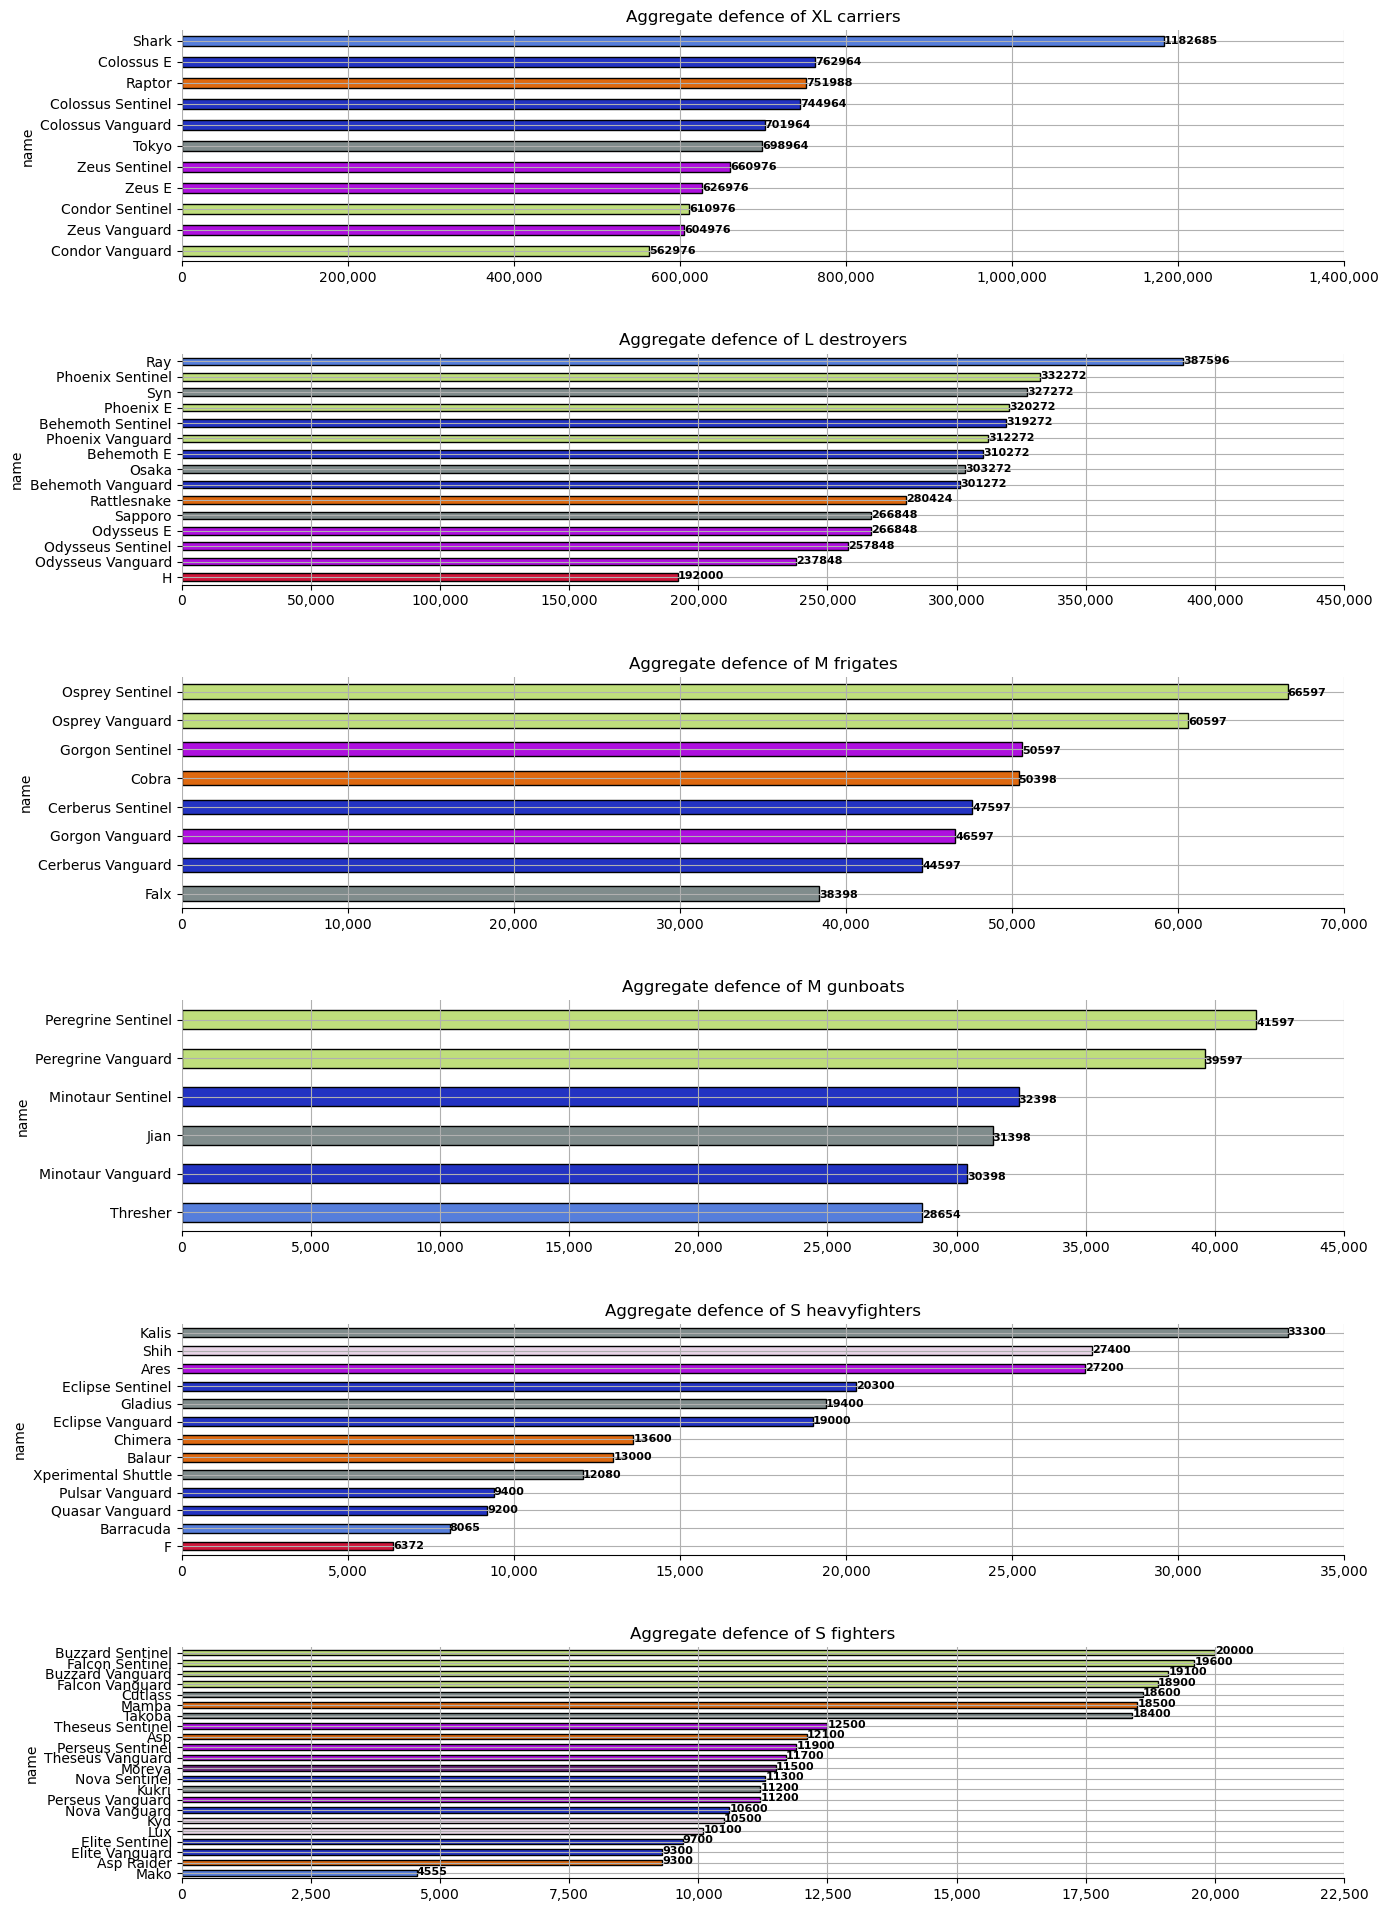

In [132]:
dfs = [xl_carriers,destroyers_df,frigates_df,gunboats_df,heavyfighters_df,fighters_df]
titles = ['Aggregate defence of XL carriers', 'Aggregate defence of L destroyers', 'Aggregate defence of M frigates',
          'Aggregate defence of M gunboats', 'Aggregate defence of S heavyfighters', 'Aggregate defence of S fighters']
nrows = len(dfs)
ncols = 1
count = 0
for df in dfs:
    temp_df = df.pivot_table(
                  index = ['name'],
                  values = ['aggregate_defence','color'],
                  aggfunc ='first' ).sort_values(by = ['aggregate_defence'])
    ax = temp_df['aggregate_defence'].plot(
                kind='barh', ax = plt.subplot(nrows,ncols,count+1), figsize=(15,24), edgecolor='black',  color =temp_df['color'] , grid=True,
                title = titles[count], xlabel = '', legend=False)
     #removing the boundaries of subplots
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)  
    #show values
    rects = ax.patches
    for bar in rects:   
        width = bar.get_width()    
        ax.text(width, bar.get_y()+0.1, int(round(width, 2)),fontsize='8', weight='bold', color='black')
    #changing the format of ticks on X-axis
    label_format = '{:,.0f}'
    ticks_loc = ax.get_xticks().tolist()
    ax.set_xticks(ax.get_xticks().tolist()) # fixing xticks with "set_xticks" FixedLocator error
    ax.set_xticklabels([label_format.format(x) for x in ticks_loc])
    count +=1
plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.show()
 

#### The max speed of ships  <a class="anchor" id="id_5e"></a>

##### Max speed of L destroyers

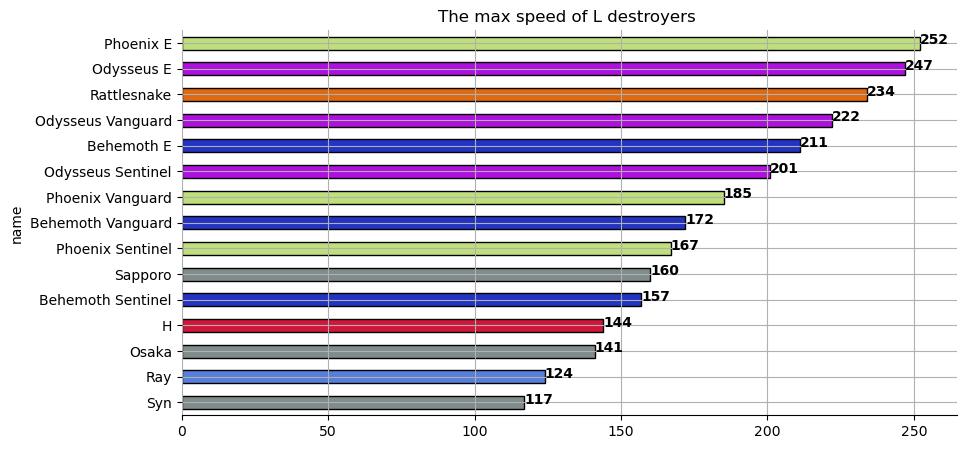

In [133]:
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot()
temp_df = destroyers_df.pivot_table(
                  index = ['name'],
                  values = ['max_speed','color'],
                  aggfunc ='first' ).sort_values(by = ['max_speed'])
ax = temp_df['max_speed'].plot(
                kind='barh', ax = ax, edgecolor='black',  color =temp_df['color'] , grid=True,
                title = f'The max speed of L destroyers ', xlabel = '', legend=False)
            
            #removing boundaries
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)  
#show values
rects = ax.patches
for bar in rects:   
        width = bar.get_width()    
        ax.text(width, bar.get_y()+0.2, int(round(width, 2)),fontsize='10', weight='bold', color='black') 
plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.show()

##### The max speed for М frigates

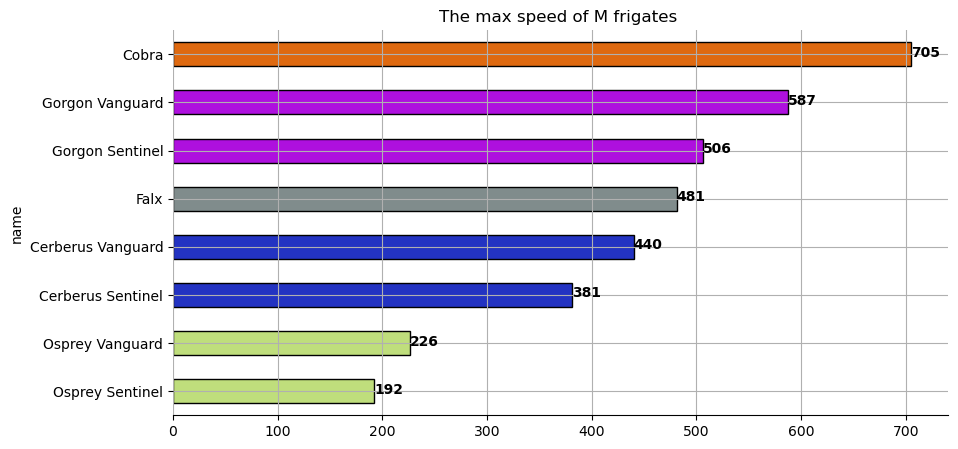

In [134]:
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot()
temp_df = frigates_df.pivot_table(
                  index = ['name'],
                  values = ['max_speed','color'],
                  aggfunc ='first' ).sort_values(by = ['max_speed'])
ax = temp_df['max_speed'].plot(
                kind='barh', ax = ax, edgecolor='black',  color =temp_df['color'] , grid=True,
                title = f'The max speed of М frigates ', xlabel = '', legend=False)
            
            #removing boundaries
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)  
#show values
rects = ax.patches
for bar in rects:   
        width = bar.get_width()    
        ax.text(width, bar.get_y()+0.2, int(round(width, 2)),fontsize='10', weight='bold', color='black') 
plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.show()

##### The max speed of M gunboats

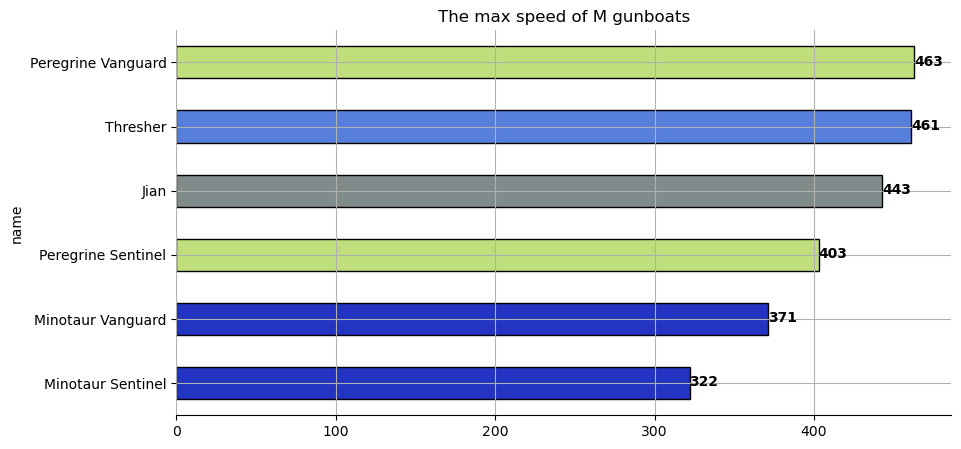

In [135]:
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot()
temp_df = gunboats_df.pivot_table(
                  index = ['name'],
                  values = ['max_speed','color'],
                  aggfunc ='first' ).sort_values(by = ['max_speed'])
ax = temp_df['max_speed'].plot(
                kind='barh', ax = ax, edgecolor='black',  color =temp_df['color'] , grid=True,
                title = f'The max speed of M gunboats', xlabel = '', legend=False)
            
            #removing boundaries
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)  
#show values
rects = ax.patches
for bar in rects:   
        width = bar.get_width()    
        ax.text(width, bar.get_y()+0.2, int(round(width, 2)),fontsize='10', weight='bold', color='black') 
plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.show()

##### The max speed of S heavyfighters

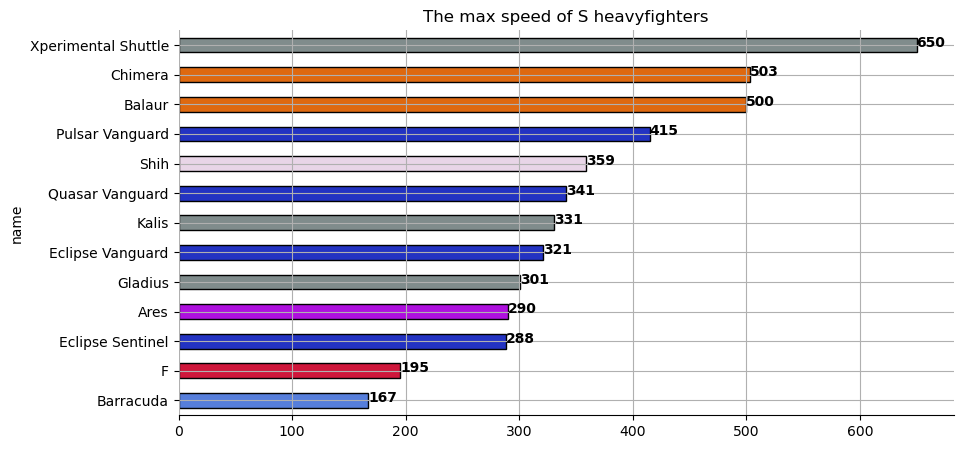

In [136]:
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot()
temp_df = heavyfighters_df.pivot_table(
                  index = ['name'],
                  values = ['max_speed','color'],
                  aggfunc ='first' ).sort_values(by = ['max_speed'])
ax = temp_df['max_speed'].plot(
                kind='barh', ax = ax, edgecolor='black',  color =temp_df['color'] , grid=True,
                title = f'The max speed of S heavyfighters', xlabel = '', legend=False)
            
            #removing boundaries
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)  
#show values
rects = ax.patches
for bar in rects:   
        width = bar.get_width()    
        ax.text(width, bar.get_y()+0.2, int(round(width, 2)),fontsize='10', weight='bold', color='black') 
plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.show()

##### The max speed of S fighters

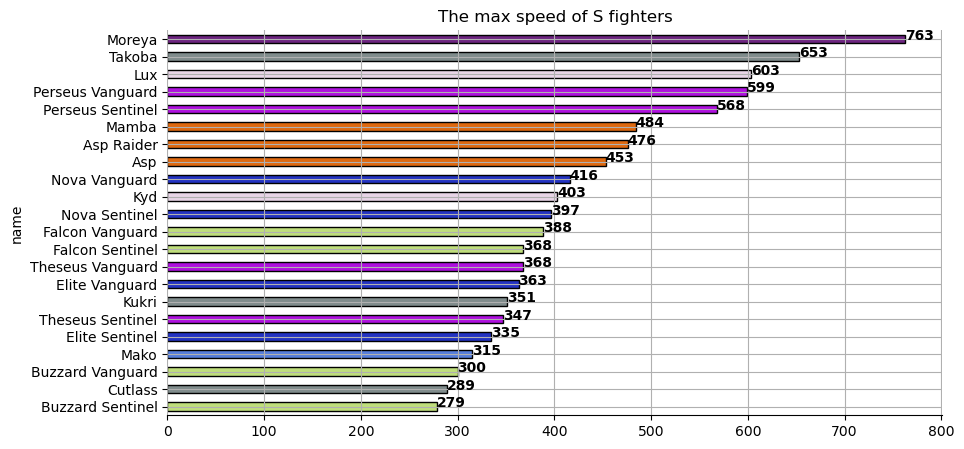

In [137]:
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot()
temp_df = fighters_df.pivot_table(
                  index = ['name'],
                  values = ['max_speed','color'],
                  aggfunc ='first' ).sort_values(by = ['max_speed'])
ax = temp_df['max_speed'].plot(
                kind='barh', ax = ax, edgecolor='black',  color =temp_df['color'] , grid=True,
                title = f'The max speed of S fighters', xlabel = '', legend=False)
            
            #removing boundaries
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)  
#show values
rects = ax.patches
for bar in rects:   
        width = bar.get_width()    
        ax.text(width, bar.get_y()+0.2, int(round(width, 2)),fontsize='10', weight='bold', color='black') 
plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.show()

----